# let's compare to rE2G extended and see if there are examples I score better

In [1]:
#first let's load it
import pandas as pd

path = "/data1/lesliec/sarthak/data/joint_playground/e2g/ENCODE-rE2G_extended_CrossValidated_K562_EPCrisprBenchmark_ensemble_data_GRCh38.predictions.tsv.gz"
df = pd.read_csv(path, sep='\t')
df

,chr,start,end,name,class,TargetGene,TargetGeneEnsemblID,TargetGeneTSS,CellType,FullModel.Score,FullModel_minus_EP300.Score,DistanceToTSS
0,chr1,3774714,3775214,chr1:3774714-3775214,NaN,CEP104,NaN,3857213,K562,0.096023,0.119478,81923.0
1,chr1,3774714,3775214,chr1:3774714-3775214,NaN,LRRC47,NaN,3796503,K562,0.400644,0.418431,21194.0
2,chr1,3774714,3775214,chr1:3774714-3775214,NaN,SMIM1,NaN,3772761,K562,0.991864,0.990204,2524.0
3,chr1,3803570,3805848,chr1:3803570-3805848,NaN,LRRC47,NaN,3796503,K562,0.246991,0.231678,7776.0
4,chr1,3803570,3805848,chr1:3803570-3805848,NaN,SMIM1,NaN,3772788,K562,0.094680,0.076260,31494.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10406,chrX,155434755,155435408,chrX:155434755-155435408,NaN,DKC1,NaN,154762742,K562,0.000567,0.000665,672080.0
10407,chrX,155434755,155435408,chrX:155434755-155435408,NaN,FAM3A,NaN,154516241,K562,0.001304,0.001512,918579.0
10408,chrX,155434755,155435408,chrX:155434755-155435408,NaN,LAGE3,NaN,154479256,K562,0.002902,0.003605,955564.0
10409,chrX,155434755,155435408,chrX:155434755-155435408,NaN,UBL4A,NaN,154486669,K562,0.006867,0.008849,948151.0


In [2]:
#let's load my gold standard df
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)

name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10276,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10277,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10278,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [29]:
gs_df.columns

Index(['dataset', 'chrom', 'chromStart', 'chromEnd', 'name', 'EffectSize',
       'chrTSS', 'startTSS', 'endTSS', 'measuredGeneSymbol', 'Significant',
       'pValueAdjusted', 'PowerAtEffectSize25', 'ValidConnection', 'CellType',
       'Reference', 'Regulated', 'PowerAtEffectSize10', 'PowerAtEffectSize15',
       'PowerAtEffectSize20', 'PowerAtEffectSize50', 'pair_uid', 'merged_uid',
       'merged_start', 'merged_end', 'ensg_id', 'master'],
      dtype='object')

In [3]:
#so we can subset it by creating a master column of chrom, chromstart, chromend, and measuredGeneSymbol, and then we can merge on that
df['master'] = df['chr'] + ":" + df['start'].astype(str) + "-" + df['end'].astype(str) + "_" + df['TargetGene']
gs_df['master'] = gs_df['chrom'] + ":" + gs_df['chromStart'].astype(str) + "-" + gs_df['chromEnd'].astype(str) + "_" + gs_df['measuredGeneSymbol']
#now subset df to gs_df values
# subset_df = df[df['master'].isin(gs_df['master'])].reset_index(drop=True)
subset_df = gs_df[['master']].merge(df, on='master', how='inner')
subset_df

,master,chr,start,end,name,class,TargetGene,TargetGeneEnsemblID,TargetGeneTSS,CellType,FullModel.Score,FullModel_minus_EP300.Score,DistanceToTSS
0,chr1:3774714-3775214_CEP104,chr1,3774714,3775214,chr1:3774714-3775214,NaN,CEP104,NaN,3857213,K562,0.096023,0.119478,81923.0
1,chr1:3774714-3775214_LRRC47,chr1,3774714,3775214,chr1:3774714-3775214,NaN,LRRC47,NaN,3796503,K562,0.400644,0.418431,21194.0
2,chr1:3803570-3805848_LRRC47,chr1,3803570,3805848,chr1:3803570-3805848,NaN,LRRC47,NaN,3796503,K562,0.246991,0.231678,7776.0
3,chr1:3774714-3775214_SMIM1,chr1,3774714,3775214,chr1:3774714-3775214,NaN,SMIM1,NaN,3772761,K562,0.991864,0.990204,2524.0
4,chr1:3803570-3805848_SMIM1,chr1,3803570,3805848,chr1:3803570-3805848,NaN,SMIM1,NaN,3772788,K562,0.094680,0.076260,31494.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,chrX:155434755-155435408_LAGE3,chrX,155434755,155435408,chrX:155434755-155435408,NaN,LAGE3,NaN,154479256,K562,0.002902,0.003605,955564.0
10276,chrX:154527069-154527569_UBL4A,chrX,154527069,154527569,chrX:154527069-154527569,NaN,UBL4A,NaN,154486669,K562,0.050941,0.118676,40761.5
10277,chrX:155434755-155435408_UBL4A,chrX,155434755,155435408,chrX:155434755-155435408,NaN,UBL4A,NaN,154486669,K562,0.006867,0.008849,948151.0
10278,chrX:155434755-155435408_DKC1,chrX,155434755,155435408,chrX:155434755-155435408,NaN,DKC1,NaN,154762742,K562,0.000567,0.000665,672080.0


In [4]:
#now let's get my score vector
import numpy as np
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_cage_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_cage_tss_centered_in_context.npy')
print(outputs.shape, in_context.shape)

(10280, 4, 6144) (10280,)


In [ ]:
from tqdm import tqdm
def make_score_vector(outputs, in_context, mask_len_maintss=100, mask_len_alttss=100, pseudo_count=1e-2,
                      assay_type='CAGE', model_type='enformer', gtf=None, gene_to_idxs=None):
    # outputs.shape[1] == 4  → model has 2 output channels (before+, before-, after+, after-)
    # outputs.shape[1] == 8  → model has 4 output channels / 'both' (CAGE+,CAGE-,RNA+,RNA- × before/after)

    score_vector = np.zeros(len(gs_df))
    if model_type == 'enformer':
        size = 896
        assert outputs.shape[2] == size, f"Expected outputs to have size {size} in last dimension, got {outputs.shape[2]}"
        bin_size = 128
    elif model_type == 'borzoi':
        size = 6144
        assert outputs.shape[2] == size, f"Expected outputs to have size {size} in last dimension, got {outputs.shape[2]}"
        bin_size = 32

    n_channels = outputs.shape[1]  # 4 or 8

    for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']

        gene_location = size // 2
        tempout = outputs[i]  # (n_channels, size)

        # --- Determine og_idx / alt_idx ---
        if model_type == 'enformer':
            og_idx = 0
            alt_idx = 1
        elif n_channels == 8:
            # 4-channel 'both' model: CAGE+/CAGE-/RNA+/RNA- × before/after
            # before: 0,1,2,3  |  after: 4,5,6,7
            if assay_type == 'RNA':
                og_idx  = 2 if strand == '+' else 3
                alt_idx = 6 if strand == '+' else 7
            else:  # CAGE
                og_idx  = 0 if strand == '+' else 1
                alt_idx = 4 if strand == '+' else 5
        else:
            # 2-channel model: before+/before-/after+/after-  (n_channels == 4)
            og_idx  = 0 if strand == '+' else 1
            alt_idx = 2 if strand == '+' else 3

        # --- Build mask ---
        if assay_type == 'RNA':
            # Sum over exon bins rather than TSS window
            if gtf is None or gene_to_idxs is None:
                raise ValueError("gtf and gene_to_idxs are required for assay_type='RNA'")

            gene_rows = gtf.iloc[gene_to_idxs[ensgid]]
            exons = gene_rows[gene_rows['feature'] == 'exon']

            mask = np.zeros(size)
            for _, exon in exons.iterrows():
                # GTF coords are 1-based closed; convert to bin indices relative to TSS center
                exon_start_bin = ((exon['start'] - 1 - temp_tss) // bin_size) + gene_location
                exon_end_bin   = ((exon['end']  - temp_tss) // bin_size) + gene_location
                exon_start_bin = max(0, exon_start_bin)
                exon_end_bin   = min(size, exon_end_bin)
                if exon_start_bin < exon_end_bin:
                    mask[exon_start_bin:exon_end_bin] = 1
        else:
            # CAGE: mask around main TSS and alt TSSs
            mask = np.zeros(size)
            startmask = max(0, gene_location - mask_len_maintss)
            endmask   = min(size, gene_location + mask_len_maintss + 1)
            mask[startmask:endmask] = 1

            alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
            if mask_len_alttss > 0:
                for alt in alt_tss:
                    alt_location = int(size // 2 + alt // bin_size)
                    if alt_location < 0 or alt_location >= size:
                        continue
                    alt_startmask = max(0, alt_location - mask_len_alttss)
                    alt_endmask   = min(size, alt_location + mask_len_alttss + 1)
                    mask[alt_startmask:alt_endmask] = 1

        original_sum = (tempout[og_idx] * mask).sum()
        altered_sum  = (tempout[alt_idx] * mask).sum()

        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

    return score_vector

#now let's get a score vector

mask_len_maintss = 5
mask_len_alttss = 3
pseudo_count = 1e-2

score_vector = make_score_vector(outputs, in_context, mask_len_maintss, mask_len_alttss, pseudo_count, assay_type='CAGE', model_type='borzoi')

100%|██████████| 10280/10280 [00:00<00:00, 21403.30it/s]


In [12]:
distance_vector = np.zeros(len(gs_df))
for i, row in gs_df.iterrows():
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    distance_vector[i] = abs(temp_tss - ((start+end)//2))
distance_vector

array([ 82269.,  21540.,   8205., ..., 948411., 672340., 446198.])

In [ ]:
#let's ensure distance_vector is same as from the subset df column
subset_df['DistanceToTSS'] -distance_vector #way they define distance is slightly off?

0       -346.0
1       -346.0
2       -429.0
3        346.0
4       -429.0
         ...  
10275   -260.0
10276    112.5
10277   -260.0
10278   -260.0
10279    260.0
Name: DistanceToTSS, Length: 10280, dtype: float64

(array([4.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 1.000e+00, 3.000e+00, 1.400e+01, 1.400e+01, 3.000e+00,
        5.094e+03, 5.090e+03, 8.000e+00, 1.800e+01, 1.400e+01, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 9.000e+00]),
 array([-235508.5 , -226088.16, -216667.82, -207247.48, -197827.14,
        -188406.8 , -178986.46, -169566.12, -160145.78, -150725.44,
        -141305.1 , -131884.76, -122464.42, -113044.08, -103623.74,
         -94203.4 ,  -84783.06,  -75362.72,  -65942.38,  -56522.04,
         -47101.7 ,  -37681.36,  -28261.02,  -18840.68,   -9420.34,
              0.  ,    9420.34,   18

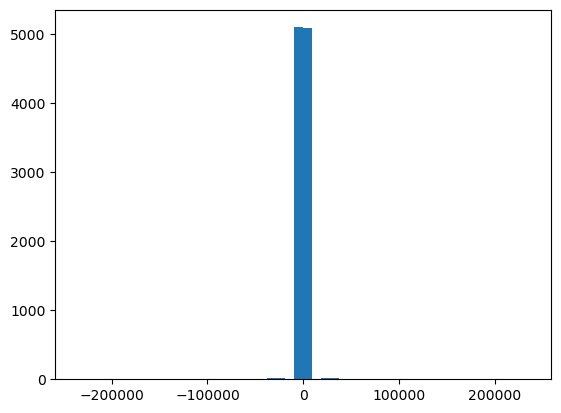

In [ ]:
off_dist = subset_df['DistanceToTSS'] - distance_vector
import matplotlib.pyplot as plt
plt.hist(off_dist, bins=50) #some are very very off...

In [6]:
#let's just use the E2G distances
distance_vector = subset_df['DistanceToTSS'].values


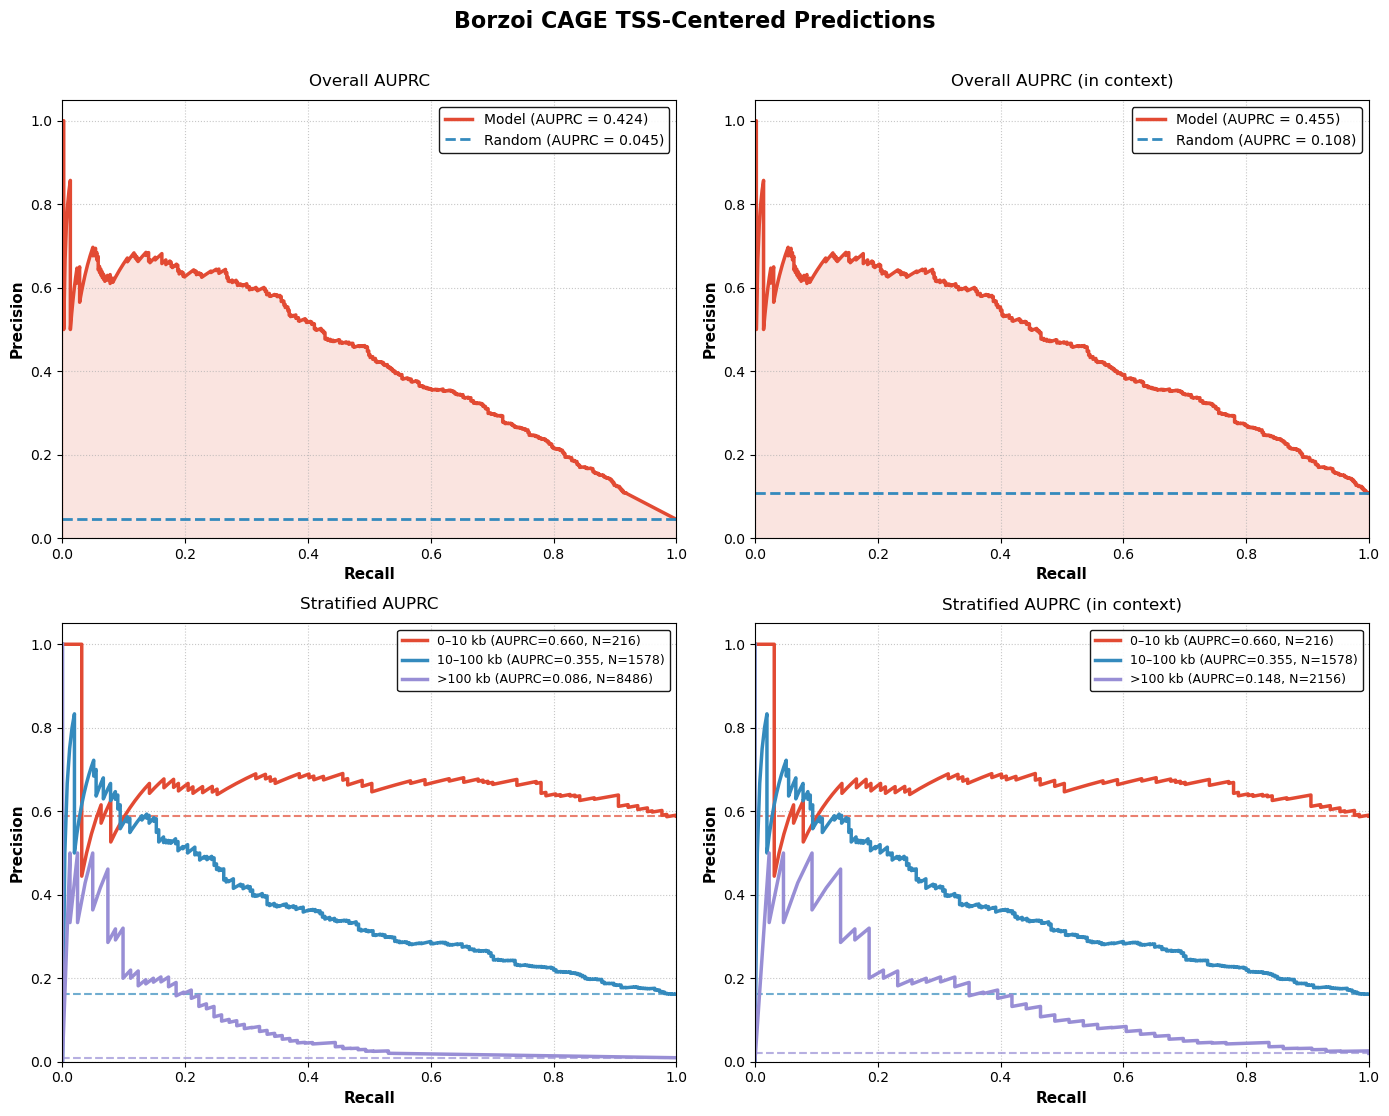

In [8]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title=None):
    """
    2x2 subplot summary of AUPRC performance.
    
    Parameters
    ----------
    score_vector  : np.ndarray (N,)  – pre-computed scores (e.g. log2 fold-change)
    in_context    : np.ndarray (N,)  – boolean mask of enhancers within the input crop
    gs_df         : pd.DataFrame     – must contain 'Regulated' column
    distance_vector : np.ndarray (N,) – enhancer-to-TSS distances (absolute values)
    title         : str, optional    – overall figure suptitle
    """
    y_score_all = np.abs(score_vector)
    y_true_all  = gs_df['Regulated'].astype(int).values
    dist_all    = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx  = y_true_all[in_context]
    dist_ctx    = dist_all[in_context]

    distance_bins = [
        ("0–10 kb",    lambda d: d <= 10_000),
        ("10–100 kb",  lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",    lambda d: d > 100_000),
    ]
    bin_colors = ['#E24A33', '#348ABD', '#988ED5']

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    # ── helper: single overall PR curve ──────────────────────────────────────
    def _plot_overall(ax, y_true, y_score, subtitle):
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        aupr     = auc(rec, prec)
        baseline = y_true.mean()

        ax.plot(rec, prec, color='#E24A33', lw=2.5,
                label=f'Model (AUPRC = {aupr:.3f})')
        ax.fill_between(rec, prec, alpha=0.15, color='#E24A33')
        ax.axhline(baseline, color='#348ABD', lw=2, linestyle='--',
                   label=f'Random (AUPRC = {baseline:.3f})')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')

    # ── helper: distance-stratified PR curves ────────────────────────────────
    def _plot_stratified(ax, y_true, y_score, distances, subtitle):
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances)
            if mask.sum() == 0:
                continue
            yt, ys = y_true[mask], y_score[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr     = auc(rec, prec)
            baseline = yt.mean()
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f'{label} (AUPRC={aupr:.3f}, N={mask.sum()})')
            ax.axhline(baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='black')

    # ── fill the 4 panels ────────────────────────────────────────────────────
    _plot_overall   (axes[0, 0], y_true_all, y_score_all, 'Overall AUPRC')
    _plot_overall   (axes[0, 1], y_true_ctx, y_score_ctx, 'Overall AUPRC (in context)')
    _plot_stratified(axes[1, 0], y_true_all, y_score_all, dist_all, 'Stratified AUPRC')
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx, 'Stratified AUPRC (in context)')

    plt.tight_layout()
    plt.show()
plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title='Borzoi CAGE TSS-Centered Predictions')

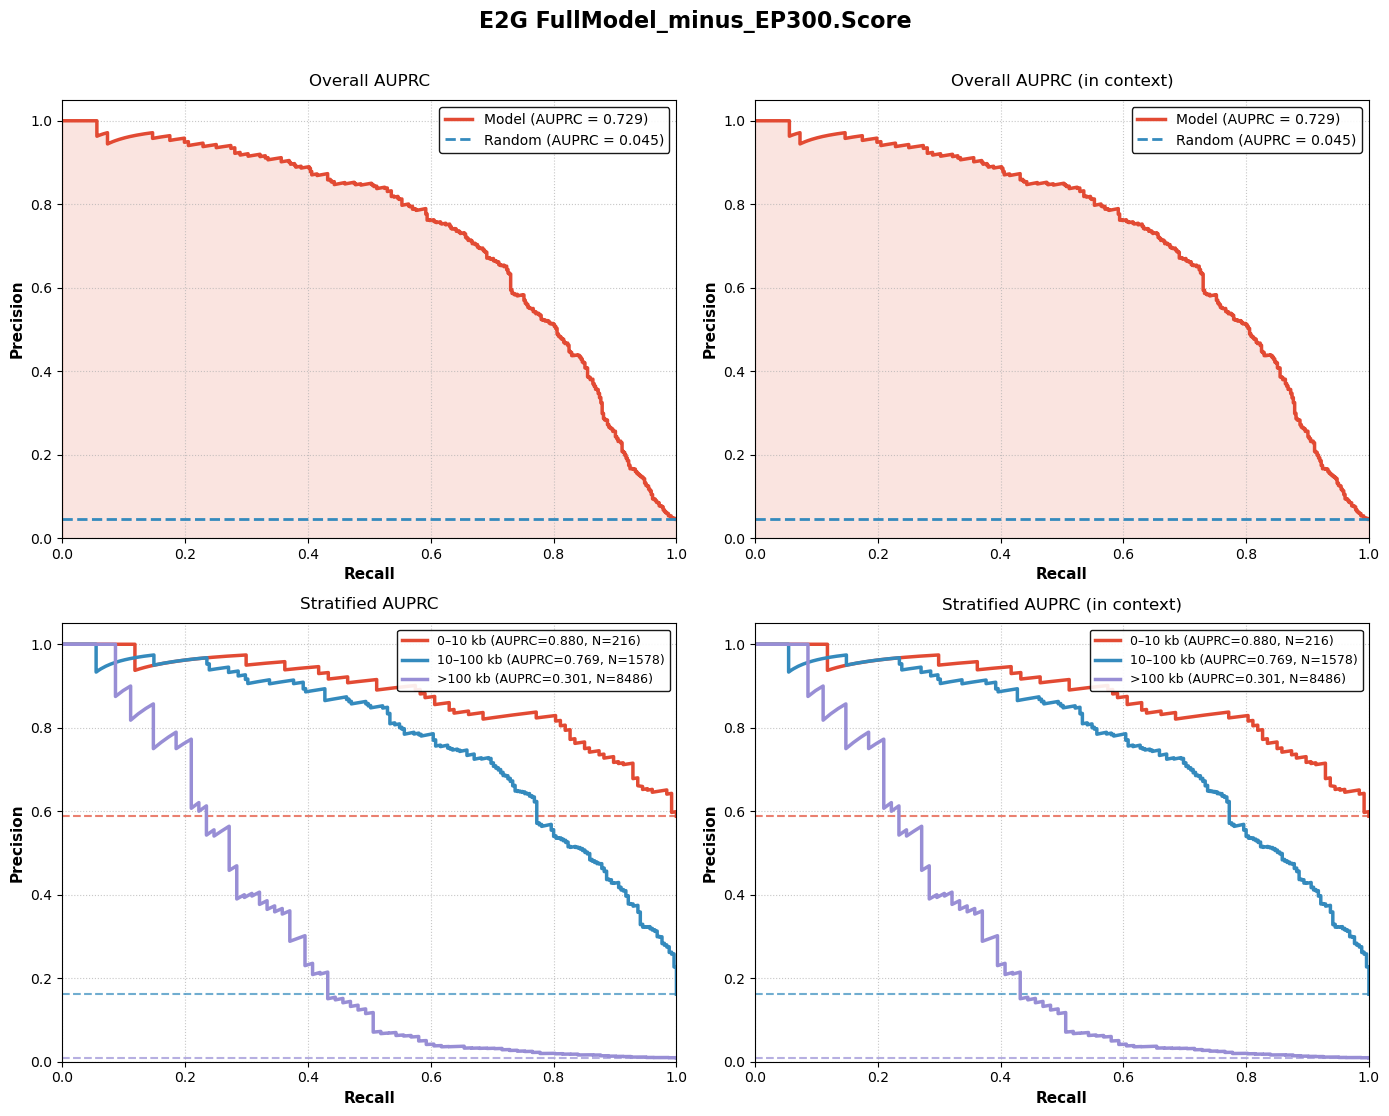

In [9]:
#now let's get the score of E2G
e2g_score_vector = subset_df['FullModel_minus_EP300.Score'].values
e2g_in_context = np.ones_like(e2g_score_vector, dtype=bool) #E2G scores are only for in-context enhancers
plot_auprc_2x2(e2g_score_vector, e2g_in_context, gs_df, distance_vector, title='E2G FullModel_minus_EP300.Score')

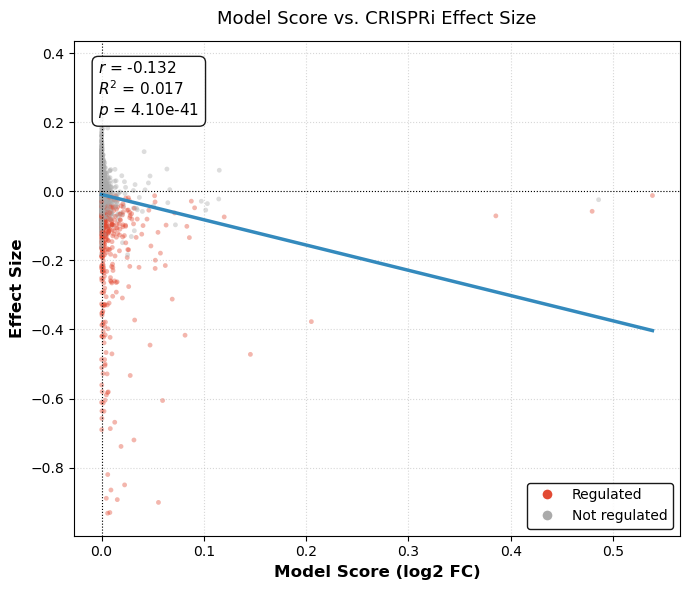

In [28]:
#let's also plot it compared to actual effect size
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Prepare data
df_plot = gs_df.copy()
df_plot['Model_Score'] = np.abs(score_vector)
# df_plot = df_plot[df_plot['Regulated'] == True] # Only consider regulated pairs for the regression

# Fit regression
X = df_plot['Model_Score'].values.reshape(-1, 1)
y = df_plot['EffectSize'].values

#get only ones in cocntext

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

# Pearson r for annotation
r, pval = stats.pearsonr(df_plot['Model_Score'].values, y)
pval_str = f'{pval:.2e}' if pval > 1e-300 else '< 1e-300'

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter: color by Regulated status
colors = df_plot['Regulated'].map({True: '#E24A33', False: '#aaaaaa'})
ax.scatter(df_plot['Model_Score'], y,
           c=colors, alpha=0.4, s=12, linewidths=0, rasterized=True)

# Regression line
x_range = np.linspace(df_plot['Model_Score'].min(), df_plot['Model_Score'].max(), 200)
ax.plot(x_range, reg.predict(x_range.reshape(-1, 1)),
        color='#348ABD', lw=2.5, label=f'Linear fit')

# Reference lines
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.axvline(0, color='black', lw=0.8, linestyle=':')

# Annotation box
textstr = f'$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\n$p$ = {pval_str}'
ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.9))

# Legend for color coding
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24A33', markersize=8, label='Regulated'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaaaaa', markersize=8, label='Not regulated'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_xlabel('Model Score (log2 FC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effect Size', fontsize=12, fontweight='bold')
ax.set_title('Model Score vs. CRISPRi Effect Size', fontsize=13, pad=12)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()



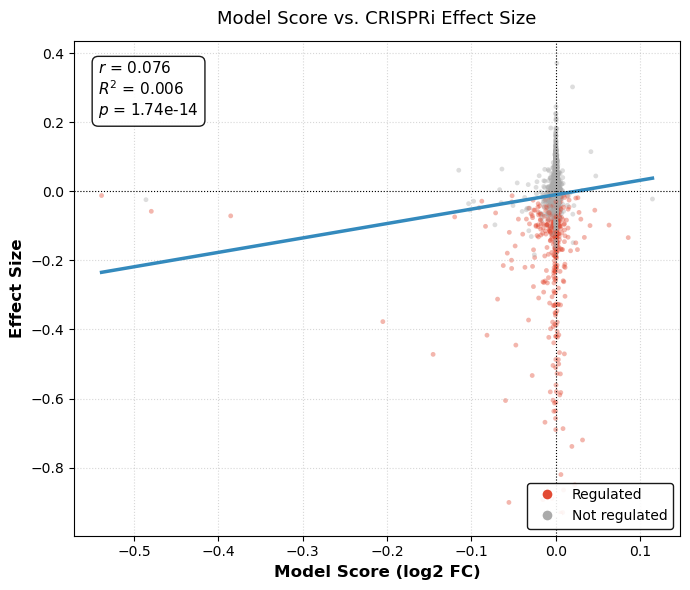

In [73]:
#let's now find it zoomed in

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Prepare data
df_plot = gs_df.copy()
df_plot['Model_Score'] = score_vector
# df_plot = df_plot[df_plot['Regulated'] == True] # Only consider regulated pairs for the regression

# Fit regression
X = df_plot['Model_Score'].values.reshape(-1, 1)
y = df_plot['EffectSize'].values

#get only ones in cocntext

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

# Pearson r for annotation
r, pval = stats.pearsonr(df_plot['Model_Score'].values, y)
pval_str = f'{pval:.2e}' if pval > 1e-300 else '< 1e-300'

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter: color by Regulated status
colors = df_plot['Regulated'].map({True: '#E24A33', False: '#aaaaaa'})
ax.scatter(df_plot['Model_Score'], y,
           c=colors, alpha=0.4, s=12, linewidths=0, rasterized=True)

# Regression line
x_range = np.linspace(df_plot['Model_Score'].min(), df_plot['Model_Score'].max(), 200)
ax.plot(x_range, reg.predict(x_range.reshape(-1, 1)),
        color='#348ABD', lw=2.5, label=f'Linear fit')

# Reference lines
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.axvline(0, color='black', lw=0.8, linestyle=':')

# Annotation box
textstr = f'$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\n$p$ = {pval_str}'
ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.9))

# Legend for color coding
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24A33', markersize=8, label='Regulated'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaaaaa', markersize=8, label='Not regulated'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_xlabel('Model Score (log2 FC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effect Size', fontsize=12, fontweight='bold')
ax.set_title('Model Score vs. CRISPRi Effect Size', fontsize=13, pad=12)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
#set x max at 0.2
# ax.set_xlim(df_plot['Model_Score'].min(), 0.2)
plt.show()

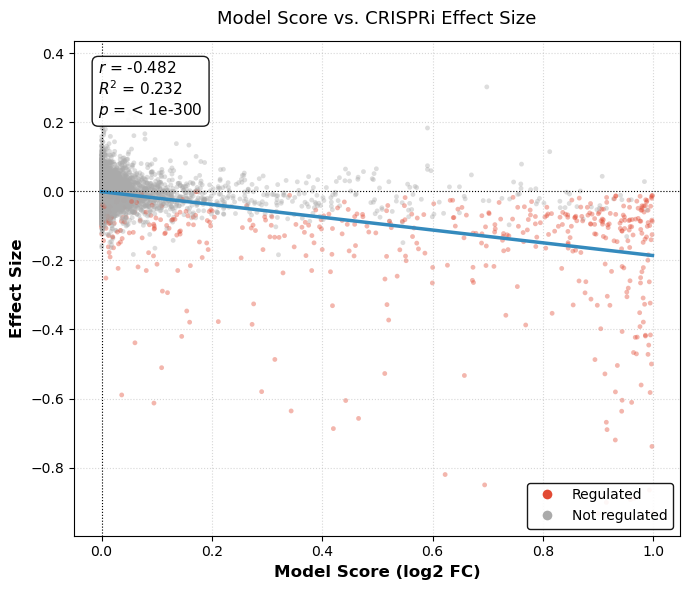

In [26]:
#let's also plot it compared to actual effect size
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Prepare data
df_plot = gs_df.copy()
df_plot['Model_Score'] = e2g_score_vector
# df_plot = df_plot[df_plot['Regulated'] == True] # Only consider regulated pairs for the regression

# Fit regression
X = df_plot['Model_Score'].values.reshape(-1, 1)
y = df_plot['EffectSize'].values

#get only ones in cocntext

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)

# Pearson r for annotation
r, pval = stats.pearsonr(df_plot['Model_Score'].values, y)
pval_str = f'{pval:.2e}' if pval > 1e-300 else '< 1e-300'

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter: color by Regulated status
colors = df_plot['Regulated'].map({True: '#E24A33', False: '#aaaaaa'})
ax.scatter(df_plot['Model_Score'], y,
           c=colors, alpha=0.4, s=12, linewidths=0, rasterized=True)

# Regression line
x_range = np.linspace(df_plot['Model_Score'].min(), df_plot['Model_Score'].max(), 200)
ax.plot(x_range, reg.predict(x_range.reshape(-1, 1)),
        color='#348ABD', lw=2.5, label=f'Linear fit')

# Reference lines
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.axvline(0, color='black', lw=0.8, linestyle=':')

# Annotation box
textstr = f'$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\n$p$ = {pval_str}'
ax.text(0.04, 0.96, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.9))

# Legend for color coding
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24A33', markersize=8, label='Regulated'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaaaaa', markersize=8, label='Not regulated'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor='black')

ax.set_xlabel('Model Score (log2 FC)', fontsize=12, fontweight='bold')
ax.set_ylabel('Effect Size', fontsize=12, fontweight='bold')
ax.set_title('Model Score vs. CRISPRi Effect Size', fontsize=13, pad=12)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()



In [35]:
#now let's see examples where our model is better. Can look at effect sizes
import numpy as np
import pandas as pd

# 1. Combine your arrays into a single DataFrame
# (Assuming your gs_df is aligned and these arrays are the same length)
df = pd.DataFrame({
    'my_score': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, # Helpful for tracking
    'enhancer': gs_df['master'].values,          # Helpful for tracking
    'distance': distance_vector
})

# IMPORTANT: Ensure directions match! 
# This assumes that for both models, a HIGHER score means a STRONGER predicted enhancer.
# If your model outputs predicted log-fold change (where strong enhancers are highly negative),
# you should multiply your scores by -1 before ranking: df['my_score'] = df['my_score'] * -1

# 2. Convert raw scores to rank percentiles (0.0 to 1.0)
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# 3. Calculate your model's "Advantage"
# Positive value means your model ranked it higher than rE2G
# Negative value means rE2G ranked it higher than your model
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
# Filter for pairs that are experimentally proven to be enhancers
true_enhancers = df[df['regulated'] == 1].copy()

# Sort by your advantage. 
# Top rows: Your model loved it, rE2G missed it.
my_best_true_positives = true_enhancers.sort_values('my_advantage_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives[['enhancer', 'gene', 'effect_size', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
# Filter for pairs that have NO significant experimental effect
non_enhancers = df[df['regulated'] == 0].copy()

# Sort by your advantage ascending (most negative values first).
# Top rows: rE2G loved it (high percentile), your model correctly ignored it (low percentile).
my_best_true_negatives = non_enhancers.sort_values('my_advantage_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives[['enhancer', 'gene', 'effect_size', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))

Top 5 True Enhancers my model found but rE2G missed:


,enhancer,gene,effect_size,my_percentile,e2g_percentile,my_advantage_delta,distance
6181,chr2:175036530-175037030_ATP5G3,ATP5G3,-0.099898,0.831420,0.008074,0.823346,145039.0
3837,chr19:3133302-3133802_TIMM13,TIMM13,-0.105291,0.434874,0.053794,0.381080,705571.0
5973,chr2:38613065-38614248_SRSF7,SRSF7,-0.103472,0.869844,0.492121,0.377724,137454.0
2142,chr11:65362343-65362917_FIBP,FIBP,-0.003123,0.434874,0.062257,0.372617,525844.5
4893,chr19:13839483-13839983_DDX39A,DDX39A,-0.124000,0.434874,0.088619,0.346255,579897.0



Top 5 False Positives my model avoided but rE2G fell for:


,enhancer,gene,effect_size,my_percentile,e2g_percentile,my_advantage_delta,distance
8128,chr6:166959196-166959696_RNASET2,RNASET2,-0.054244,0.000973,0.997471,-0.996498,2879.5
7563,chr5:154682350-154683436_LARP1,LARP1,-0.024222,0.000195,0.990661,-0.990467,30121.5
1236,chr11:1772159-1772971_CTSD,CTSD,-0.130902,0.004864,0.991829,-0.986965,8583.0
7617,chr5:178127330-178127952_RMND5B,RMND5B,-0.049084,0.004086,0.988035,-0.983949,3398.0
8061,chr6:52286764-52287606_MCM3,MCM3,-0.024337,0.012549,0.993191,-0.980642,2303.0


In [36]:
#let's look at this 3837 example I guess for TIMM13 which should be out of range?
gs_df.iloc[3837]

dataset                                               Gasperini2019
chrom                                                         chr19
chromStart                                                  3133302
chromEnd                                                    3133802
name                                 TIMM13|chr19:3133300-3133800:.
EffectSize                                                -0.105291
chrTSS                                                        chr19
startTSS                                                  2427893.0
endTSS                                                    2427894.0
measuredGeneSymbol                                           TIMM13
Significant                                                    True
pValueAdjusted                                             0.008242
PowerAtEffectSize25                                             0.8
ValidConnection                                                True
CellType                                        

In [ ]:
# why did we score this???? 3133302-2427893 it is 700k
score_vector[3837]  #oh lol, let's remove the ones that aren't in context

0.0

In [39]:
df = pd.DataFrame({
    'my_score': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, # Helpful for tracking
    'enhancer': gs_df['master'].values,          # Helpful for tracking
    'distance': distance_vector
})

df = df[in_context] #filter to only ones in context

# IMPORTANT: Ensure directions match! 
# This assumes that for both models, a HIGHER score means a STRONGER predicted enhancer.
# If your model outputs predicted log-fold change (where strong enhancers are highly negative),
# you should multiply your scores by -1 before ranking: df['my_score'] = df['my_score'] * -1

# 2. Convert raw scores to rank percentiles (0.0 to 1.0)
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# 3. Calculate your model's "Advantage"
# Positive value means your model ranked it higher than rE2G
# Negative value means rE2G ranked it higher than your model
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
# Filter for pairs that are experimentally proven to be enhancers
true_enhancers = df[df['regulated'] == 1].copy()

# Sort by your advantage. 
# Top rows: Your model loved it, rE2G missed it.
my_best_true_positives = true_enhancers.sort_values('my_advantage_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives[['enhancer', 'gene', 'effect_size', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
# Filter for pairs that have NO significant experimental effect
non_enhancers = df[df['regulated'] == 0].copy()

# Sort by your advantage ascending (most negative values first).
# Top rows: rE2G loved it (high percentile), your model correctly ignored it (low percentile).
my_best_true_negatives = non_enhancers.sort_values('my_advantage_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives[['enhancer', 'gene', 'effect_size', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))

Top 5 True Enhancers my model found but rE2G missed:


,enhancer,gene,effect_size,my_percentile,e2g_percentile,my_advantage_delta,distance
6181,chr2:175036530-175037030_ATP5G3,ATP5G3,-0.099898,0.561266,0.000759,0.560506,145039.0
5973,chr2:38613065-38614248_SRSF7,SRSF7,-0.103472,0.661266,0.279747,0.381519,137454.0
4166,chr19:12825131-12825931_PRDX2,PRDX2,-0.030001,0.954177,0.618481,0.335696,23742.0
6984,chr3:128426282-128426962_RPN1,RPN1,-0.066006,0.631899,0.300000,0.331899,224196.0
1499,chr11:5272749-5272943_HBE1,HBE1,-0.589549,0.972658,0.647595,0.325063,232806.5



Top 5 False Positives my model avoided but rE2G fell for:


,enhancer,gene,effect_size,my_percentile,e2g_percentile,my_advantage_delta,distance
8128,chr6:166959196-166959696_RNASET2,RNASET2,-0.054244,0.002532,0.993418,-0.990886,2879.5
7563,chr5:154682350-154683436_LARP1,LARP1,-0.024222,0.000506,0.975696,-0.975190,30121.5
1236,chr11:1772159-1772971_CTSD,CTSD,-0.130902,0.012658,0.978734,-0.966076,8583.0
7617,chr5:178127330-178127952_RMND5B,RMND5B,-0.049084,0.010633,0.968861,-0.958228,3398.0
8061,chr6:52286764-52287606_MCM3,MCM3,-0.024337,0.032658,0.982278,-0.949620,2303.0


In [ ]:
df #onlyy 4k now

,my_score,e2g_score,regulated,effect_size,gene,enhancer,distance,my_percentile,e2g_percentile,my_advantage_delta
0,-0.000415,0.119478,True,-0.293432,CEP104,chr1:3774714-3775214_CEP104,81923.0,0.167342,0.810886,-0.643544
1,-0.001907,0.418431,True,-0.331178,LRRC47,chr1:3774714-3775214_LRRC47,21194.0,0.095443,0.900000,-0.804557
2,-0.017940,0.231678,False,-0.001471,LRRC47,chr1:3803570-3805848_LRRC47,7776.0,0.020759,0.865063,-0.844304
3,-0.145481,0.990204,True,-0.472019,SMIM1,chr1:3774714-3775214_SMIM1,2524.0,0.001519,0.994430,-0.992911
4,0.003525,0.076260,False,0.025677,SMIM1,chr1:3803570-3805848_SMIM1,31494.0,0.961266,0.758481,0.202785
...,...,...,...,...,...,...,...,...,...,...
10267,-0.000258,0.091143,False,0.056091,MPP1,chrX:154757158-154758121_MPP1,63367.0,0.189114,0.781266,-0.592152
10268,0.002051,0.034595,False,-0.041557,NAA10,chrX:154001551-154002590_NAA10,66999.5,0.926076,0.640506,0.285570
10271,-0.014296,0.101900,False,0.014038,FAM3A,chrX:154527069-154527569_FAM3A,11189.5,0.025570,0.793671,-0.768101
10274,0.001226,0.020941,False,-0.017888,LAGE3,chrX:154527069-154527569_LAGE3,48174.5,0.878734,0.587089,0.291646


In [ ]:
my_best_true_positives.head(10) #this HBE1 seems really interesting actually

,my_score,e2g_score,regulated,effect_size,gene,enhancer,distance,my_percentile,e2g_percentile,my_advantage_delta
6181,0.000152,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.561266,0.000759,0.560506
5973,0.000274,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.661266,0.279747,0.381519
4166,0.002989,0.027324,True,-0.030001,PRDX2,chr19:12825131-12825931_PRDX2,23742.0,0.954177,0.618481,0.335696
6984,0.000233,0.003145,True,-0.066006,RPN1,chr3:128426282-128426962_RPN1,224196.0,0.631899,0.300000,0.331899
1499,0.004677,0.036488,True,-0.589549,HBE1,chr11:5272749-5272943_HBE1,232806.5,0.972658,0.647595,0.325063
9,0.000583,0.008112,True,-0.107409,ENO1,chr1:8858063-8858563_ENO1,20774.0,0.782025,0.459241,0.322785
4159,0.001892,0.023086,True,-0.092657,PRDX2,chr19:12777511-12778031_PRDX2,24176.0,0.917215,0.596709,0.320506
9130,0.001759,0.034399,True,-0.113047,MYC,chr8:127961319-127963819_MYC,227134.5,0.911139,0.640000,0.271139
2344,0.026189,0.070191,True,-0.018598,KLRF1,chr12:9739667-9741051_KLRF1,87122.5,0.996709,0.748861,0.247848
1888,0.000588,0.015335,True,-0.045923,NAT10,chr11:33944736-33945236_NAT10,160635.0,0.783797,0.551139,0.232658


In [42]:
#let's do this with aboslute value since doing effect size may skew results

df = pd.DataFrame({
    'my_score': np.abs(score_vector),
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, # Helpful for tracking
    'enhancer': gs_df['master'].values,          # Helpful for tracking
    'distance': distance_vector
})

df = df[in_context] #filter to only ones in context

# IMPORTANT: Ensure directions match! 
# This assumes that for both models, a HIGHER score means a STRONGER predicted enhancer.
# If your model outputs predicted log-fold change (where strong enhancers are highly negative),
# you should multiply your scores by -1 before ranking: df['my_score'] = df['my_score'] * -1

# 2. Convert raw scores to rank percentiles (0.0 to 1.0)
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# 3. Calculate your model's "Advantage"
# Positive value means your model ranked it higher than rE2G
# Negative value means rE2G ranked it higher than your model
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
# Filter for pairs that are experimentally proven to be enhancers
true_enhancers = df[df['regulated'] == 1].copy()

# Sort by your advantage. 
# Top rows: Your model loved it, rE2G missed it.
my_best_true_positives = true_enhancers.sort_values('my_advantage_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives[['enhancer', 'gene', 'effect_size', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
# Filter for pairs that have NO significant experimental effect
non_enhancers = df[df['regulated'] == 0].copy()

# Sort by your advantage ascending (most negative values first).
# Top rows: rE2G loved it (high percentile), your model correctly ignored it (low percentile).
my_best_true_negatives = non_enhancers.sort_values('my_advantage_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives[['enhancer', 'gene', 'effect_size', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))

Top 5 True Enhancers my model found but rE2G missed:


,enhancer,gene,effect_size,my_percentile,e2g_percentile,my_advantage_delta,distance
4072,chr19:12671911-12672491_DHPS,DHPS,-0.177109,0.914937,0.538987,0.375949,9689.0
6181,chr2:175036530-175037030_ATP5G3,ATP5G3,-0.099898,0.344810,0.000759,0.344051,145039.0
1499,chr11:5272749-5272943_HBE1,HBE1,-0.589549,0.913418,0.647595,0.265823,232806.5
4166,chr19:12825131-12825931_PRDX2,PRDX2,-0.030001,0.878228,0.618481,0.259747,23742.0
7642,chr6:4176755-4177536_ECI2,ECI2,-0.090215,0.799241,0.554430,0.244810,41415.0



Top 5 False Positives my model avoided but rE2G fell for:


,enhancer,gene,effect_size,my_percentile,e2g_percentile,my_advantage_delta,distance
9884,chrX:48940454-48940954_PLP2,PLP2,-0.042533,0.041772,0.860759,-0.818987,230981.5
6356,chr21:43108963-43109463_CBS,CBS,0.001820,0.001519,0.811392,-0.809873,32270.5
7500,chr5:133932550-133933438_VDAC1,VDAC1,-0.037107,0.049620,0.856456,-0.806835,72000.0
9444,chrX:48739038-48739538_GATA1,GATA1,-0.056340,0.005823,0.798481,-0.792658,47266.5
3045,chr14:103378033-103378533_CKB,CKB,-0.013729,0.074177,0.865570,-0.791392,144579.0


,my_score,e2g_score,regulated,effect_size,gene,enhancer,distance,my_percentile,e2g_percentile,my_advantage_delta
4072,0.004825,0.013768,True,-0.177109,DHPS,chr19:12671911-12672491_DHPS,9689.0,0.914937,0.538987,0.375949
6181,0.000152,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.344810,0.000759,0.344051
1499,0.004677,0.036488,True,-0.589549,HBE1,chr11:5272749-5272943_HBE1,232806.5,0.913418,0.647595,0.265823
4166,0.002989,0.027324,True,-0.030001,PRDX2,chr19:12825131-12825931_PRDX2,23742.0,0.878228,0.618481,0.259747
7642,0.001603,0.015742,True,-0.090215,ECI2,chr6:4176755-4177536_ECI2,41415.0,0.799241,0.554430,0.244810
2344,0.026189,0.070191,True,-0.018598,KLRF1,chr12:9739667-9741051_KLRF1,87122.5,0.982278,0.748861,0.233418
1768,0.006460,0.050342,True,-0.120303,PSMA1,chr11:14501275-14501419_PSMA1,142288.5,0.935443,0.706835,0.228608
4159,0.001892,0.023086,True,-0.092657,PRDX2,chr19:12777511-12778031_PRDX2,24176.0,0.821266,0.596709,0.224557
7374,0.003235,0.041699,True,-0.088830,ELOVL6,chr4:110248743-110249243_ELOVL6,50312.0,0.886582,0.667595,0.218987
5973,0.000274,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.475443,0.279747,0.195696


In [ ]:
df = pd.DataFrame({
    'my_score': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, # Helpful for tracking
    'enhancer': gs_df['master'].values,          # Helpful for tracking
    'distance': distance_vector
})

df = df[in_context] #filter to only ones in context

In [ ]:
gs_df['EffectSize'].max() #From like -.95 to 0.37 so this is definitely a repressor

0.37107615

In [ ]:
#subset gs_df to ones where it is regulated and effect size is positive
gs_df_pos = gs_df[(gs_df['Regulated'] == 1) & (gs_df['EffectSize'] > 0)].copy()
gs_df_pos #4000 have positive effect size but none of them are regulated...

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id,master


In [ ]:
gs_df_pos = gs_df[gs_df['EffectSize'] > 0].copy()
gs_df_pos['Regulated'].sum() #yeha wtf? I guess rE2G doesn't predict repressors

0

In [60]:
#so let's scale and clip

from sklearn.preprocessing import minmax_scale

df = pd.DataFrame({
    'my_score': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, # Helpful for tracking
    'enhancer': gs_df['master'].values,          # Helpful for tracking
    'distance': distance_vector
})

df = df[in_context] #filter to only ones in context

df['my_score_inverted'] = -df['my_score']

# 2. Rectify (The Crucial Step): 
# Anything that was originally positive (predicted repressor) is now negative.
# We clip all values below 0 to exactly 0. 
# Now, your model says "0" for both neutral regions AND repressors, just like rE2G.
df['my_enhancer_potential'] = df['my_score_inverted'].clip(lower=0)

# 3. Scale to 0-1 to match rE2G probabilities
# We use minmax_scale to constrain your positive enhancer predictions between 0 and 1
df['my_score_scaled'] = minmax_scale(df['my_enhancer_potential'])

# 4. Calculate the comparative Delta
# Positive Delta = Your model is more confident it's an enhancer than rE2G
# Negative Delta = rE2G is more confident it's an enhancer than your model
df['score_delta'] = df['my_score_scaled'] - df['e2g_score']

# Filter for actual experimental enhancers
true_enhancers = df[df['regulated'] == True].copy()

# Sort by where your model beat rE2G by the widest margin
my_best_wins = true_enhancers.sort_values('score_delta', ascending=False)

# Filter for regions that did not act as enhancers
non_enhancers = df[df['regulated'] == False].copy()

# Sort by where rE2G scored highest, but your model scored lowest
my_best_rejections = non_enhancers.sort_values('score_delta', ascending=True)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_wins[['enhancer', 'gene', 'effect_size', 'my_score_scaled', 'e2g_score', 'score_delta', 'distance']].head(5))
print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_rejections[['enhancer', 'gene', 'effect_size', 'my_score_scaled', 'e2g_score', 'score_delta', 'distance']].head(5))

Top 5 True Enhancers my model found but rE2G missed:


,enhancer,gene,effect_size,my_score_scaled,e2g_score,score_delta,distance
8438,chr8:30912766-30913266_TEX15,TEX15,-0.057820,0.890521,0.153041,0.737480,22410.5
8437,chr8:30911759-30912634_TEX15,TEX15,-0.071070,0.715724,0.156457,0.559266,21591.0
1090,chr11:316244-316608_IFITM1,IFITM1,-0.377222,0.380794,0.211530,0.169264,2565.0
2232,chr11:75096776-75097276_OR2AT4,OR2AT4,-0.012145,1.000000,0.997397,0.002603,7115.0
6181,chr2:175036530-175037030_ATP5G3,ATP5G3,-0.099898,0.000000,0.000058,-0.000058,145039.0



Top 5 False Positives my model avoided but rE2G fell for:


,enhancer,gene,effect_size,my_score_scaled,e2g_score,score_delta,distance
7629,chr5:181217521-181218720_RACK1,RACK1,0.028193,0.006240,0.983711,-0.977472,26085.0
7378,chr4:153341638-153342138_MND1,MND1,-0.011368,0.000000,0.940440,-0.940440,2757.0
8061,chr6:52286764-52287606_MCM3,MCM3,-0.024337,0.019748,0.959853,-0.940105,2303.0
7628,chr5:181188256-181189202_RACK1,RACK1,0.043527,0.002294,0.907183,-0.904889,55040.0
4419,chr19:12885011-12885511_DNASE2,DNASE2,-0.041314,0.000000,0.902940,-0.902940,3865.5


In [61]:
df.loc[1499]

my_score                                   0.004677
e2g_score                                  0.036488
regulated                                      True
effect_size                               -0.589549
gene                                           HBE1
enhancer                 chr11:5272749-5272943_HBE1
distance                                   232806.5
my_score_inverted                         -0.004677
my_enhancer_potential                           0.0
my_score_scaled                                 0.0
score_delta                               -0.036488
Name: 1499, dtype: object

# wait all of that might be wrong because my scores need to be abs or at least inverted!

In [63]:
df = pd.DataFrame({
    'my_score': -score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, # Helpful for tracking
    'enhancer': gs_df['master'].values,          # Helpful for tracking
    'distance': distance_vector
})

df = df[in_context] #filter to only ones in context

# IMPORTANT: Ensure directions match! 
# This assumes that for both models, a HIGHER score means a STRONGER predicted enhancer.
# If your model outputs predicted log-fold change (where strong enhancers are highly negative),
# you should multiply your scores by -1 before ranking: df['my_score'] = df['my_score'] * -1

# 2. Convert raw scores to rank percentiles (0.0 to 1.0)
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# 3. Calculate your model's "Advantage"
# Positive value means your model ranked it higher than rE2G
# Negative value means rE2G ranked it higher than your model
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
# Filter for pairs that are experimentally proven to be enhancers
true_enhancers = df[df['regulated'] == 1].copy()

# Sort by your advantage. 
# Top rows: Your model loved it, rE2G missed it.
my_best_true_positives = true_enhancers.sort_values('my_advantage_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives[['enhancer', 'gene', 'effect_size', 'my_score', 'e2g_score', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
# Filter for pairs that have NO significant experimental effect
non_enhancers = df[df['regulated'] == 0].copy()

# Sort by your advantage ascending (most negative values first).
# Top rows: rE2G loved it (high percentile), your model correctly ignored it (low percentile).
my_best_true_negatives = non_enhancers.sort_values('my_advantage_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives[['enhancer', 'gene', 'effect_size', 'my_score', 'e2g_score', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))

Top 5 True Enhancers my model found but rE2G missed:


,enhancer,gene,effect_size,my_score,e2g_score,my_percentile,e2g_percentile,my_advantage_delta,distance
592,chr1:160460641-160461141_PEX19,PEX19,-0.049928,0.000084,0.001027,0.752911,0.139747,0.613165,175734.0
6181,chr2:175036530-175037030_ATP5G3,ATP5G3,-0.099898,-0.000152,0.000058,0.438987,0.000759,0.438228,145039.0
4072,chr19:12671911-12672491_DHPS,DHPS,-0.177109,0.004825,0.013768,0.941519,0.538987,0.402532,9689.0
7642,chr6:4176755-4177536_ECI2,ECI2,-0.090215,0.001603,0.015742,0.897722,0.554430,0.343291,41415.0
6551,chr3:120571951-120572451_NDUFB4,NDUFB4,-0.132285,0.001116,0.020365,0.882025,0.582025,0.300000,24129.0



Top 5 False Positives my model avoided but rE2G fell for:


,enhancer,gene,effect_size,my_score,e2g_score,my_percentile,e2g_percentile,my_advantage_delta,distance
4419,chr19:12885011-12885511_DNASE2,DNASE2,-0.041314,-0.021458,0.902940,0.004810,0.964810,-0.960000,3865.5
1570,chr11:5246872-5248014_HBB,HBB,0.114813,-0.041592,0.812086,0.001772,0.949114,-0.947342,20429.0
1498,chr11:5258555-5259055_HBE1,HBE1,0.000887,-0.006520,0.867611,0.017722,0.957722,-0.940000,11369.0
9237,chr9:97980427-97981367_ANP32B,ANP32B,-0.022275,-0.114541,0.739404,0.000253,0.939747,-0.939494,2319.0
7378,chr4:153341638-153342138_MND1,MND1,-0.011368,-0.003701,0.940440,0.036203,0.974684,-0.938481,2757.0


In [68]:
#let's again look at abs score vector to find relative effect size
df = pd.DataFrame({
    'my_score': np.abs(score_vector),
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, # Helpful for tracking
    'enhancer': gs_df['master'].values,          # Helpful for tracking
    'distance': distance_vector
})

df = df[in_context] #filter to only ones in context

# IMPORTANT: Ensure directions match! 
# This assumes that for both models, a HIGHER score means a STRONGER predicted enhancer.
# If your model outputs predicted log-fold change (where strong enhancers are highly negative),
# you should multiply your scores by -1 before ranking: df['my_score'] = df['my_score'] * -1

# 2. Convert raw scores to rank percentiles (0.0 to 1.0)
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# 3. Calculate your model's "Advantage"
# Positive value means your model ranked it higher than rE2G
# Negative value means rE2G ranked it higher than your model
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
# Filter for pairs that are experimentally proven to be enhancers
true_enhancers = df[df['regulated'] == 1].copy()

# Sort by your advantage. 
# Top rows: Your model loved it, rE2G missed it.
my_best_true_positives = true_enhancers.sort_values('my_advantage_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives[['enhancer', 'gene', 'effect_size', 'my_score', 'e2g_score', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
# Filter for pairs that have NO significant experimental effect
non_enhancers = df[df['regulated'] == 0].copy()

# Sort by your advantage ascending (most negative values first).
# Top rows: rE2G loved it (high percentile), your model correctly ignored it (low percentile).
my_best_true_negatives = non_enhancers.sort_values('my_advantage_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives[['enhancer', 'gene', 'effect_size', 'my_score', 'e2g_score', 'my_percentile', 'e2g_percentile', 'my_advantage_delta', 'distance']].head(5))

Top 5 True Enhancers my model found but rE2G missed:


,enhancer,gene,effect_size,my_score,e2g_score,my_percentile,e2g_percentile,my_advantage_delta,distance
4072,chr19:12671911-12672491_DHPS,DHPS,-0.177109,0.004825,0.013768,0.914937,0.538987,0.375949,9689.0
6181,chr2:175036530-175037030_ATP5G3,ATP5G3,-0.099898,0.000152,0.000058,0.344810,0.000759,0.344051,145039.0
1499,chr11:5272749-5272943_HBE1,HBE1,-0.589549,0.004677,0.036488,0.913418,0.647595,0.265823,232806.5
4166,chr19:12825131-12825931_PRDX2,PRDX2,-0.030001,0.002989,0.027324,0.878228,0.618481,0.259747,23742.0
7642,chr6:4176755-4177536_ECI2,ECI2,-0.090215,0.001603,0.015742,0.799241,0.554430,0.244810,41415.0



Top 5 False Positives my model avoided but rE2G fell for:


,enhancer,gene,effect_size,my_score,e2g_score,my_percentile,e2g_percentile,my_advantage_delta,distance
9884,chrX:48940454-48940954_PLP2,PLP2,-0.042533,1.260455e-05,0.218095,0.041772,0.860759,-0.818987,230981.5
6356,chr21:43108963-43109463_CBS,CBS,0.001820,4.643665e-07,0.119694,0.001519,0.811392,-0.809873,32270.5
7500,chr5:133932550-133933438_VDAC1,VDAC1,-0.037107,1.494111e-05,0.207898,0.049620,0.856456,-0.806835,72000.0
9444,chrX:48739038-48739538_GATA1,GATA1,-0.056340,1.691071e-06,0.106229,0.005823,0.798481,-0.792658,47266.5
3045,chr14:103378033-103378533_CKB,CKB,-0.013729,2.295155e-05,0.238446,0.074177,0.865570,-0.791392,144579.0


In [70]:
my_best_true_negatives.head(20)

,my_score,e2g_score,regulated,effect_size,gene,enhancer,distance,my_percentile,e2g_percentile,my_advantage_delta
9884,1.260455e-05,0.218095,False,-0.042533,PLP2,chrX:48940454-48940954_PLP2,230981.5,0.041772,0.860759,-0.818987
6356,4.643665e-07,0.119694,False,0.001820,CBS,chr21:43108963-43109463_CBS,32270.5,0.001519,0.811392,-0.809873
7500,1.494111e-05,0.207898,False,-0.037107,VDAC1,chr5:133932550-133933438_VDAC1,72000.0,0.049620,0.856456,-0.806835
9444,1.691071e-06,0.106229,False,-0.056340,GATA1,chrX:48739038-48739538_GATA1,47266.5,0.005823,0.798481,-0.792658
3045,2.295155e-05,0.238446,False,-0.013729,CKB,chr14:103378033-103378533_CKB,144579.0,0.074177,0.865570,-0.791392
7392,3.872666e-06,0.096272,False,0.003423,MARCH6,chr5:10320745-10321245_MARCH6,32616.5,0.013924,0.787848,-0.773924
917,1.205277e-05,0.112072,False,-0.018350,BLOC1S2,chr10:100370530-100371657_BLOC1S2,84376.0,0.039747,0.805316,-0.765570
850,3.111843e-05,0.208949,False,-0.029401,KIF5B,chr10:31972387-31973080_KIF5B,83708.5,0.099241,0.856962,-0.757722
9440,3.939383e-06,0.083778,False,-0.041689,GATA1,chrX:48711994-48712494_GATA1,74310.5,0.014430,0.771392,-0.756962
9648,2.197020e-06,0.076033,False,0.004529,HDAC6,chrX:48711994-48712494_HDAC6,89133.5,0.007595,0.758228,-0.750633


In [71]:
my_best_true_positives.head(20)

,my_score,e2g_score,regulated,effect_size,gene,enhancer,distance,my_percentile,e2g_percentile,my_advantage_delta
4072,0.004825,0.013768,True,-0.177109,DHPS,chr19:12671911-12672491_DHPS,9689.0,0.914937,0.538987,0.375949
6181,0.000152,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.344810,0.000759,0.344051
1499,0.004677,0.036488,True,-0.589549,HBE1,chr11:5272749-5272943_HBE1,232806.5,0.913418,0.647595,0.265823
4166,0.002989,0.027324,True,-0.030001,PRDX2,chr19:12825131-12825931_PRDX2,23742.0,0.878228,0.618481,0.259747
7642,0.001603,0.015742,True,-0.090215,ECI2,chr6:4176755-4177536_ECI2,41415.0,0.799241,0.554430,0.244810
2344,0.026189,0.070191,True,-0.018598,KLRF1,chr12:9739667-9741051_KLRF1,87122.5,0.982278,0.748861,0.233418
1768,0.006460,0.050342,True,-0.120303,PSMA1,chr11:14501275-14501419_PSMA1,142288.5,0.935443,0.706835,0.228608
4159,0.001892,0.023086,True,-0.092657,PRDX2,chr19:12777511-12778031_PRDX2,24176.0,0.821266,0.596709,0.224557
7374,0.003235,0.041699,True,-0.088830,ELOVL6,chr4:110248743-110249243_ELOVL6,50312.0,0.886582,0.667595,0.218987
5973,0.000274,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.475443,0.279747,0.195696


In [84]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Invert the score so higher = stronger enhancer
df = pd.DataFrame({
    'my_score': score_vector * -1, 
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, 
    'enhancer': gs_df['master'].values,          
    'distance': distance_vector
})

# Filter to only ones in context
df = df[in_context] 

# ---------------------------------------------------------
# PLATT SCALING (Probabilities)
# ---------------------------------------------------------
X = df['my_score'].values.reshape(-1, 1)

# Fit a logistic regression using the binary CRISPR labels
lr = LogisticRegression()
lr.fit(X, df['regulated'].to_numpy().astype(int))

# Extract the predicted probabilities for class 1 (Regulated = True)
df['my_calibrated_prob'] = lr.predict_proba(X)[:, 1]

# Calculate Probability Delta (Positive = Your model is more confident)
df['prob_delta'] = df['my_calibrated_prob'] - df['e2g_score']

# ---------------------------------------------------------
# RANK PERCENTILES
# ---------------------------------------------------------
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# Calculate Percentile Delta
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']


# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
true_enhancers = df[df['regulated'] == 1].copy()

# Sorting by percentile advantage (You could also sort by 'prob_delta' here!)
my_best_true_positives = true_enhancers.sort_values('prob_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives[[
    'enhancer', 'gene', 'effect_size', 'distance',
    'my_score', 'my_calibrated_prob', 'e2g_score', 
    'my_percentile', 'e2g_percentile', 'my_advantage_delta'
]].head(5))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
non_enhancers = df[df['regulated'] == 0].copy()

# Sorting ascending so the most negative deltas (rE2G loved it, you ignored it) are at the top
my_best_true_negatives = non_enhancers.sort_values('my_advantage_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives[[
    'enhancer', 'gene', 'effect_size', 'distance',
    'my_score', 'my_calibrated_prob', 'e2g_score', 
    'my_percentile', 'e2g_percentile', 'my_advantage_delta'
]].head(5))

Top 5 True Enhancers my model found but rE2G missed:


,enhancer,gene,effect_size,distance,my_score,my_calibrated_prob,e2g_score,my_percentile,e2g_percentile,my_advantage_delta
8438,chr8:30912766-30913266_TEX15,TEX15,-0.057820,22410.5,0.479540,0.291477,0.153041,0.999494,0.833418,0.166076
6181,chr2:175036530-175037030_ATP5G3,ATP5G3,-0.099898,145039.0,-0.000152,0.107156,0.000058,0.438987,0.000759,0.438228
592,chr1:160460641-160461141_PEX19,PEX19,-0.049928,175734.0,0.000084,0.107214,0.001027,0.752911,0.139747,0.613165
5973,chr2:38613065-38614248_SRSF7,SRSF7,-0.103472,137454.0,-0.000274,0.107126,0.002744,0.338987,0.279747,0.059241
6984,chr3:128426282-128426962_RPN1,RPN1,-0.066006,224196.0,-0.000233,0.107136,0.003145,0.368354,0.300000,0.068354



Top 5 False Positives my model avoided but rE2G fell for:


,enhancer,gene,effect_size,distance,my_score,my_calibrated_prob,e2g_score,my_percentile,e2g_percentile,my_advantage_delta
4419,chr19:12885011-12885511_DNASE2,DNASE2,-0.041314,3865.5,-0.021458,0.102032,0.902940,0.004810,0.964810,-0.960000
1570,chr11:5246872-5248014_HBB,HBB,0.114813,20429.0,-0.041592,0.097391,0.812086,0.001772,0.949114,-0.947342
1498,chr11:5258555-5259055_HBE1,HBE1,0.000887,11369.0,-0.006520,0.105601,0.867611,0.017722,0.957722,-0.940000
9237,chr9:97980427-97981367_ANP32B,ANP32B,-0.022275,2319.0,-0.114541,0.082119,0.739404,0.000253,0.939747,-0.939494
7378,chr4:153341638-153342138_MND1,MND1,-0.011368,2757.0,-0.003701,0.106287,0.940440,0.036203,0.974684,-0.938481


In [85]:
my_best_true_positives

,my_score,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta
8438,0.479540,0.153041,True,-0.057820,TEX15,chr8:30912766-30913266_TEX15,22410.5,0.291477,0.138436,0.999494,0.833418,0.166076
6181,-0.000152,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.107156,0.107097,0.438987,0.000759,0.438228
592,0.000084,0.001027,True,-0.049928,PEX19,chr1:160460641-160461141_PEX19,175734.0,0.107214,0.106187,0.752911,0.139747,0.613165
5973,-0.000274,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.107126,0.104382,0.338987,0.279747,0.059241
6984,-0.000233,0.003145,True,-0.066006,RPN1,chr3:128426282-128426962_RPN1,224196.0,0.107136,0.103991,0.368354,0.300000,0.068354
...,...,...,...,...,...,...,...,...,...,...,...,...
8068,-0.003605,0.997786,True,-0.087106,MRAP2,chr6:83974602-83975291_MRAP2,59046.0,0.106310,-0.891476,0.037468,0.999494,-0.962025
10215,-0.008109,0.997928,True,-0.930000,ALAS2,chrX:55028229-55028268_ALAS2,2844.5,0.105216,-0.892712,0.014430,0.999747,-0.985316
818,-0.046190,0.990252,True,-0.054644,TRIM58,chr1:247855128-247855628_TRIM58,1818.0,0.096358,-0.893894,0.001266,0.994684,-0.993418
1567,-0.019023,0.997335,True,-0.738582,HBG2,chr11:5280370-5281170_HBG2,25975.0,0.102607,-0.894728,0.005823,0.998734,-0.992911


In [ ]:
#hmm seems like the issue is that all my scores end up giving a probability of like 0.1 because they're all so close to 0! There's very few that 

array([True, True, False, ..., False, False, False], dtype=object)

In [92]:
#I think we need to do abs?

import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Invert the score so higher = stronger enhancer
df = pd.DataFrame({
    'my_score': np.abs(score_vector * -1), 
    'my_score_raw': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, 
    'enhancer': gs_df['master'].values,          
    'distance': distance_vector
})

# Filter to only ones in context
df = df[in_context] 

# ---------------------------------------------------------
# PLATT SCALING (Probabilities)
# ---------------------------------------------------------
X = df['my_score'].values.reshape(-1, 1)

# Fit a logistic regression using the binary CRISPR labels
lr = LogisticRegression()
lr.fit(X, df['regulated'].to_numpy().astype(int))

# Extract the predicted probabilities for class 1 (Regulated = True)
df['my_calibrated_prob'] = lr.predict_proba(X)[:, 1]

# Calculate Probability Delta (Positive = Your model is more confident)
df['prob_delta'] = df['my_calibrated_prob'] - df['e2g_score']

# ---------------------------------------------------------
# RANK PERCENTILES
# ---------------------------------------------------------
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# Calculate Percentile Delta
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']


# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
true_enhancers = df[df['regulated'] == 1].copy()

# Sorting by percentile advantage (You could also sort by 'prob_delta' here!)
my_best_true_positives = true_enhancers.sort_values('prob_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives.head(10))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
non_enhancers = df[df['regulated'] == 0].copy()

# Sorting ascending so the most negative deltas (rE2G loved it, you ignored it) are at the top
my_best_true_negatives = non_enhancers.sort_values('prob_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives.head(10))

Top 5 True Enhancers my model found but rE2G missed:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta
8438,0.479540,-0.479540,0.153041,True,-0.057820,TEX15,chr8:30912766-30913266_TEX15,22410.5,0.435694,0.282653,0.999494,0.833418,0.166076
8437,0.385412,-0.385412,0.156457,True,-0.071070,TEX15,chr8:30911759-30912634_TEX15,21591.0,0.348477,0.192020,0.999241,0.835949,0.163291
6181,0.000152,0.000152,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.106386,0.106328,0.344810,0.000759,0.344051
592,0.000084,-0.000084,0.001027,True,-0.049928,PEX19,chr1:160460641-160461141_PEX19,175734.0,0.106361,0.105333,0.231392,0.139747,0.091646
5973,0.000274,0.000274,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.106431,0.103687,0.475443,0.279747,0.195696
6984,0.000233,0.000233,0.003145,True,-0.066006,RPN1,chr3:128426282-128426962_RPN1,224196.0,0.106416,0.103271,0.435696,0.300000,0.135696
9,0.000583,0.000583,0.008112,True,-0.107409,ENO1,chr1:8858063-8858563_ENO1,20774.0,0.106546,0.098434,0.632658,0.459241,0.173418
8419,0.000213,0.000213,0.011715,True,-0.083980,NDUFB2,chr7:140507907-140508876_NDUFB2,187927.0,0.106408,0.094694,0.418228,0.516962,-0.098734
4072,0.004825,-0.004825,0.013768,True,-0.177109,DHPS,chr19:12671911-12672491_DHPS,9689.0,0.108131,0.094363,0.914937,0.538987,0.375949
4564,0.000264,-0.000264,0.014388,True,-0.057784,KLF1,chr19:12847511-12848011_KLF1,39468.0,0.106427,0.092039,0.465570,0.544557,-0.078987



Top 5 False Positives my model avoided but rE2G fell for:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta
7629,0.003360,-0.003360,0.983711,False,0.028193,RACK1,chr5:181217521-181218720_RACK1,26085.0,0.107581,-0.876130,0.889114,0.991139,-0.102025
8061,0.010634,-0.010634,0.959853,False,-0.024337,MCM3,chr6:52286764-52287606_MCM3,2303.0,0.110335,-0.849518,0.957975,0.982278,-0.024304
8128,0.101813,-0.101813,0.988392,False,-0.054244,RNASET2,chr6:166959196-166959696_RNASET2,2879.5,0.150365,-0.838027,0.997468,0.993418,0.004051
1236,0.029078,-0.029078,0.951601,False,-0.130902,CTSD,chr11:1772159-1772971_CTSD,8583.0,0.117596,-0.834005,0.984557,0.978734,0.005823
7378,0.003701,0.003701,0.940440,False,-0.011368,MND1,chr4:153341638-153342138_MND1,2757.0,0.107709,-0.832731,0.896962,0.974684,-0.077722
2981,0.014566,-0.014566,0.927626,False,-0.021777,MAX,chr14:65107151-65107651_MAX,4873.0,0.111849,-0.815776,0.967848,0.971646,-0.003797
7628,0.001235,-0.001235,0.907183,False,0.043527,RACK1,chr5:181188256-181189202_RACK1,55040.0,0.106788,-0.800395,0.764051,0.965823,-0.201772
7617,0.034096,-0.034096,0.914802,False,-0.049084,RMND5B,chr5:178127330-178127952_RMND5B,3398.0,0.119642,-0.795160,0.987595,0.968861,0.018734
5976,0.001923,0.001923,0.902093,False,-0.049528,HNRNPLL,chr2:38643689-38644189_HNRNPLL,40918.5,0.107044,-0.795049,0.823291,0.964557,-0.141266
2764,0.006353,-0.006353,0.897664,False,-0.053071,ITGA5,chr12:54428661-54429181_ITGA5,9588.5,0.108707,-0.788958,0.933924,0.963291,-0.029367


In [ ]:
#ok this seems interesting... this TEX15 gets a very low e2g score relatively? relatively large effect size! And myy score is actually very very high wtf? These are the two highest ones for some reason


In [ ]:
df['my_calibrated_prob'].max() #only 0.49? why is it so absurdly low lol
#this seems a biti sus for sure but I guess it hels show us effect size comparisons! Found some cool examples

0.492813596612415

In [94]:
#let's fix it with class weights

#I think we need to do abs?

import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Invert the score so higher = stronger enhancer
df = pd.DataFrame({
    'my_score': np.abs(score_vector * -1), 
    'my_score_raw': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, 
    'enhancer': gs_df['master'].values,          
    'distance': distance_vector
})

# Filter to only ones in context
df = df[in_context] 

# ---------------------------------------------------------
# PLATT SCALING (Probabilities)
# ---------------------------------------------------------
X = df['my_score'].values.reshape(-1, 1)

# Fit a logistic regression using the binary CRISPR labels
lr = LogisticRegression(class_weight='balanced')  # This will automatically adjust weights inversely proportional to class frequencies
lr.fit(X, df['regulated'].to_numpy().astype(int))

# Extract the predicted probabilities for class 1 (Regulated = True)
df['my_calibrated_prob'] = lr.predict_proba(X)[:, 1]

# Calculate Probability Delta (Positive = Your model is more confident)
df['prob_delta'] = df['my_calibrated_prob'] - df['e2g_score']

# ---------------------------------------------------------
# RANK PERCENTILES
# ---------------------------------------------------------
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# Calculate Percentile Delta
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']


# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
true_enhancers = df[df['regulated'] == 1].copy()

# Sorting by percentile advantage (You could also sort by 'prob_delta' here!)
my_best_true_positives = true_enhancers.sort_values('prob_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives.head(10))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
non_enhancers = df[df['regulated'] == 0].copy()

# Sorting ascending so the most negative deltas (rE2G loved it, you ignored it) are at the top
my_best_true_negatives = non_enhancers.sort_values('prob_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives.head(10))

Top 5 True Enhancers my model found but rE2G missed:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta
8438,0.479540,-0.479540,0.153041,True,-0.057820,TEX15,chr8:30912766-30913266_TEX15,22410.5,0.968780,0.815739,0.999494,0.833418,0.166076
8437,0.385412,-0.385412,0.156457,True,-0.071070,TEX15,chr8:30911759-30912634_TEX15,21591.0,0.939987,0.783530,0.999241,0.835949,0.163291
1090,0.205055,-0.205055,0.211530,True,-0.377222,IFITM1,chr11:316244-316608_IFITM1,2565.0,0.808655,0.597125,0.998987,0.858481,0.140506
6181,0.000152,0.000152,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.488252,0.488194,0.344810,0.000759,0.344051
592,0.000084,-0.000084,0.001027,True,-0.049928,PEX19,chr1:160460641-160461141_PEX19,175734.0,0.488128,0.487100,0.231392,0.139747,0.091646
5973,0.000274,0.000274,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.488472,0.485728,0.475443,0.279747,0.195696
6984,0.000233,0.000233,0.003145,True,-0.066006,RPN1,chr3:128426282-128426962_RPN1,224196.0,0.488398,0.485253,0.435696,0.300000,0.135696
4072,0.004825,-0.004825,0.013768,True,-0.177109,DHPS,chr19:12671911-12672491_DHPS,9689.0,0.496735,0.482967,0.914937,0.538987,0.375949
9,0.000583,0.000583,0.008112,True,-0.107409,ENO1,chr1:8858063-8858563_ENO1,20774.0,0.489034,0.480922,0.632658,0.459241,0.173418
8419,0.000213,0.000213,0.011715,True,-0.083980,NDUFB2,chr7:140507907-140508876_NDUFB2,187927.0,0.488362,0.476647,0.418228,0.516962,-0.098734



Top 5 False Positives my model avoided but rE2G fell for:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta
7629,0.003360,-0.003360,0.983711,False,0.028193,RACK1,chr5:181217521-181218720_RACK1,26085.0,0.494075,-0.489637,0.889114,0.991139,-0.102025
8061,0.010634,-0.010634,0.959853,False,-0.024337,MCM3,chr6:52286764-52287606_MCM3,2303.0,0.507283,-0.452570,0.957975,0.982278,-0.024304
7378,0.003701,0.003701,0.940440,False,-0.011368,MND1,chr4:153341638-153342138_MND1,2757.0,0.494695,-0.445746,0.896962,0.974684,-0.077722
7628,0.001235,-0.001235,0.907183,False,0.043527,RACK1,chr5:181188256-181189202_RACK1,55040.0,0.490217,-0.416965,0.764051,0.965823,-0.201772
2981,0.014566,-0.014566,0.927626,False,-0.021777,MAX,chr14:65107151-65107651_MAX,4873.0,0.514420,-0.413206,0.967848,0.971646,-0.003797
1236,0.029078,-0.029078,0.951601,False,-0.130902,CTSD,chr11:1772159-1772971_CTSD,8583.0,0.540684,-0.410917,0.984557,0.978734,0.005823
5976,0.001923,0.001923,0.902093,False,-0.049528,HNRNPLL,chr2:38643689-38644189_HNRNPLL,40918.5,0.491466,-0.410628,0.823291,0.964557,-0.141266
2764,0.006353,-0.006353,0.897664,False,-0.053071,ITGA5,chr12:54428661-54429181_ITGA5,9588.5,0.499509,-0.398155,0.933924,0.963291,-0.029367
920,0.003885,-0.003885,0.887548,False,-0.045393,SCD,chr10:100370530-100371657_SCD,24074.0,0.495028,-0.392520,0.901266,0.961519,-0.060253
4419,0.021458,0.021458,0.902940,False,-0.041314,DNASE2,chr19:12885011-12885511_DNASE2,3865.5,0.526912,-0.376028,0.978481,0.964810,0.013671


In [12]:
#let's compare score directly

#let's fix it with class weights

#I think we need to do abs?

import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Invert the score so higher = stronger enhancer
df = pd.DataFrame({
    'my_score': np.abs(score_vector * -1), 
    'my_score_raw': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, 
    'enhancer': gs_df['master'].values,          
    'distance': distance_vector
})

# Filter to only ones in context
df = df[in_context] 

# ---------------------------------------------------------
# PLATT SCALING (Probabilities)
# ---------------------------------------------------------
X = df['my_score'].values.reshape(-1, 1)

# Fit a logistic regression using the binary CRISPR labels
lr = LogisticRegression(class_weight='balanced')  # This will automatically adjust weights inversely proportional to class frequencies
lr.fit(X, df['regulated'].to_numpy().astype(int))

# Extract the predicted probabilities for class 1 (Regulated = True)
df['my_calibrated_prob'] = lr.predict_proba(X)[:, 1]

# Calculate Probability Delta (Positive = Your model is more confident)
df['prob_delta'] = df['my_calibrated_prob'] - df['e2g_score']

# ---------------------------------------------------------
# RANK PERCENTILES
# ---------------------------------------------------------
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# Calculate Percentile Delta
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

#score delta
df['score_delta'] = df['my_score'] - df['e2g_score']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
true_enhancers = df[df['regulated'] == 1].copy()

# Sorting by percentile advantage (You could also sort by 'prob_delta' here!)
my_best_true_positives = true_enhancers.sort_values('score_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives.head(10))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
non_enhancers = df[df['regulated'] == 0].copy()

# Sorting ascending so the most negative deltas (rE2G loved it, you ignored it) are at the top
my_best_true_negatives = non_enhancers.sort_values('score_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives.head(10))

Top 5 True Enhancers my model found but rE2G missed:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
8438,0.479540,-0.479540,0.153041,True,-0.057820,TEX15,chr8:30912766-30913266_TEX15,22410.5,0.968780,0.815739,0.999494,0.833418,0.166076,0.326499
8437,0.385412,-0.385412,0.156457,True,-0.071070,TEX15,chr8:30911759-30912634_TEX15,21591.0,0.939987,0.783530,0.999241,0.835949,0.163291,0.228955
6181,0.000152,0.000152,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.488252,0.488194,0.344810,0.000759,0.344051,0.000094
592,0.000084,-0.000084,0.001027,True,-0.049928,PEX19,chr1:160460641-160461141_PEX19,175734.0,0.488128,0.487100,0.231392,0.139747,0.091646,-0.000943
5973,0.000274,0.000274,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.488472,0.485728,0.475443,0.279747,0.195696,-0.002471
6984,0.000233,0.000233,0.003145,True,-0.066006,RPN1,chr3:128426282-128426962_RPN1,224196.0,0.488398,0.485253,0.435696,0.300000,0.135696,-0.002912
1090,0.205055,-0.205055,0.211530,True,-0.377222,IFITM1,chr11:316244-316608_IFITM1,2565.0,0.808655,0.597125,0.998987,0.858481,0.140506,-0.006475
9,0.000583,0.000583,0.008112,True,-0.107409,ENO1,chr1:8858063-8858563_ENO1,20774.0,0.489034,0.480922,0.632658,0.459241,0.173418,-0.007529
4072,0.004825,-0.004825,0.013768,True,-0.177109,DHPS,chr19:12671911-12672491_DHPS,9689.0,0.496735,0.482967,0.914937,0.538987,0.375949,-0.008943
8419,0.000213,0.000213,0.011715,True,-0.083980,NDUFB2,chr7:140507907-140508876_NDUFB2,187927.0,0.488362,0.476647,0.418228,0.516962,-0.098734,-0.011502



Top 5 False Positives my model avoided but rE2G fell for:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
7629,0.003360,-0.003360,0.983711,False,0.028193,RACK1,chr5:181217521-181218720_RACK1,26085.0,0.494075,-0.489637,0.889114,0.991139,-0.102025,-0.980351
8061,0.010634,-0.010634,0.959853,False,-0.024337,MCM3,chr6:52286764-52287606_MCM3,2303.0,0.507283,-0.452570,0.957975,0.982278,-0.024304,-0.949219
7378,0.003701,0.003701,0.940440,False,-0.011368,MND1,chr4:153341638-153342138_MND1,2757.0,0.494695,-0.445746,0.896962,0.974684,-0.077722,-0.936739
1236,0.029078,-0.029078,0.951601,False,-0.130902,CTSD,chr11:1772159-1772971_CTSD,8583.0,0.540684,-0.410917,0.984557,0.978734,0.005823,-0.922523
2981,0.014566,-0.014566,0.927626,False,-0.021777,MAX,chr14:65107151-65107651_MAX,4873.0,0.514420,-0.413206,0.967848,0.971646,-0.003797,-0.913059
7628,0.001235,-0.001235,0.907183,False,0.043527,RACK1,chr5:181188256-181189202_RACK1,55040.0,0.490217,-0.416965,0.764051,0.965823,-0.201772,-0.905947
5976,0.001923,0.001923,0.902093,False,-0.049528,HNRNPLL,chr2:38643689-38644189_HNRNPLL,40918.5,0.491466,-0.410628,0.823291,0.964557,-0.141266,-0.900170
2764,0.006353,-0.006353,0.897664,False,-0.053071,ITGA5,chr12:54428661-54429181_ITGA5,9588.5,0.499509,-0.398155,0.933924,0.963291,-0.029367,-0.891312
8128,0.101813,-0.101813,0.988392,False,-0.054244,RNASET2,chr6:166959196-166959696_RNASET2,2879.5,0.666278,-0.322114,0.997468,0.993418,0.004051,-0.886579
920,0.003885,-0.003885,0.887548,False,-0.045393,SCD,chr10:100370530-100371657_SCD,24074.0,0.495028,-0.392520,0.901266,0.961519,-0.060253,-0.883663


In [ ]:
#this TEX15 and IFITM1 all seem interesting
#let's plot this
gs_df.iloc[[8438,8437,1090]]
#the negative examples: [7629, 8061, 7378]

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id,master
8438,Gasperini2019,chr8,30912766,30913266,TEX15|chr8:30770282-30770782:.,-0.057820,chr8,30890605.0,30890606.0,TEX15,...,0.05,0.10,0.1,0.60,Gasperini2019|TEX15|chr8:30770282-30770782:.,8564,30912766,30913266,ENSG00000133863,chr8:30912766-30913266_TEX15
8437,Gasperini2019,chr8,30911759,30912634,TEX15|chr8:30769275-30770150:.,-0.071070,chr8,30890605.0,30890606.0,TEX15,...,0.05,0.10,0.1,0.65,Gasperini2019|TEX15|chr8:30769275-30770150:.,8563,30911759,30912634,ENSG00000133863,chr8:30911759-30912634_TEX15
1090,TAPseq,chr11,316244,316608,IFITM1|chr11:316244-316608:.,-0.377222,chr11,313506.0,313507.0,IFITM1,...,0.60,0.85,1.0,1.00,TAPseq|IFITM1|chr11:316244-316608:.,1100,316244,316608,ENSG00000185885,chr11:316244-316608_IFITM1


In [15]:
outputs.shape

(10280, 4, 6144)

In [18]:
#we can find strand using ensg_id in tss dict
tss_dict['ENSG00000133863']

{'chrom': 'chr8',
 'counts': 2.899175630480513,
 'tss': 30849017,
 'alt_tss': [30913008, 30849017, 30888706],
 'strand': '-',
 'split': 'test'}

Text(0.5, 1.0, 'TEX15 enhancer 1, real effect size: -0.058, regulated: True')

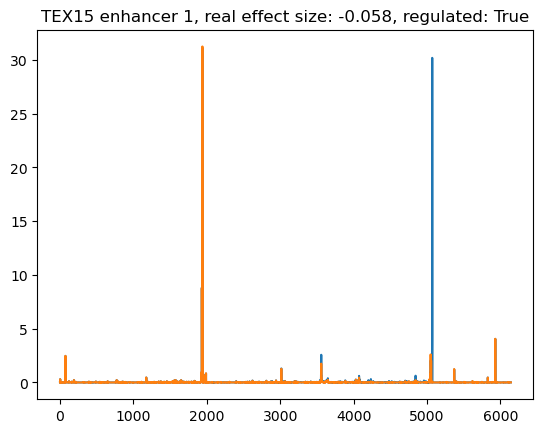

In [20]:
plt.plot(outputs[8438,1,:], label='TEX15 original')
plt.plot(outputs[8438,3,:], label='TEX15 altered')
temp = gs_df.iloc[8438]
plt.title(f'TEX15 enhancer 1, real effect size: {temp["EffectSize"]:.3f}, regulated: {temp["Regulated"]}')

Text(0.5, 1.0, 'TEX15 enhancer 1, real effect size: -0.058, regulated: True')

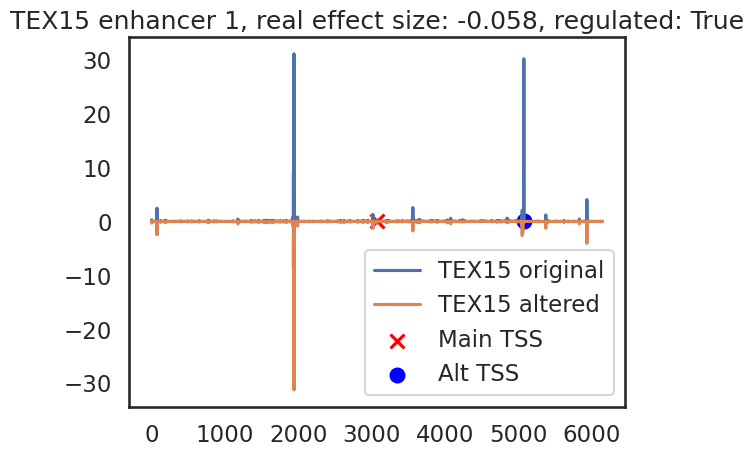

In [30]:
#let's also add some TSS sites and do some more then can make it pretty
idx = 8438

temp = gs_df.iloc[idx]
tss_info = tss_dict[temp['ensg_id']]

strand = tss_info['strand']
if strand == '+':
    idx1 = 0
    idx2 = 2
if strand == '-':
    idx1 = 1
    idx2 = 3

plt.plot(outputs[idx,idx1,:], label='TEX15 original')
plt.plot(-outputs[idx,idx2,:], label='TEX15 altered')

#now plot tss and alt TSS on here too
TSS_loc = tss_info['tss']
#main TSS is in the center bin, plot a X there
plt.scatter(len(outputs[idx,idx1,:])//2, 0, marker='x', color='red', s=100, label='Main TSS')
#now add alt TSS if it exists
if len(tss_info['alt_tss']) > 0:
    alt_TSS_loc = tss_info['alt_tss'][0] #just take the first alt TSS for now
    #calculate where this alt TSS would be in the output bins
    alt_TSS_bin = len(outputs[idx,idx1,:])//2 + (alt_TSS_loc - TSS_loc) // 32 #assuming bins are 100bp
    plt.scatter(alt_TSS_bin, 0, marker='o', color='blue', s=100, label='Alt TSS')

plt.legend()
plt.title(f'TEX15 enhancer 1, real effect size: {temp["EffectSize"]:.3f}, regulated: {temp["Regulated"]}')

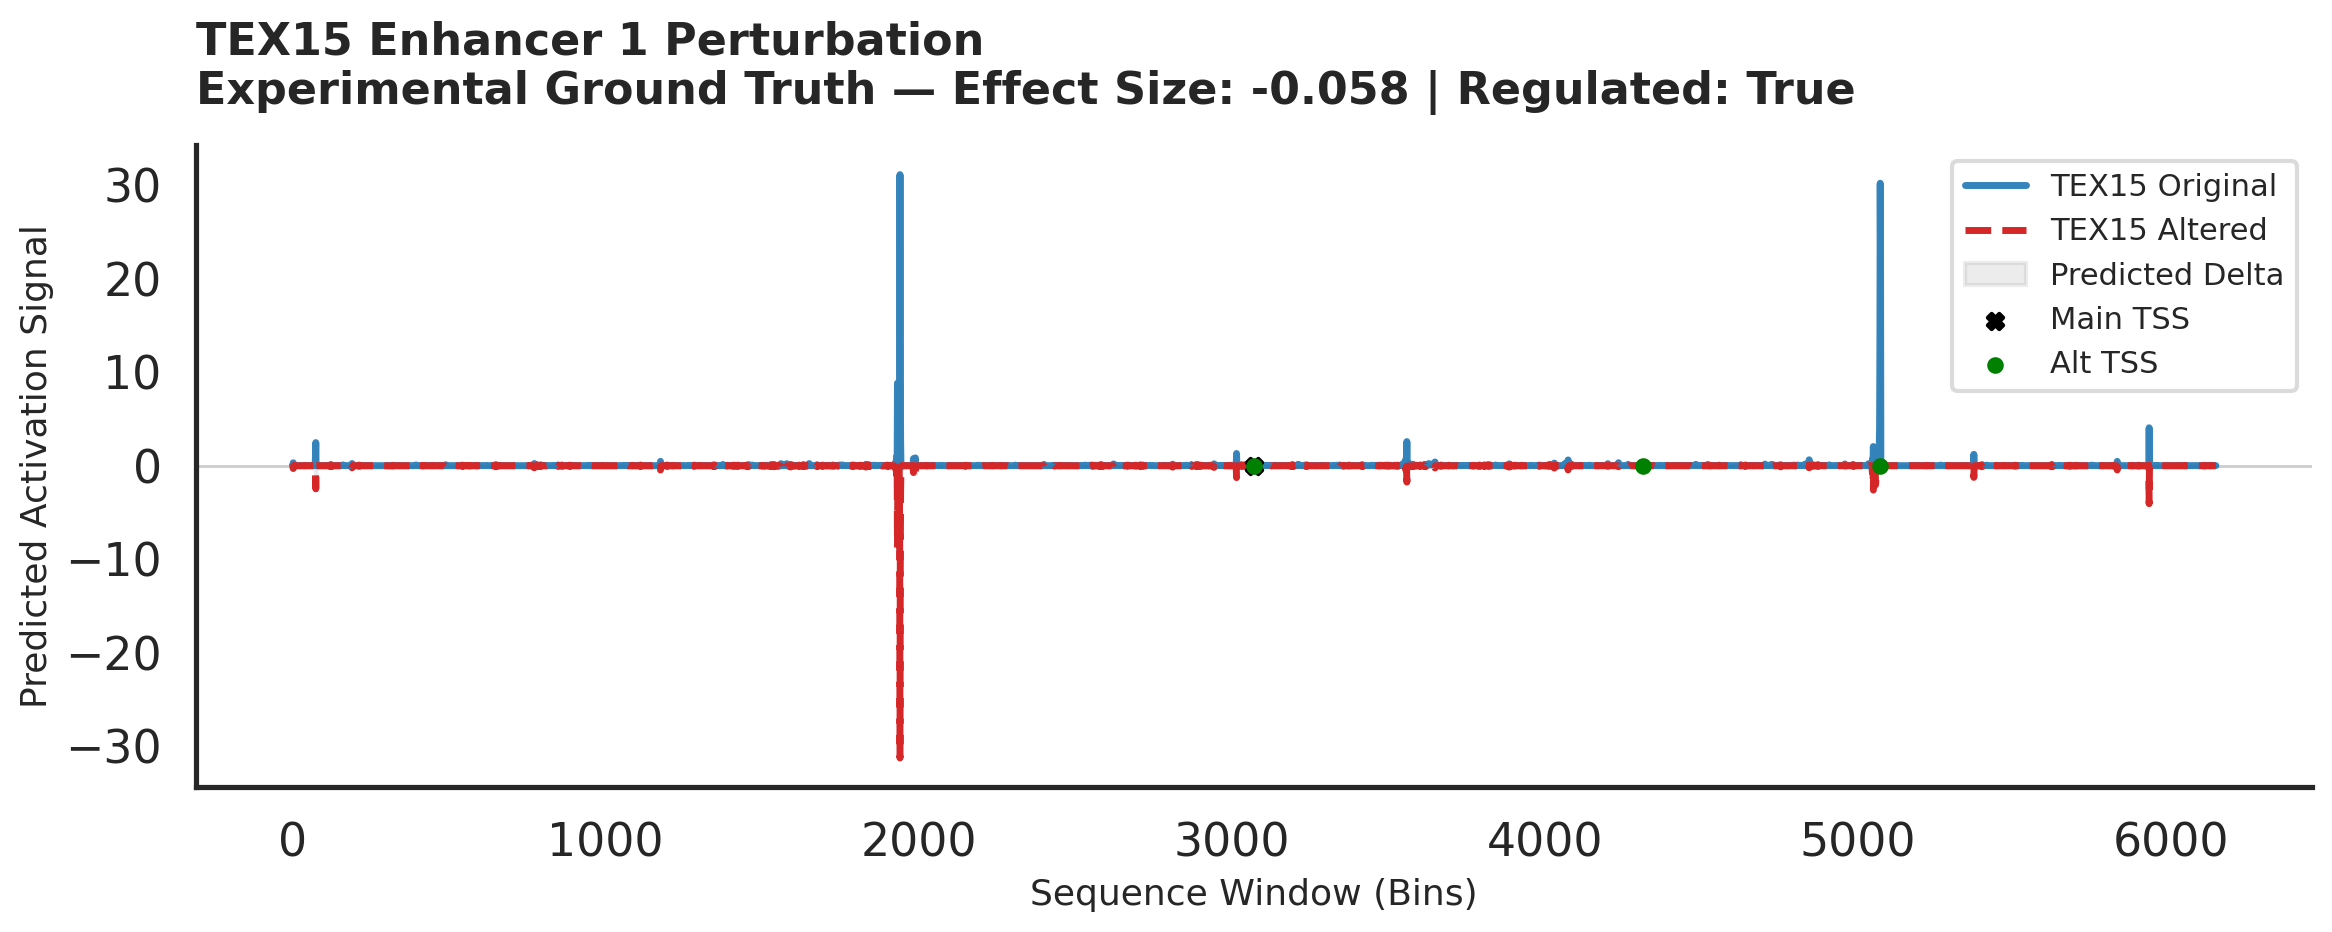

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set a clean, modern style globally
sns.set_theme(style="white", context="talk")

# Extract metadata
idx = 8438
temp = gs_df.iloc[idx]
tss_info = tss_dict[temp['ensg_id']]
strand = tss_info['strand']

# Determine indices based on strand direction
if strand == '+':
    idx1 = 0
    idx2 = 2
elif strand == '-':
    idx1 = 1
    idx2 = 3

# Extract signals (Note the negative sign on alt_signal per your logic)
orig_signal = outputs[idx, idx1, :]
alt_signal = -outputs[idx, idx2, :]
x_axis = np.arange(len(orig_signal))

# 2. Create the figure
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# 3. Plot the main signal lines
ax.plot(x_axis, orig_signal, label='TEX15 Original', color='#1f77b4', linewidth=2.5, alpha=0.9)
ax.plot(x_axis, alt_signal, label='TEX15 Altered', color='#d62728', linewidth=2.5, linestyle='--')

# 4. Fill the area between them to highlight the perturbation "Delta"
ax.fill_between(x_axis, orig_signal, alt_signal, color='grey', alpha=0.15, label='Predicted Delta')

# Add a faint baseline at y=0 so the TSS markers have a track to sit on
ax.axhline(0, color='black', linewidth=1, alpha=0.2, zorder=1)

# 5. Plot TSS locations
center_bin = len(orig_signal) // 2
TSS_loc = tss_info['tss']

# Plot Main TSS
ax.scatter(center_bin, 0, marker='X', color='black', s=30, zorder=5, label='Main TSS')

# Plot Alt TSS if it exists
if len(tss_info['alt_tss']) > 0:
    alt_tss_locs = np.zeros(len(tss_info['alt_tss']))
    for i in range(len(tss_info['alt_tss'])):
        alt_TSS_loc = tss_info['alt_tss'][i]
        
        # Calculate offset (using 32 based on your math, update if it should be 100)
        bin_resolution = 32 
        alt_TSS_bin = center_bin + ((alt_TSS_loc - TSS_loc) // bin_resolution)
        alt_tss_locs[i] = alt_TSS_bin

    ax.scatter(alt_tss_locs, np.zeros_like(alt_tss_locs), marker='o', color='green', s=20, zorder=5, label='Alt TSS')
# 6. Format the Title hierarchically
title_text = f"TEX15 Enhancer 1 Perturbation\n"
subtitle_text = f"Experimental Ground Truth — Effect Size: {temp['EffectSize']:.3f} | Regulated: {temp['Regulated']}"
ax.set_title(title_text + subtitle_text, fontsize=16, fontweight='bold', loc='left', pad=15)

# 7. Clean up the axes and borders
ax.set_xlabel("Sequence Window (Bins)", fontsize=13, fontweight='medium')
ax.set_ylabel("Predicted Activation Signal", fontsize=13, fontweight='medium')
sns.despine(ax=ax)

# 8. Style the legend
# bbox_to_anchor pulls it slightly outside the plot if you have a lot of labels
ax.legend(frameon=True, edgecolor='lightgrey', fontsize=11)

# Ensure perfect spacing
plt.tight_layout()
plt.show()

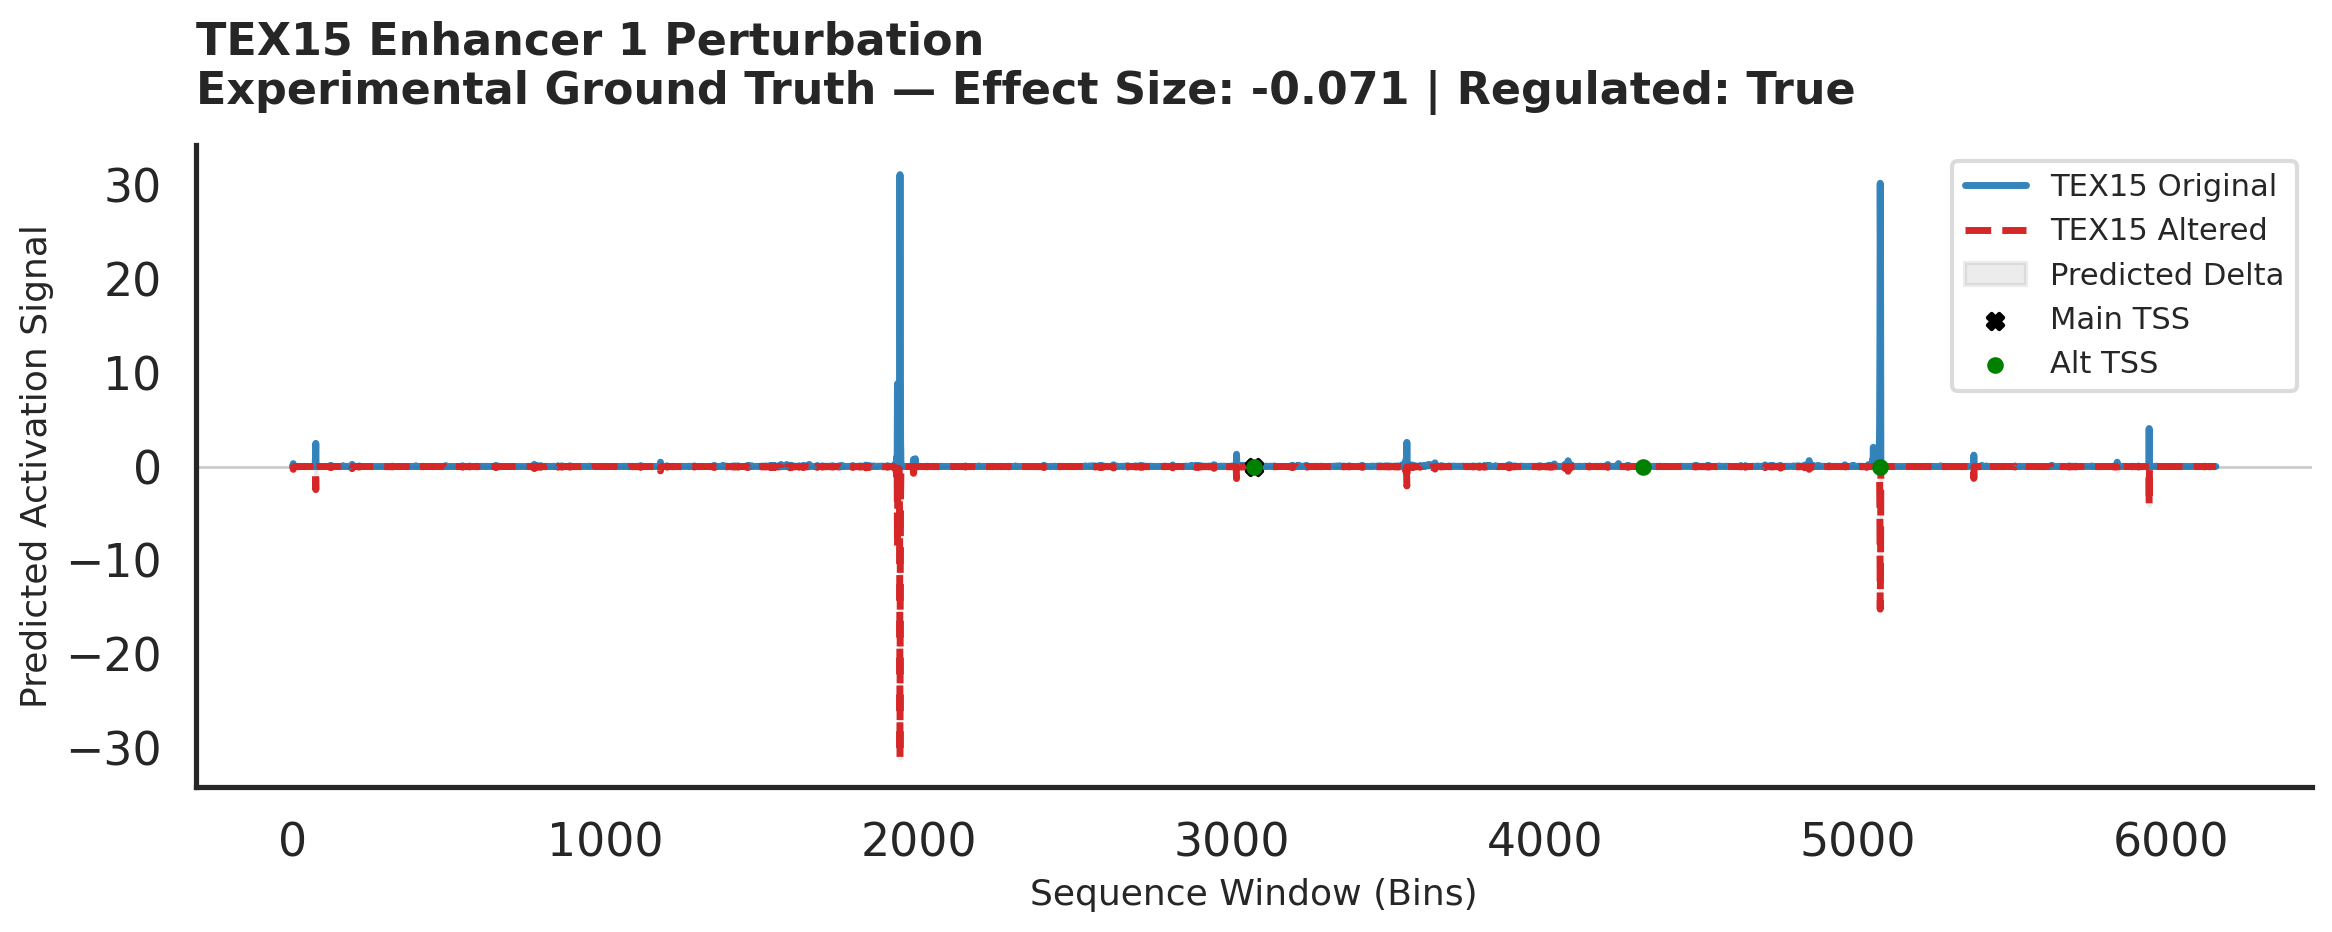

In [51]:
#next one
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set a clean, modern style globally
sns.set_theme(style="white", context="talk")

# Extract metadata
idx = 8437
temp = gs_df.iloc[idx]
tss_info = tss_dict[temp['ensg_id']]
strand = tss_info['strand']

# Determine indices based on strand direction
if strand == '+':
    idx1 = 0
    idx2 = 2
elif strand == '-':
    idx1 = 1
    idx2 = 3

# Extract signals (Note the negative sign on alt_signal per your logic)
orig_signal = outputs[idx, idx1, :]
alt_signal = -outputs[idx, idx2, :]
x_axis = np.arange(len(orig_signal))

# 2. Create the figure
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# 3. Plot the main signal lines
ax.plot(x_axis, orig_signal, label='TEX15 Original', color='#1f77b4', linewidth=2.5, alpha=0.9)
ax.plot(x_axis, alt_signal, label='TEX15 Altered', color='#d62728', linewidth=2.5, linestyle='--')

# 4. Fill the area between them to highlight the perturbation "Delta"
ax.fill_between(x_axis, orig_signal, alt_signal, color='grey', alpha=0.15, label='Predicted Delta')

# Add a faint baseline at y=0 so the TSS markers have a track to sit on
ax.axhline(0, color='black', linewidth=1, alpha=0.2, zorder=1)

# 5. Plot TSS locations
center_bin = len(orig_signal) // 2
TSS_loc = tss_info['tss']

# Plot Main TSS
ax.scatter(center_bin, 0, marker='X', color='black', s=30, zorder=5, label='Main TSS')

# Plot Alt TSS if it exists
if len(tss_info['alt_tss']) > 0:
    alt_tss_locs = np.zeros(len(tss_info['alt_tss']))
    for i in range(len(tss_info['alt_tss'])):
        alt_TSS_loc = tss_info['alt_tss'][i]
        
        # Calculate offset (using 32 based on your math, update if it should be 100)
        bin_resolution = 32 
        alt_TSS_bin = center_bin + ((alt_TSS_loc - TSS_loc) // bin_resolution)
        alt_tss_locs[i] = alt_TSS_bin

    ax.scatter(alt_tss_locs, np.zeros_like(alt_tss_locs), marker='o', color='green', s=20, zorder=5, label='Alt TSS')

# 6. Format the Title hierarchically
title_text = f"TEX15 Enhancer 1 Perturbation\n"
subtitle_text = f"Experimental Ground Truth — Effect Size: {temp['EffectSize']:.3f} | Regulated: {temp['Regulated']}"
ax.set_title(title_text + subtitle_text, fontsize=16, fontweight='bold', loc='left', pad=15)

# 7. Clean up the axes and borders
ax.set_xlabel("Sequence Window (Bins)", fontsize=13, fontweight='medium')
ax.set_ylabel("Predicted Activation Signal", fontsize=13, fontweight='medium')
sns.despine(ax=ax)

# 8. Style the legend
# bbox_to_anchor pulls it slightly outside the plot if you have a lot of labels
ax.legend(frameon=True, edgecolor='lightgrey', fontsize=11)

# Ensure perfect spacing
plt.tight_layout()
plt.show()

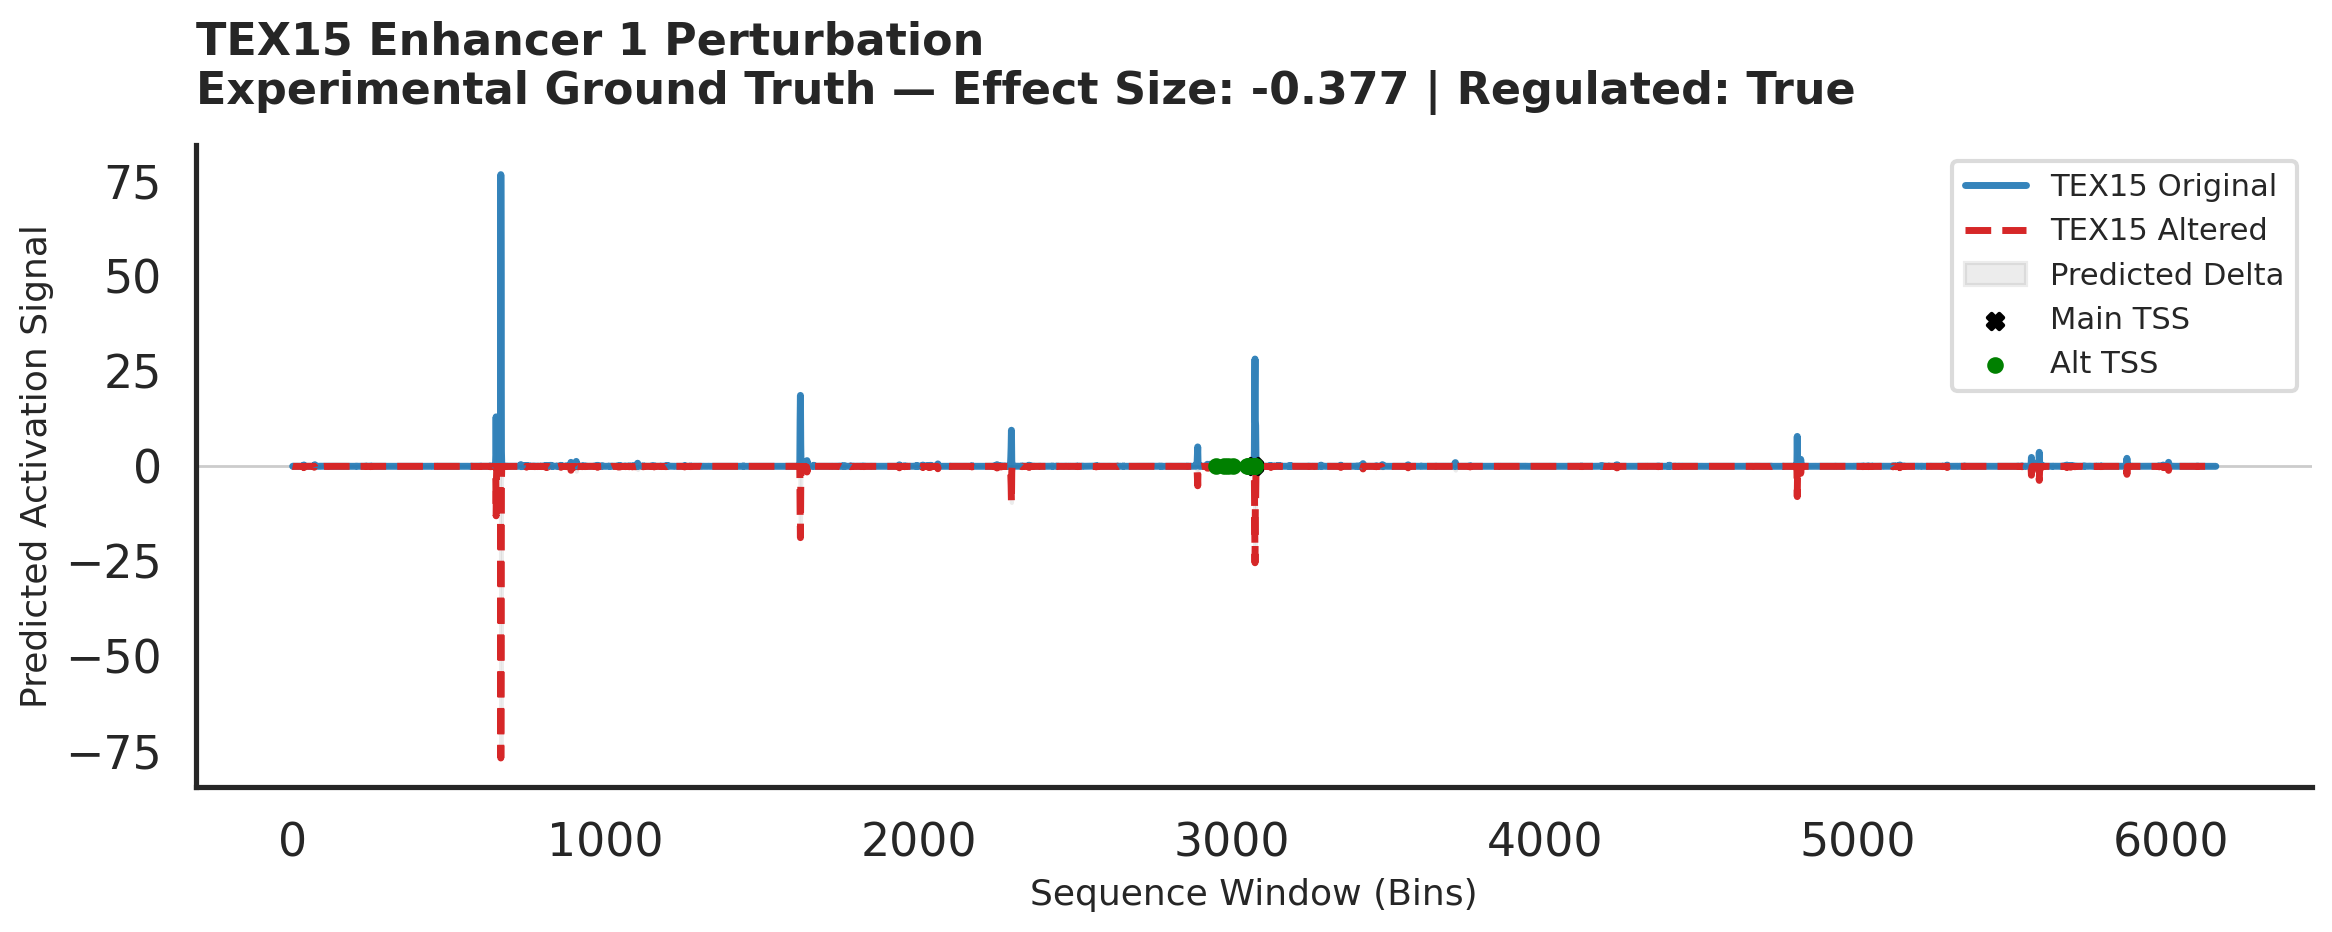

In [53]:
#next one
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set a clean, modern style globally
sns.set_theme(style="white", context="talk")

# Extract metadata
idx = 1090
temp = gs_df.iloc[idx]
tss_info = tss_dict[temp['ensg_id']]
strand = tss_info['strand']

# Determine indices based on strand direction
if strand == '+':
    idx1 = 0
    idx2 = 2
elif strand == '-':
    idx1 = 1
    idx2 = 3

# Extract signals (Note the negative sign on alt_signal per your logic)
orig_signal = outputs[idx, idx1, :]
alt_signal = -outputs[idx, idx2, :]
x_axis = np.arange(len(orig_signal))

# 2. Create the figure
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# 3. Plot the main signal lines
ax.plot(x_axis, orig_signal, label='TEX15 Original', color='#1f77b4', linewidth=2.5, alpha=0.9)
ax.plot(x_axis, alt_signal, label='TEX15 Altered', color='#d62728', linewidth=2.5, linestyle='--')

# 4. Fill the area between them to highlight the perturbation "Delta"
ax.fill_between(x_axis, orig_signal, alt_signal, color='grey', alpha=0.15, label='Predicted Delta')

# Add a faint baseline at y=0 so the TSS markers have a track to sit on
ax.axhline(0, color='black', linewidth=1, alpha=0.2, zorder=1)

# 5. Plot TSS locations
center_bin = len(orig_signal) // 2
TSS_loc = tss_info['tss']

# Plot Main TSS
# Plot Main TSS
ax.scatter(center_bin, 0, marker='X', color='black', s=30, zorder=5, label='Main TSS')

# Plot Alt TSS if it exists
if len(tss_info['alt_tss']) > 0:
    alt_tss_locs = np.zeros(len(tss_info['alt_tss']))
    for i in range(len(tss_info['alt_tss'])):
        alt_TSS_loc = tss_info['alt_tss'][i]
        
        # Calculate offset (using 32 based on your math, update if it should be 100)
        bin_resolution = 32 
        alt_TSS_bin = center_bin + ((alt_TSS_loc - TSS_loc) // bin_resolution)
        alt_tss_locs[i] = alt_TSS_bin

    ax.scatter(alt_tss_locs, np.zeros_like(alt_tss_locs), marker='o', color='green', s=20, zorder=5, label='Alt TSS')

# 6. Format the Title hierarchically
title_text = f"TEX15 Enhancer 1 Perturbation\n"
subtitle_text = f"Experimental Ground Truth — Effect Size: {temp['EffectSize']:.3f} | Regulated: {temp['Regulated']}"
ax.set_title(title_text + subtitle_text, fontsize=16, fontweight='bold', loc='left', pad=15)

# 7. Clean up the axes and borders
ax.set_xlabel("Sequence Window (Bins)", fontsize=13, fontweight='medium')
ax.set_ylabel("Predicted Activation Signal", fontsize=13, fontweight='medium')
sns.despine(ax=ax)

# 8. Style the legend
# bbox_to_anchor pulls it slightly outside the plot if you have a lot of labels
ax.legend(frameon=True, edgecolor='lightgrey', fontsize=11)

# Ensure perfect spacing
plt.tight_layout()
plt.show()

In [42]:
score_vector[1090]

-0.20505510265721708

In [ ]:
outputs[1090,]

In [58]:
#let's manually check this scoring to see if it makes sense
outputs[1090,0].sum()

471.96625

In [57]:
outputs[1091,2].sum()

468.67157

In [59]:
outputs.shape

(10280, 4, 6144)

In [65]:
#now let's do this
a = outputs[1090,0,6144//2-20:6144//2+20].sum()
b = outputs[1090,2,6144//2-20:6144//2+20].sum()
print(a,b), print(np.log2((b+1)/(a+1)))

80.7258 70.028694
-0.20238962467247307


(None, None)

In [70]:
np.log2(70/80)

-0.1926450779423959

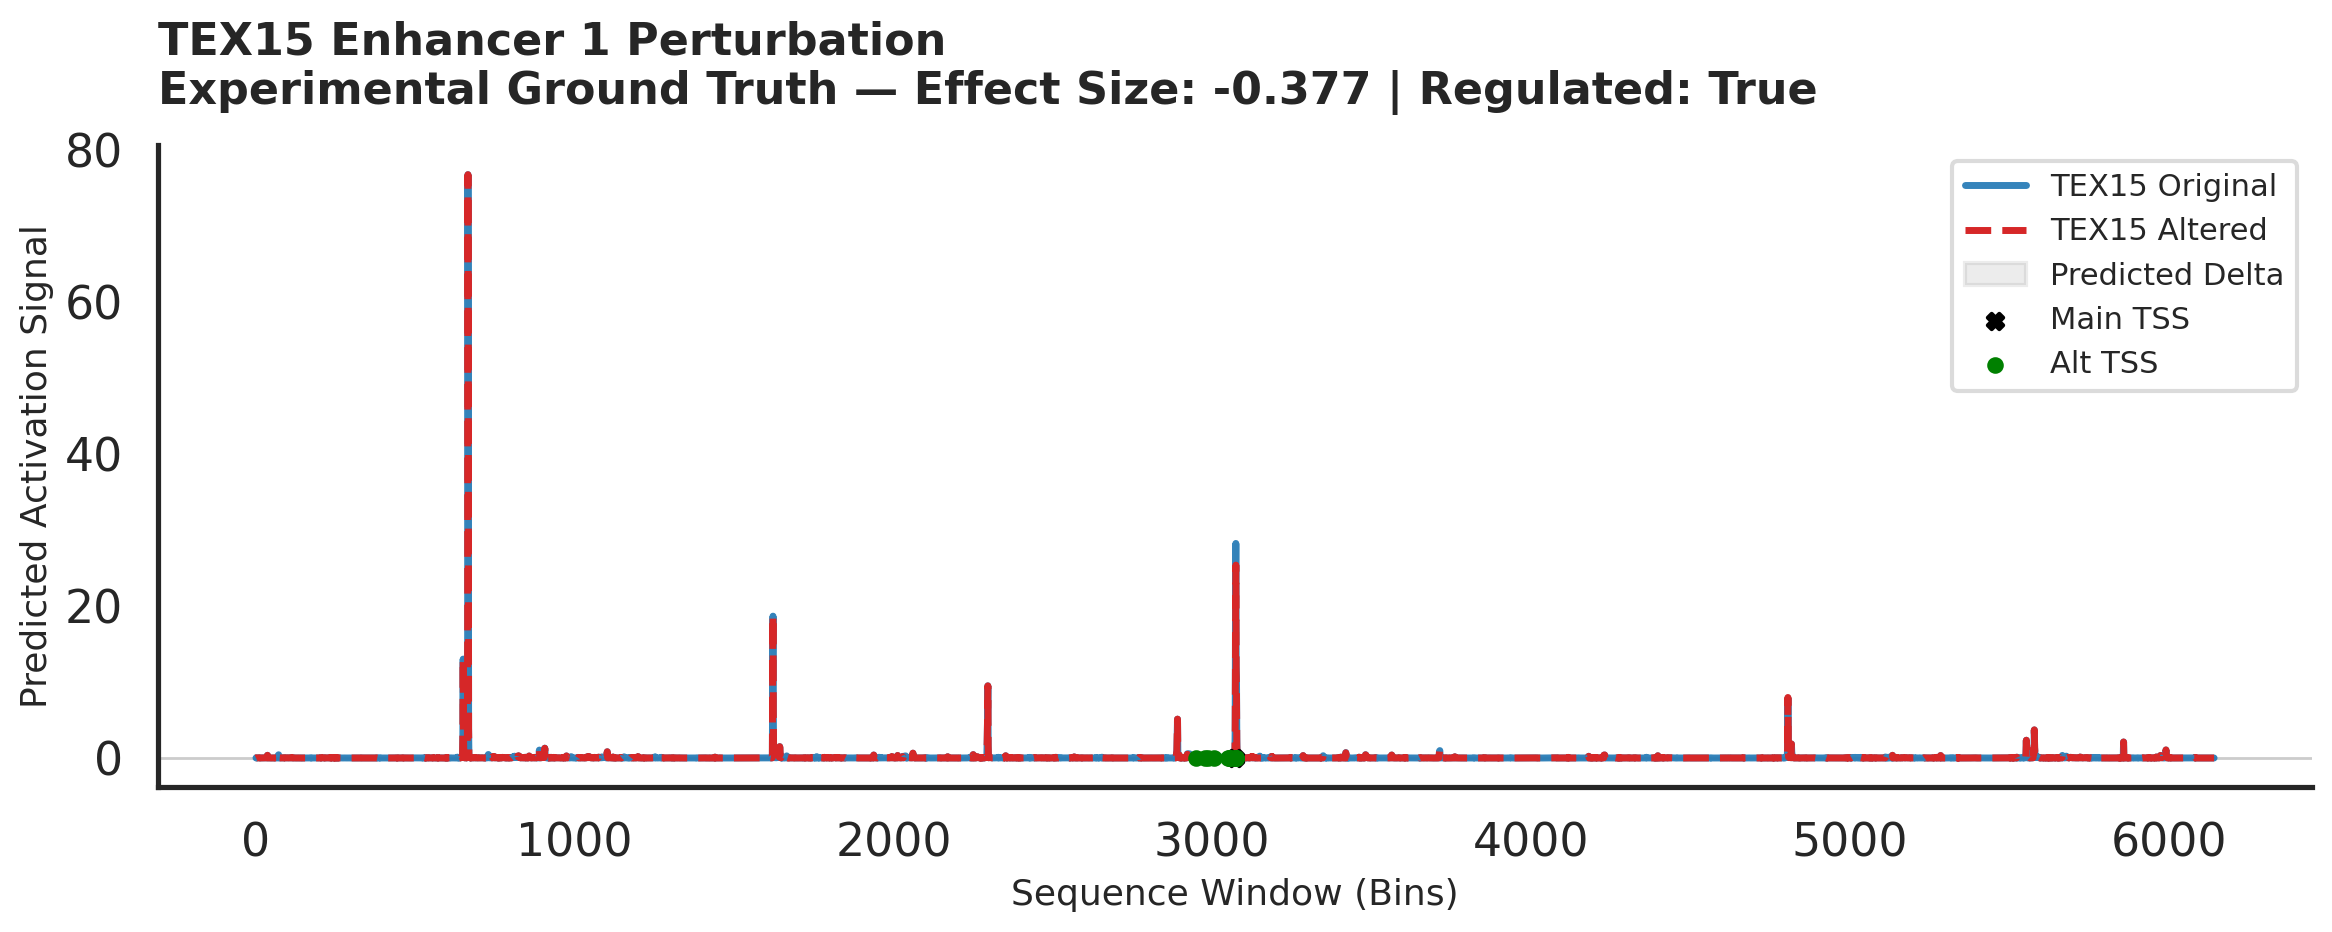

In [66]:
#next one
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set a clean, modern style globally
sns.set_theme(style="white", context="talk")

# Extract metadata
idx = 1090
temp = gs_df.iloc[idx]
tss_info = tss_dict[temp['ensg_id']]
strand = tss_info['strand']

# Determine indices based on strand direction
if strand == '+':
    idx1 = 0
    idx2 = 2
elif strand == '-':
    idx1 = 1
    idx2 = 3

# Extract signals (Note the negative sign on alt_signal per your logic)
orig_signal = outputs[idx, idx1, :]
alt_signal = outputs[idx, idx2, :]
x_axis = np.arange(len(orig_signal))

# 2. Create the figure
fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

# 3. Plot the main signal lines
ax.plot(x_axis, orig_signal, label='TEX15 Original', color='#1f77b4', linewidth=2.5, alpha=0.9)
ax.plot(x_axis, alt_signal, label='TEX15 Altered', color='#d62728', linewidth=2.5, linestyle='--')

# 4. Fill the area between them to highlight the perturbation "Delta"
ax.fill_between(x_axis, orig_signal, alt_signal, color='grey', alpha=0.15, label='Predicted Delta')

# Add a faint baseline at y=0 so the TSS markers have a track to sit on
ax.axhline(0, color='black', linewidth=1, alpha=0.2, zorder=1)

# 5. Plot TSS locations
center_bin = len(orig_signal) // 2
TSS_loc = tss_info['tss']

# Plot Main TSS
# Plot Main TSS
ax.scatter(center_bin, 0, marker='X', color='black', s=30, zorder=5, label='Main TSS')

# Plot Alt TSS if it exists
if len(tss_info['alt_tss']) > 0:
    alt_tss_locs = np.zeros(len(tss_info['alt_tss']))
    for i in range(len(tss_info['alt_tss'])):
        alt_TSS_loc = tss_info['alt_tss'][i]
        
        # Calculate offset (using 32 based on your math, update if it should be 100)
        bin_resolution = 32 
        alt_TSS_bin = center_bin + ((alt_TSS_loc - TSS_loc) // bin_resolution)
        alt_tss_locs[i] = alt_TSS_bin

    ax.scatter(alt_tss_locs, np.zeros_like(alt_tss_locs), marker='o', color='green', s=20, zorder=5, label='Alt TSS')

# 6. Format the Title hierarchically
title_text = f"TEX15 Enhancer 1 Perturbation\n"
subtitle_text = f"Experimental Ground Truth — Effect Size: {temp['EffectSize']:.3f} | Regulated: {temp['Regulated']}"
ax.set_title(title_text + subtitle_text, fontsize=16, fontweight='bold', loc='left', pad=15)

# 7. Clean up the axes and borders
ax.set_xlabel("Sequence Window (Bins)", fontsize=13, fontweight='medium')
ax.set_ylabel("Predicted Activation Signal", fontsize=13, fontweight='medium')
sns.despine(ax=ax)

# 8. Style the legend
# bbox_to_anchor pulls it slightly outside the plot if you have a lot of labels
ax.legend(frameon=True, edgecolor='lightgrey', fontsize=11)

# Ensure perfect spacing
plt.tight_layout()
plt.show()

In [71]:
temp

dataset                                             TAPseq
chrom                                                chr11
chromStart                                          316244
chromEnd                                            316608
name                          IFITM1|chr11:316244-316608:.
EffectSize                                       -0.377222
chrTSS                                               chr11
startTSS                                          313506.0
endTSS                                            313507.0
measuredGeneSymbol                                  IFITM1
Significant                                           True
pValueAdjusted                                         0.0
PowerAtEffectSize25                                    1.0
ValidConnection                                       True
CellType                                              K562
Reference                         Schraivogel et al., 2020
Regulated                                             Tr

In [86]:
#make the plot a function like it should have been
def plot_perturbation(idx, flip=True):
    # Extract metadata
    temp = gs_df.iloc[idx]
    tss_info = tss_dict[temp['ensg_id']]
    strand = tss_info['strand']

    # Determine indices based on strand direction
    if strand == '+':
        idx1 = 0
        idx2 = 2
    elif strand == '-':
        idx1 = 1
        idx2 = 3

    # Extract signals (Note the negative sign on alt_signal per your logic)
    orig_signal = outputs[idx, idx1, :]
    if flip:
        alt_signal = -outputs[idx, idx2, :]
    else:
        alt_signal = outputs[idx, idx2, :]
    x_axis = np.arange(len(orig_signal))

    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

    # Plot the main signal lines
    ax.plot(x_axis, orig_signal, label='Original', color='#1f77b4', linewidth=2.5, alpha=0.9)
    ax.plot(x_axis, alt_signal, label='Altered', color='#d62728', linewidth=2.5, linestyle='--')

    # Fill the area between them to highlight the perturbation "Delta"
    ax.fill_between(x_axis, orig_signal, alt_signal, color='grey', alpha=0.15, label='Predicted Delta')

    # Add a faint baseline at y=0 so the TSS markers have a track to sit on
    ax.axhline(0, color='black', linewidth=1, alpha=0.2, zorder=1)

    # Plot TSS locations
    center_bin = len(orig_signal) // 2
    TSS_loc = tss_info['tss']

    # Plot Main TSS
    ax.scatter(center_bin, 0, marker='X', color='black', s=30, zorder=5, label='Main TSS')

    # Plot Alt TSS if it exists
    if len(tss_info['alt_tss']) > 0:
        alt_tss_locs = np.zeros(len(tss_info['alt_tss']))
        for i in range(len(tss_info['alt_tss'])):
            alt_TSS_loc = tss_info['alt_tss'][i]
            
            # Calculate offset (using 32 based on your math, update if it should be 100)
            bin_resolution = 32 
            alt_TSS_bin = center_bin + ((alt_TSS_loc - TSS_loc) // bin_resolution)
            alt_tss_locs[i] = alt_TSS_bin
    
        ax.scatter(alt_tss_locs, np.zeros_like(alt_tss_locs), marker='o', color='green', s=20, zorder=5, label='Alt TSS')
        
    #let's also put a point indication for the enhancer
    
    enhancer_loc = (temp['chromStart'] + temp['chromEnd']) // 2 #just take the middle of the enhancer for now
    enhancer_bin = center_bin + ((enhancer_loc - TSS_loc) // bin_resolution)
    ax.scatter(enhancer_bin, 0, marker='*', color='purple', s=100, zorder=5, label='Enhancer')
    
    # Format the Title hierarchically
    # 6. Format the Title hierarchically
    title_text = f"{temp['measuredGeneSymbol']} Enhancer Perturbation\n"
    subtitle_text = f"Experimental Ground Truth — Effect Size: {temp['EffectSize']:.3f} | Regulated: {temp['Regulated']}"
    scores = f"My Score: {score_vector[idx]:.3f} | rE2G Score: {100*e2g_score_vector[idx]:.3f}%"
    ax.set_title(title_text + subtitle_text + scores, fontsize=12, fontweight='bold', loc='left', pad=15)

    # 7. Clean up the axes and borders
    ax.set_xlabel("Sequence Window (Bins)", fontsize=13, fontweight='medium')
    ax.set_ylabel("Predicted Activation Signal", fontsize=13, fontweight='medium')
    sns.despine(ax=ax)

    # 8. Style the legend
    # bbox_to_anchor pulls it slightly outside the plot if you have a lot of labels
    ax.legend(frameon=True, edgecolor='lightgrey', fontsize=11)

    # Ensure perfect spacing
    plt.tight_layout()
    plt.show()

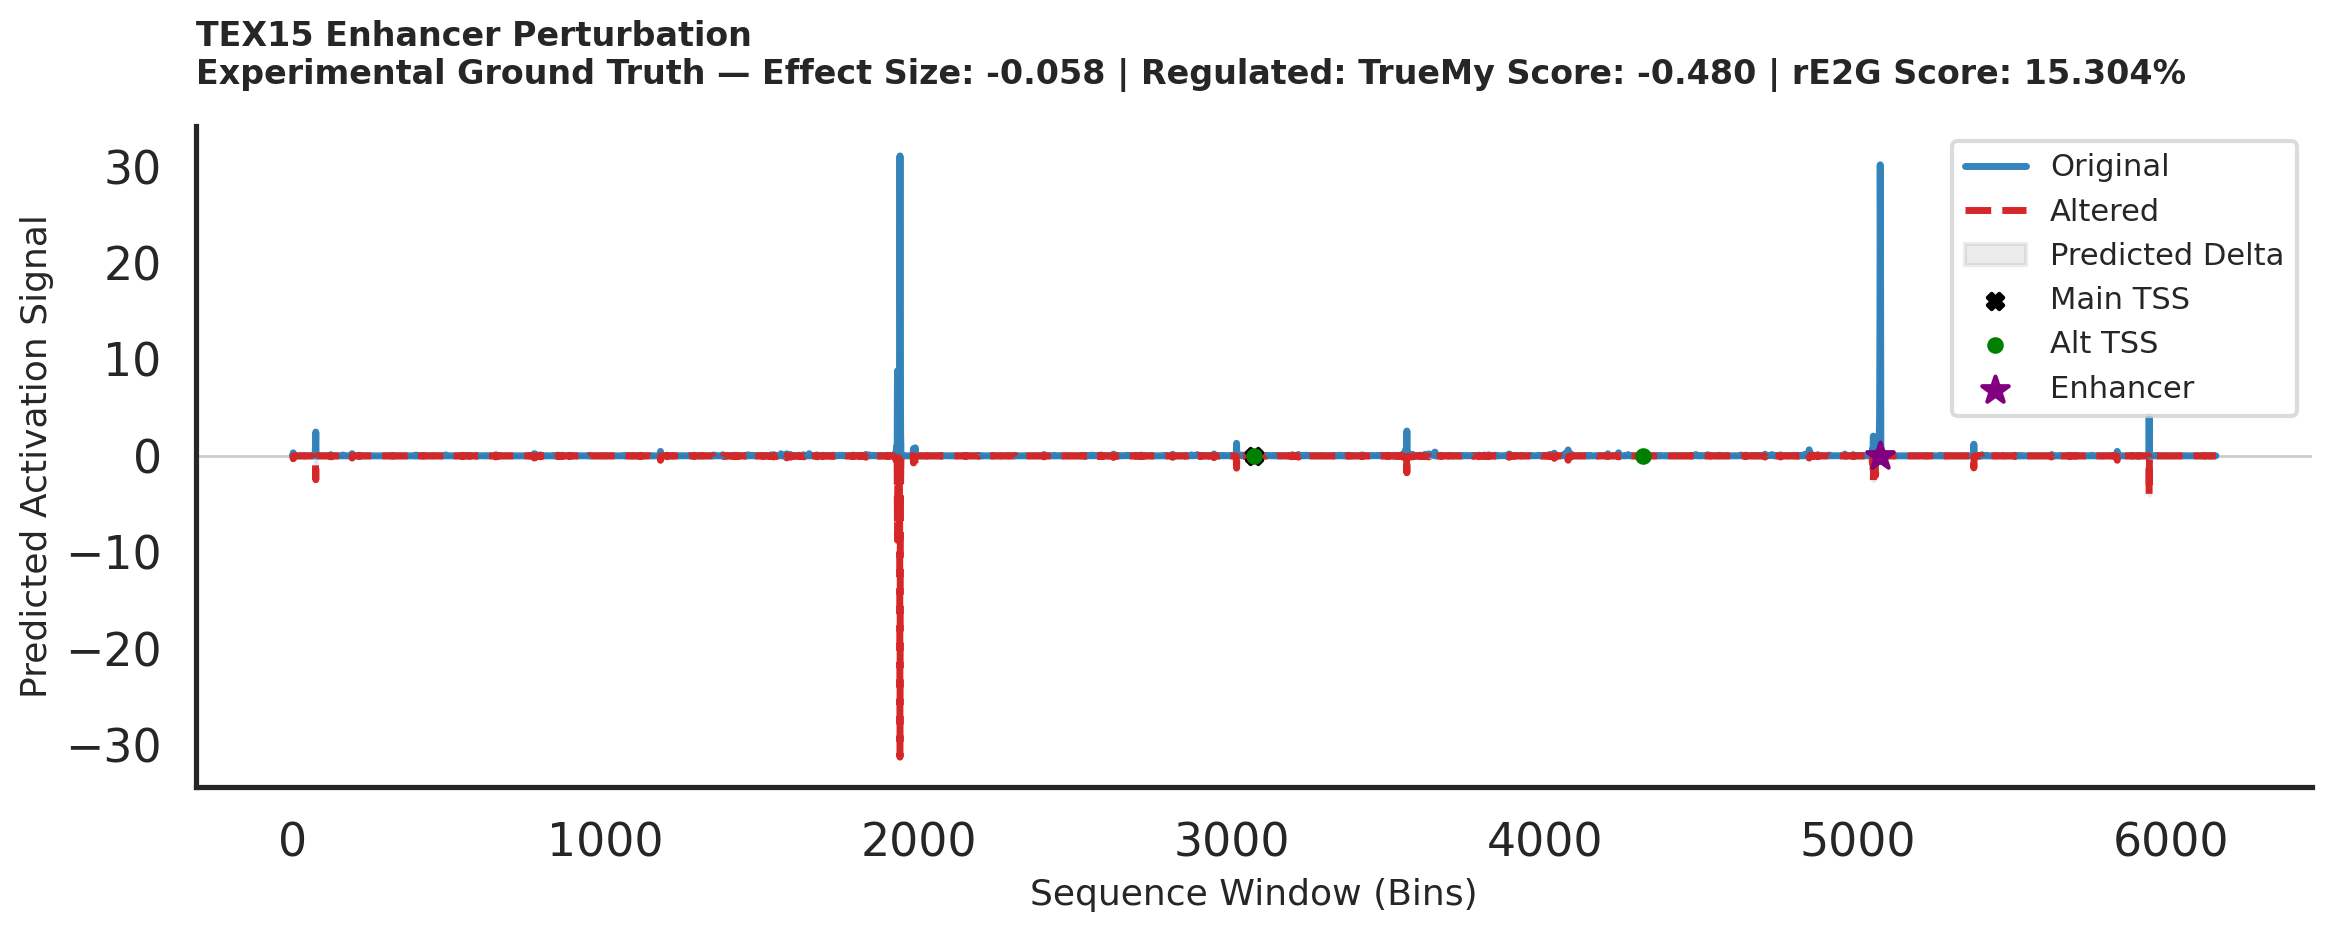

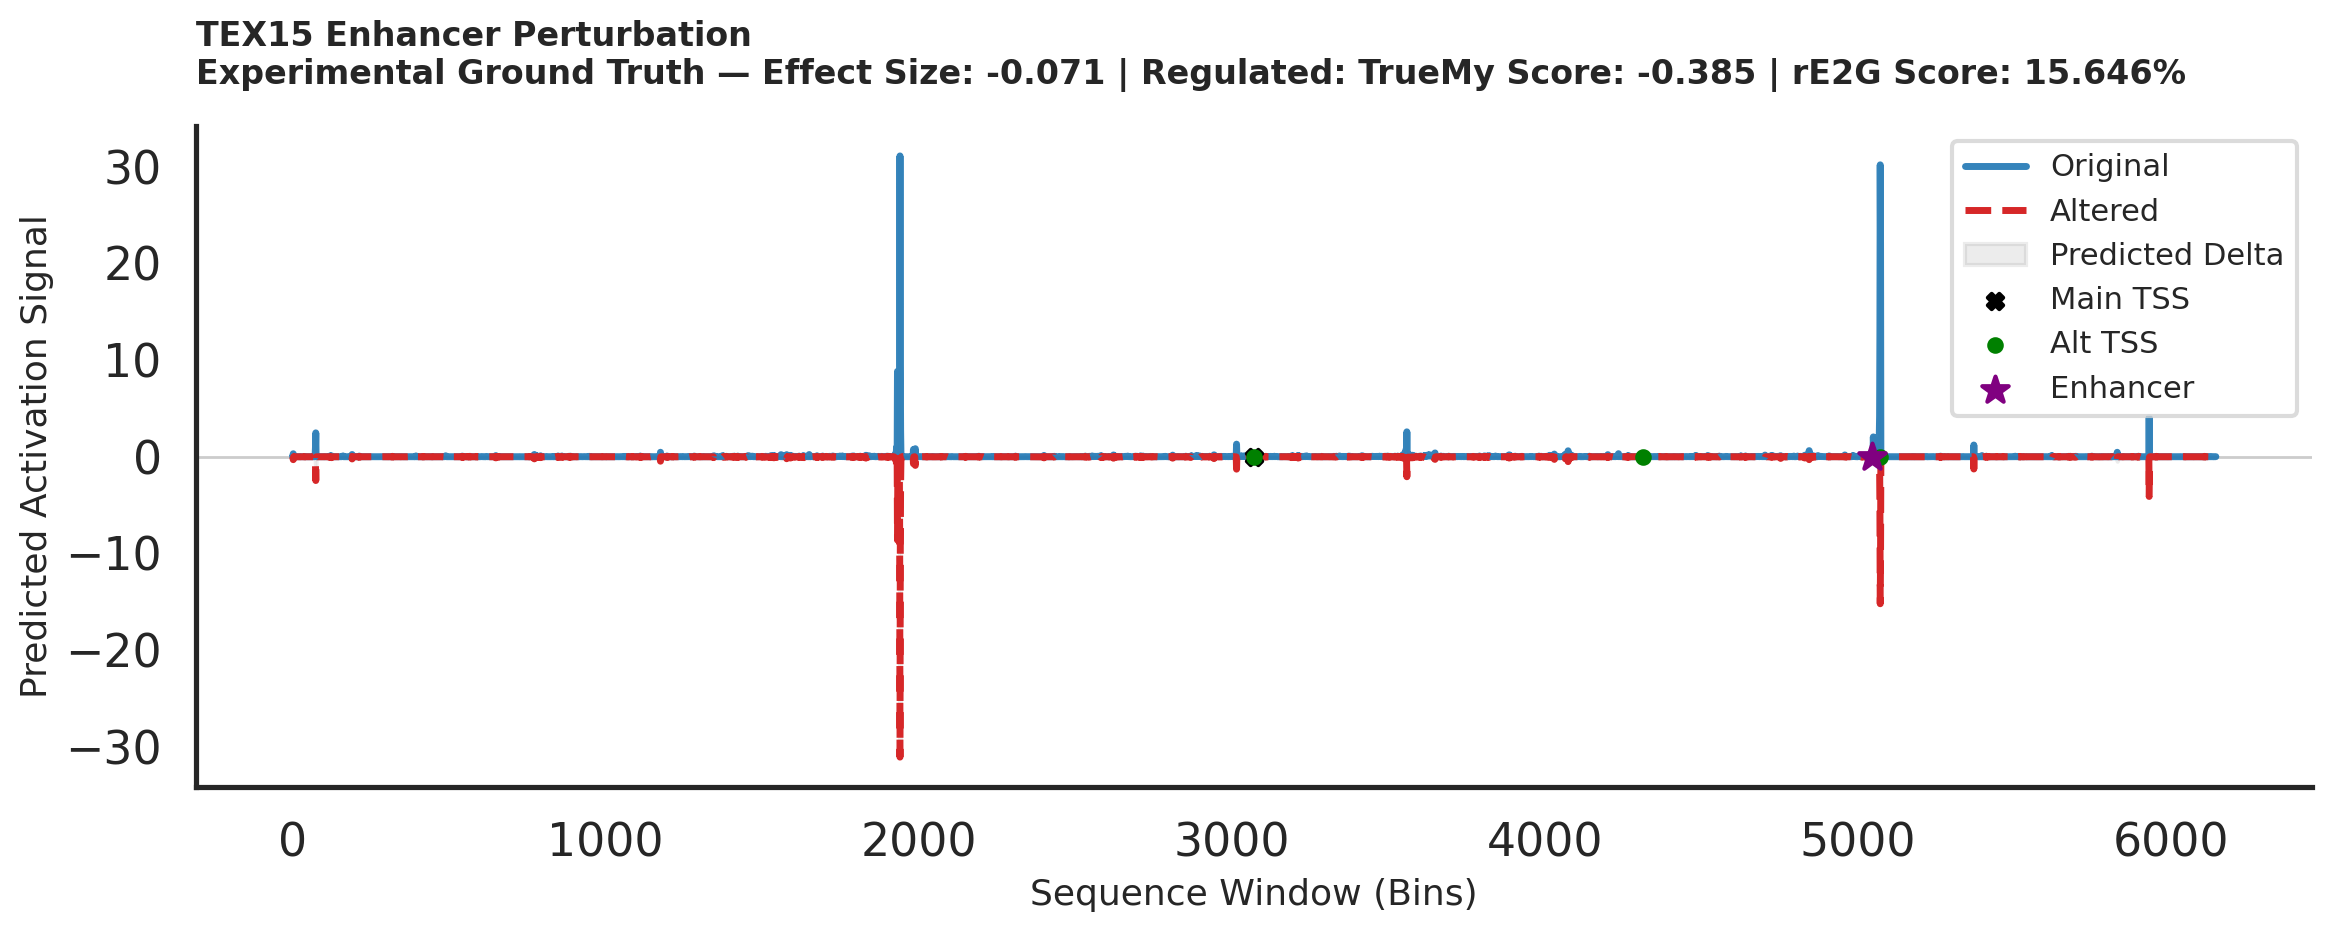

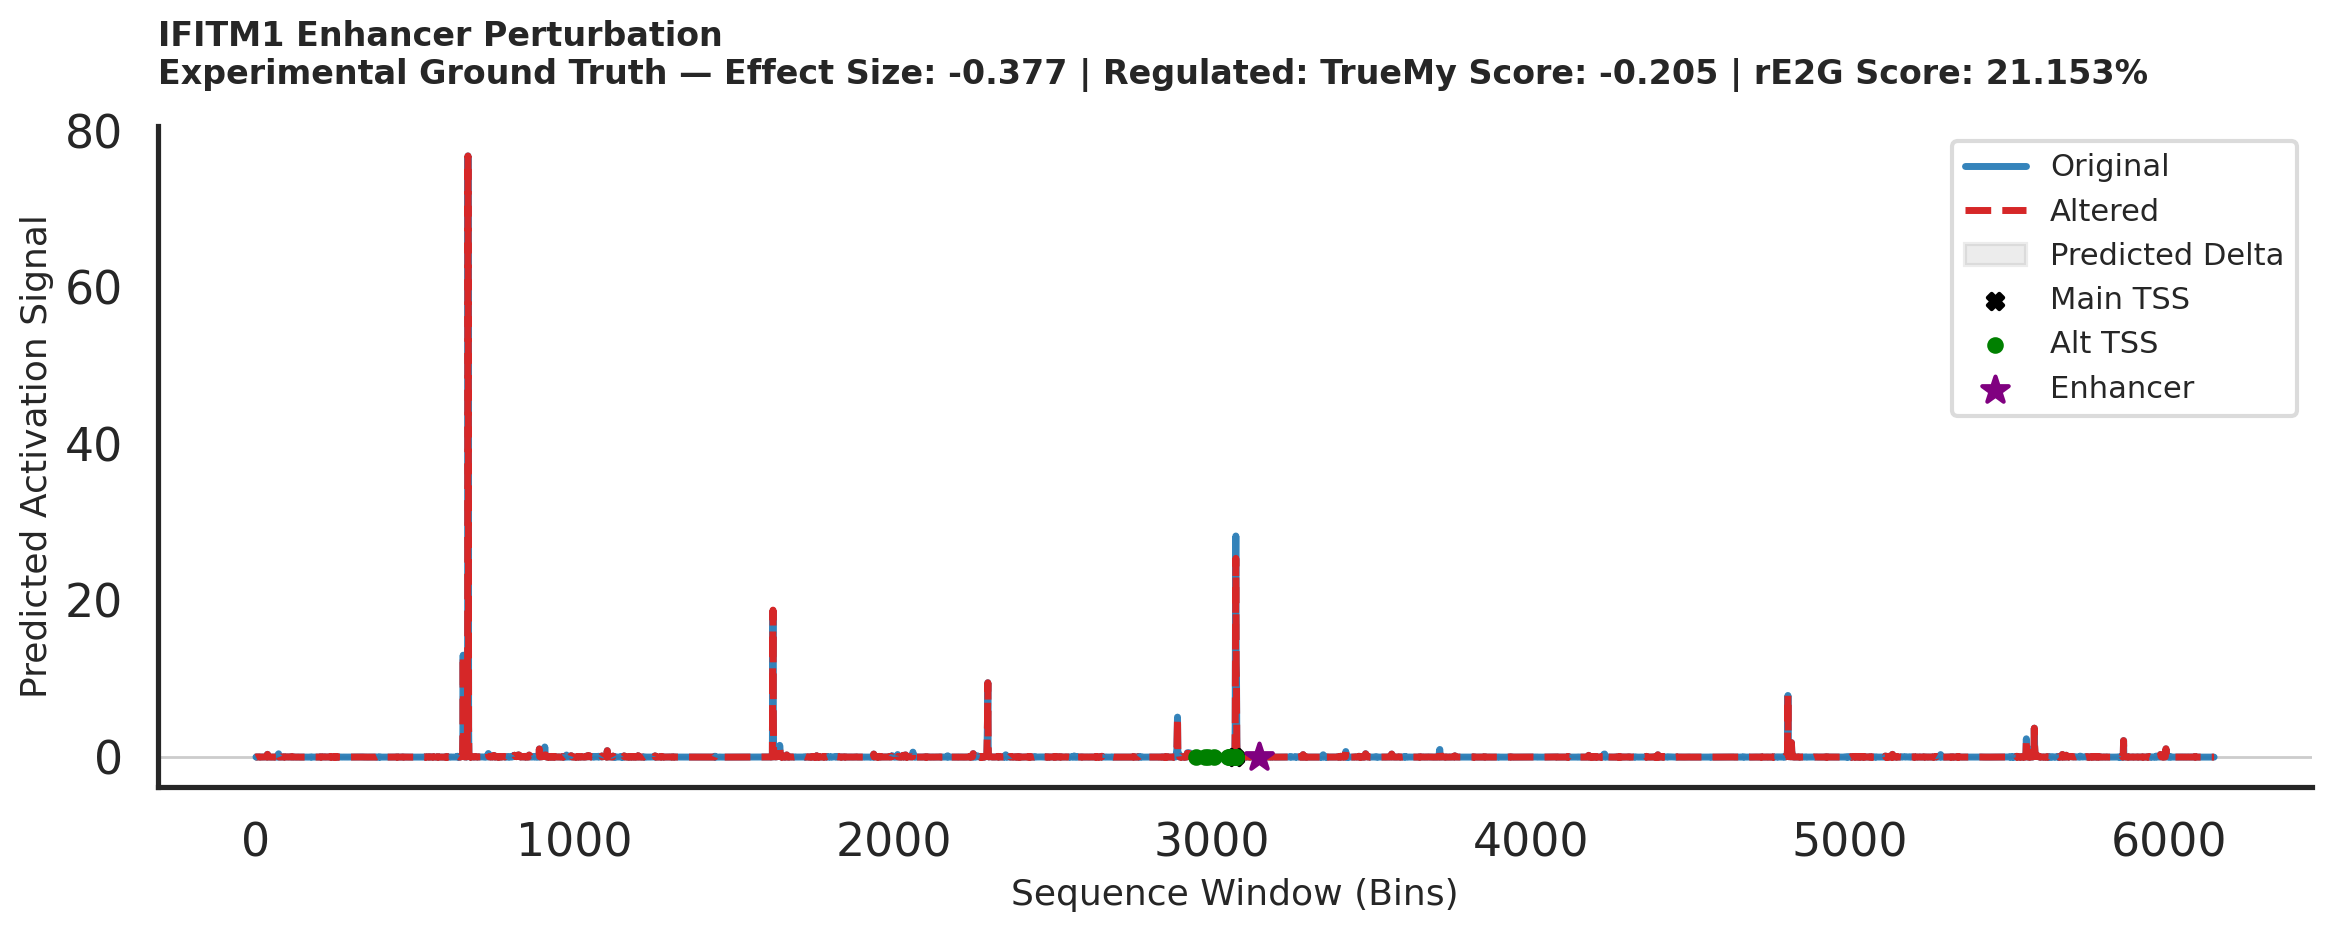

In [87]:
#let's plot it
plot_perturbation(8438)
plot_perturbation(8437)
plot_perturbation(1090, flip=False)

In [89]:
distance_vector[8438]

22410.5

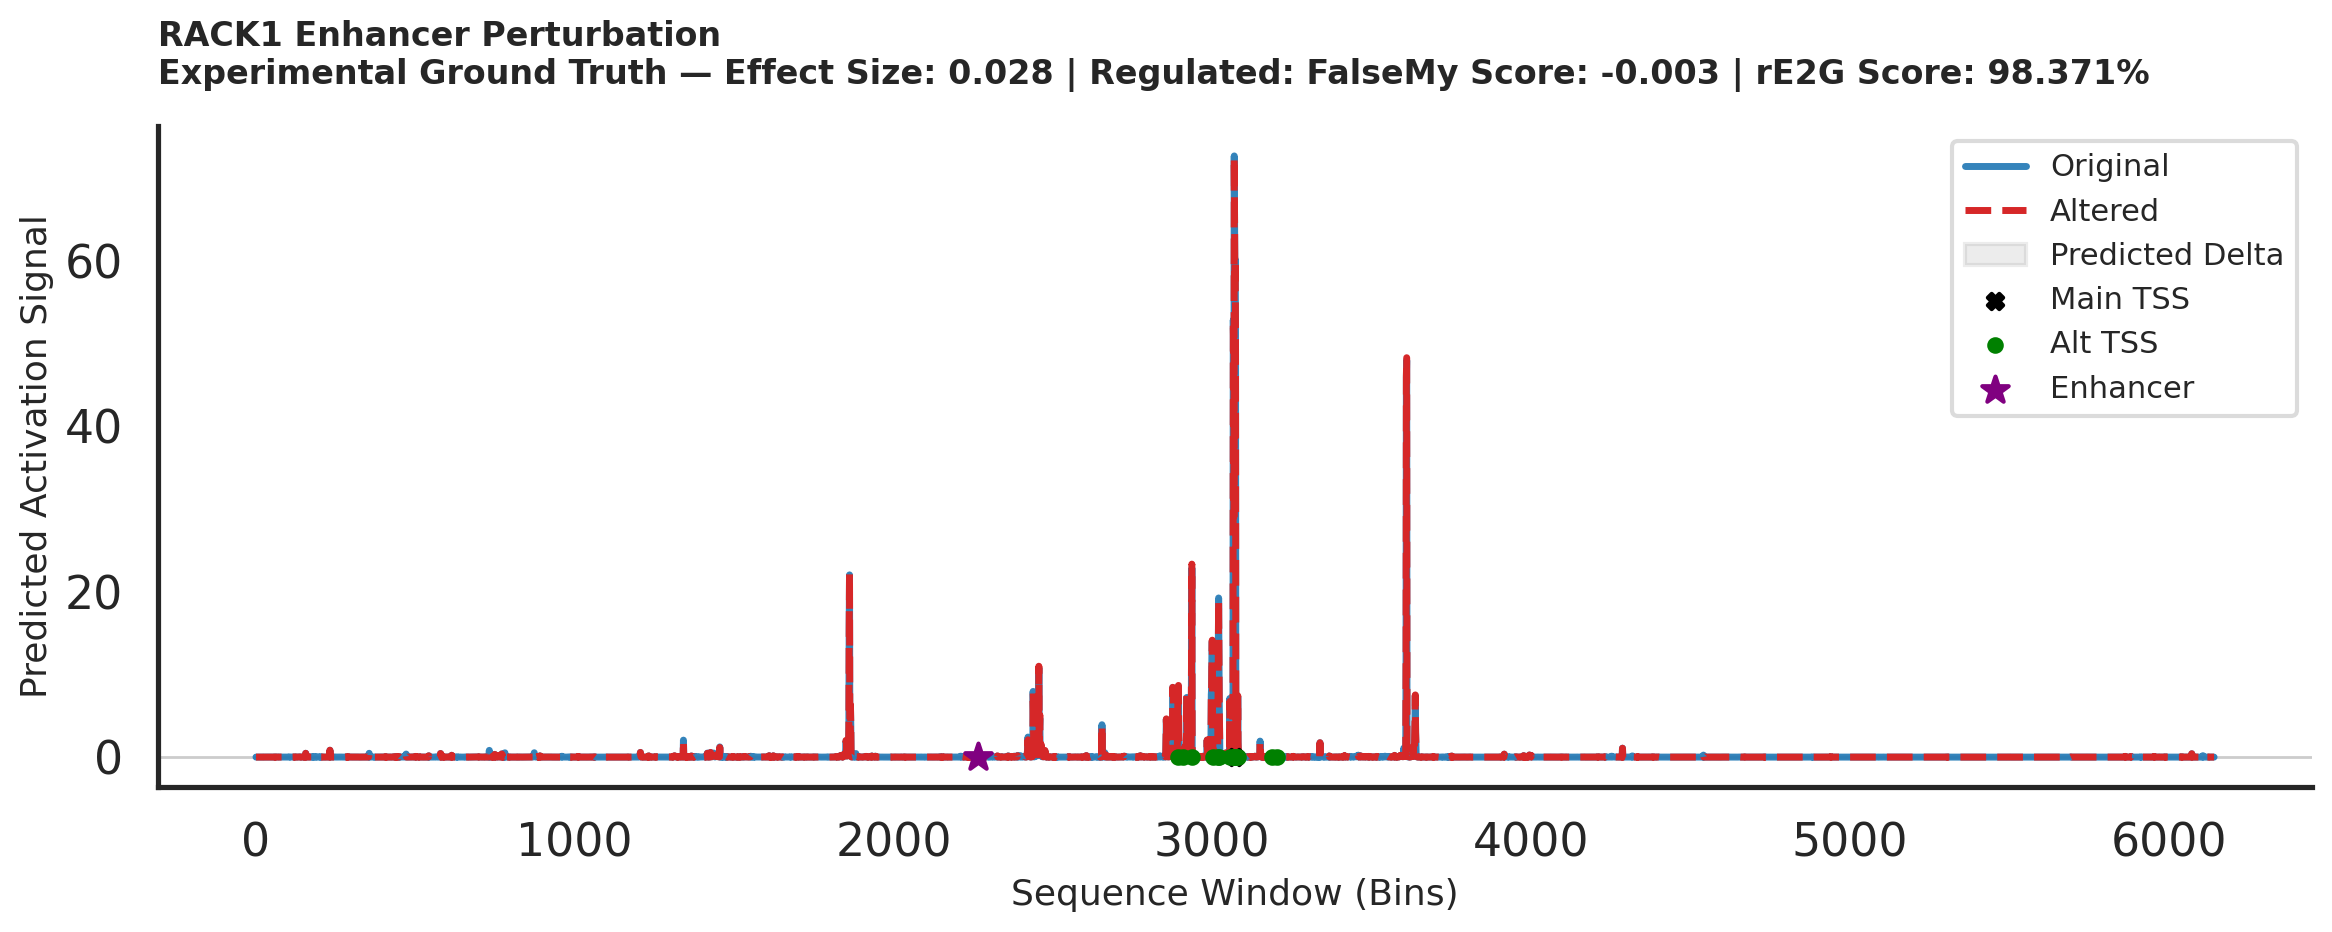

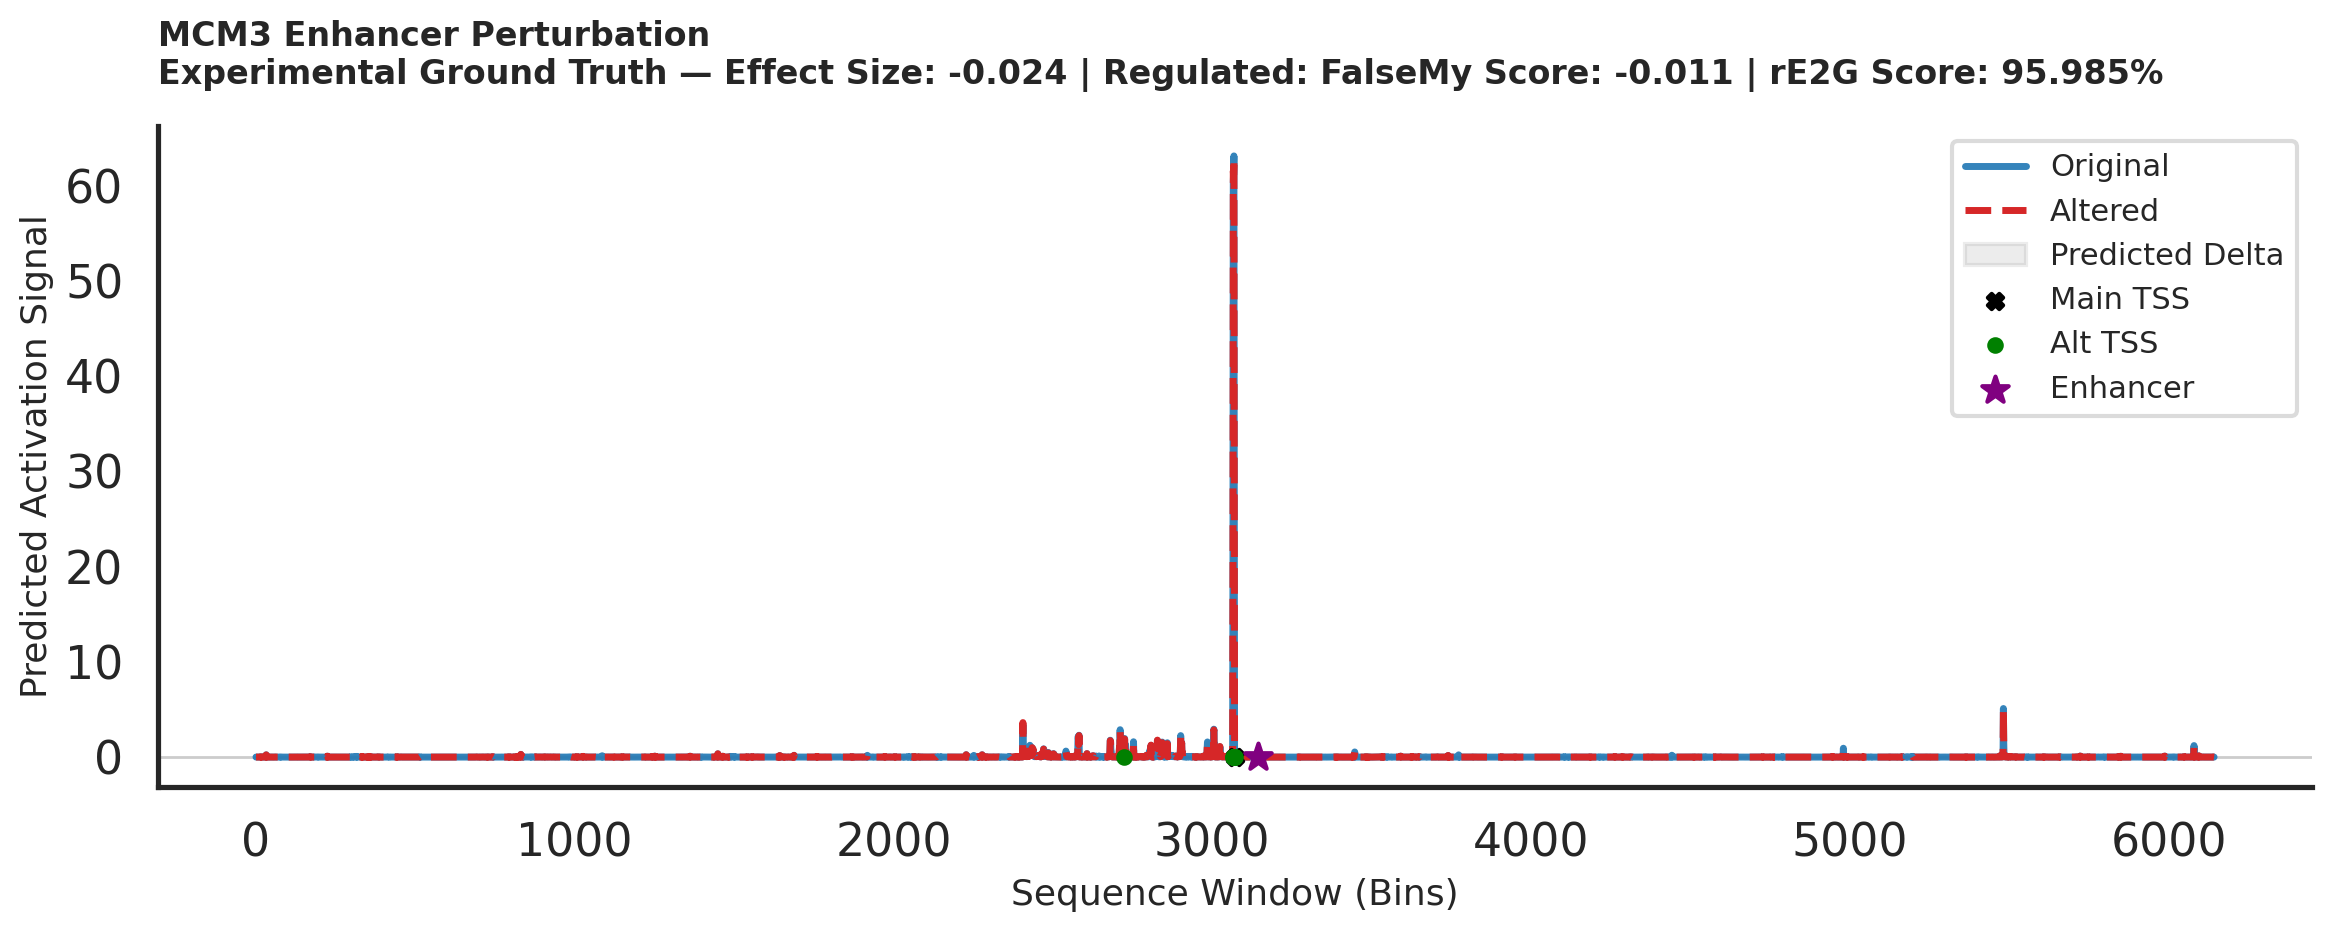

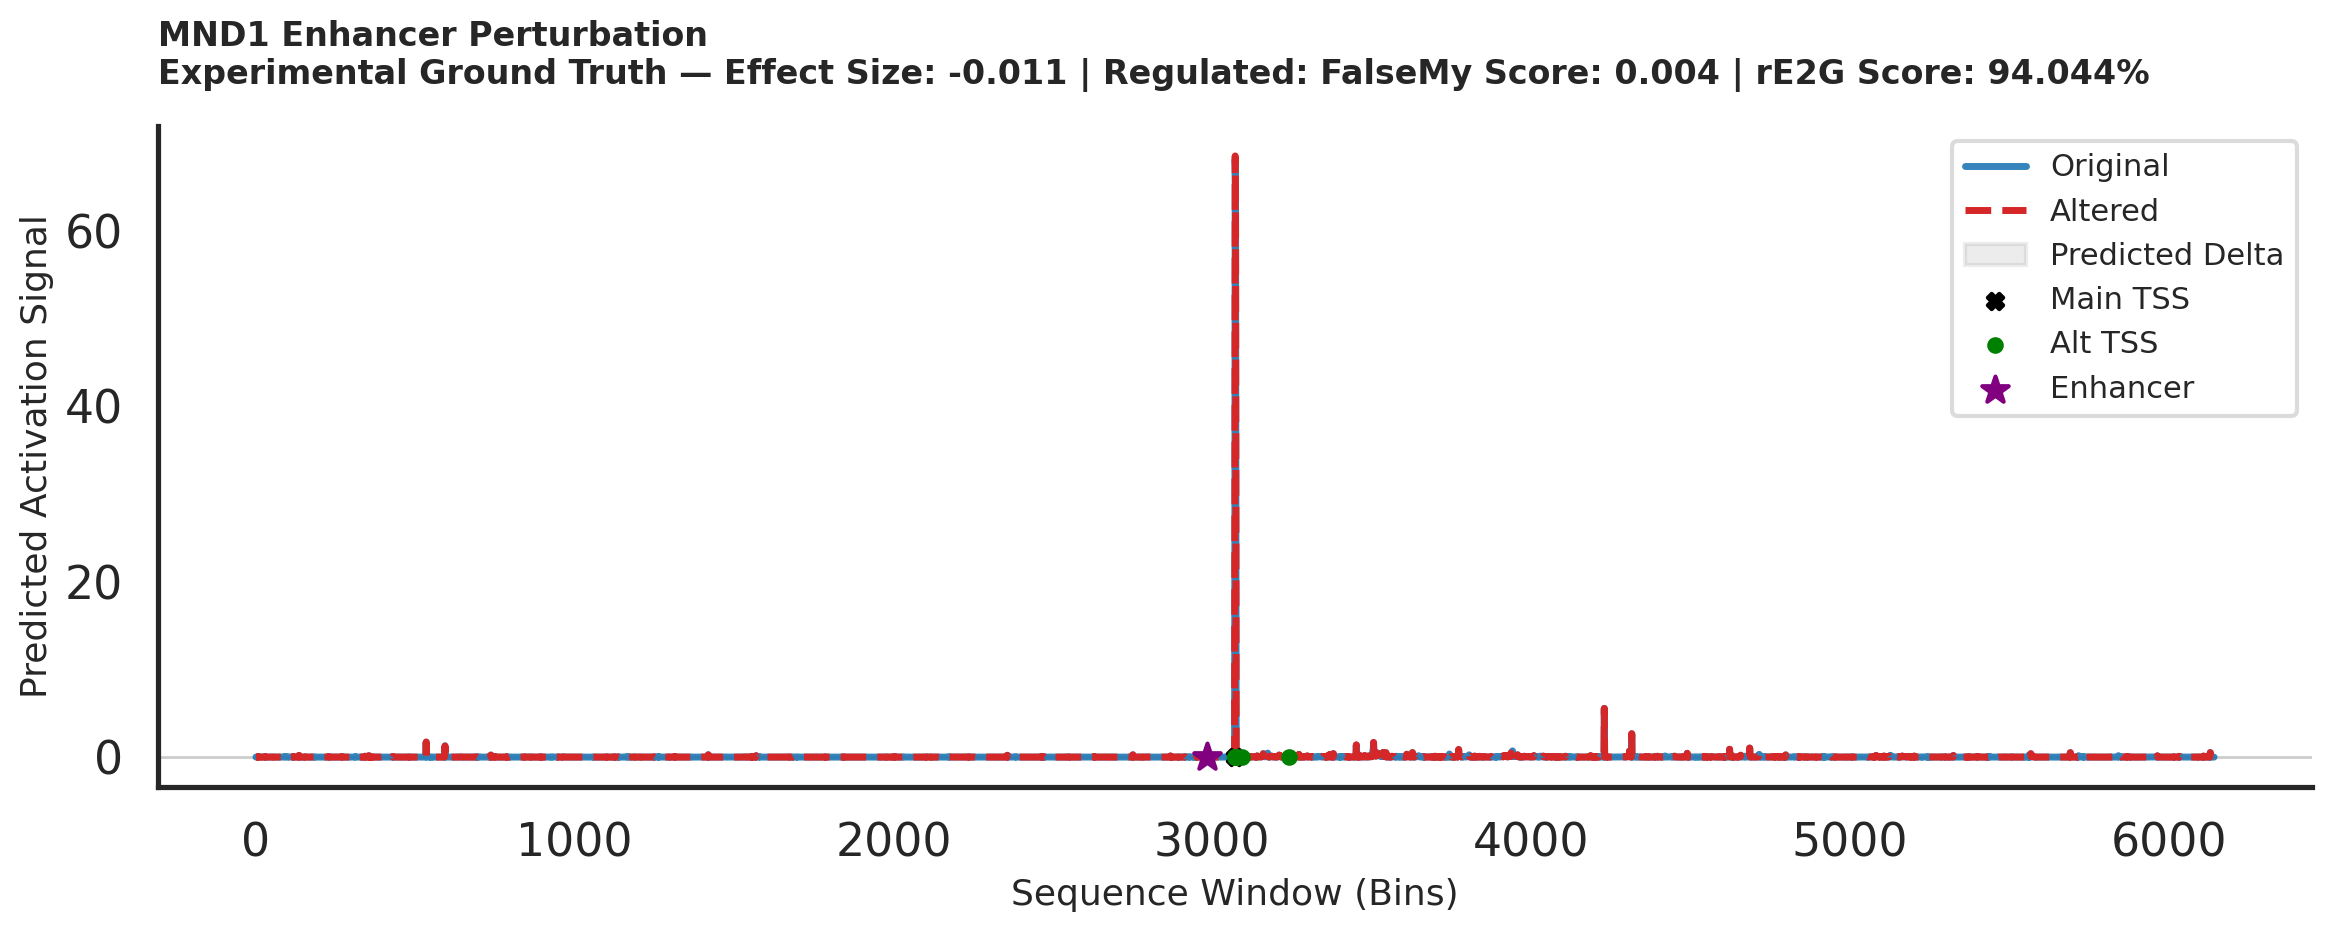

In [90]:
for idx in [7629, 8061, 7378]:
    plot_perturbation(idx, flip=False)

In [94]:
#let's check RNA outputs too

outputs_rna = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_rnaseq_tss_centered.npy')
outputs_both = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_both_tss_centered.npy')
outputs_rna.shape

(10280, 4, 6144)

In [92]:
#now let's do the plot

def plot_perturbation(idx, outputs, flip=True):
    # Extract metadata
    temp = gs_df.iloc[idx]
    tss_info = tss_dict[temp['ensg_id']]
    strand = tss_info['strand']

    # Determine indices based on strand direction
    if strand == '+':
        idx1 = 0
        idx2 = 2
    elif strand == '-':
        idx1 = 1
        idx2 = 3

    # Extract signals (Note the negative sign on alt_signal per your logic)
    orig_signal = outputs[idx, idx1, :]
    if flip:
        alt_signal = -outputs[idx, idx2, :]
    else:
        alt_signal = outputs[idx, idx2, :]
    x_axis = np.arange(len(orig_signal))

    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 5), dpi=200)

    # Plot the main signal lines
    ax.plot(x_axis, orig_signal, label='Original', color='#1f77b4', linewidth=2.5, alpha=0.9)
    ax.plot(x_axis, alt_signal, label='Altered', color='#d62728', linewidth=2.5, linestyle='--')

    # Fill the area between them to highlight the perturbation "Delta"
    ax.fill_between(x_axis, orig_signal, alt_signal, color='grey', alpha=0.15, label='Predicted Delta')

    # Add a faint baseline at y=0 so the TSS markers have a track to sit on
    ax.axhline(0, color='black', linewidth=1, alpha=0.2, zorder=1)

    # Plot TSS locations
    center_bin = len(orig_signal) // 2
    TSS_loc = tss_info['tss']

    # Plot Main TSS
    ax.scatter(center_bin, 0, marker='X', color='black', s=30, zorder=5, label='Main TSS')

    # Plot Alt TSS if it exists
    if len(tss_info['alt_tss']) > 0:
        alt_tss_locs = np.zeros(len(tss_info['alt_tss']))
        for i in range(len(tss_info['alt_tss'])):
            alt_TSS_loc = tss_info['alt_tss'][i]
            
            # Calculate offset (using 32 based on your math, update if it should be 100)
            bin_resolution = 32 
            alt_TSS_bin = center_bin + ((alt_TSS_loc - TSS_loc) // bin_resolution)
            alt_tss_locs[i] = alt_TSS_bin
    
        ax.scatter(alt_tss_locs, np.zeros_like(alt_tss_locs), marker='o', color='green', s=20, zorder=5, label='Alt TSS')
        
    #let's also put a point indication for the enhancer
    
    enhancer_loc = (temp['chromStart'] + temp['chromEnd']) // 2 #just take the middle of the enhancer for now
    enhancer_bin = center_bin + ((enhancer_loc - TSS_loc) // bin_resolution)
    ax.scatter(enhancer_bin, 0, marker='*', color='purple', s=100, zorder=5, label='Enhancer')
    
    # Format the Title hierarchically
    # 6. Format the Title hierarchically
    title_text = f"{temp['measuredGeneSymbol']} Enhancer Perturbation\n"
    subtitle_text = f"Experimental Ground Truth — Effect Size: {temp['EffectSize']:.3f} | Regulated: {temp['Regulated']}"
    scores = f"My Score: {score_vector[idx]:.3f} | rE2G Score: {100*e2g_score_vector[idx]:.3f}%"
    ax.set_title(title_text + subtitle_text + scores, fontsize=12, fontweight='bold', loc='left', pad=15)

    # 7. Clean up the axes and borders
    ax.set_xlabel("Sequence Window (Bins)", fontsize=13, fontweight='medium')
    ax.set_ylabel("Predicted Activation Signal", fontsize=13, fontweight='medium')
    sns.despine(ax=ax)

    # 8. Style the legend
    # bbox_to_anchor pulls it slightly outside the plot if you have a lot of labels
    ax.legend(frameon=True, edgecolor='lightgrey', fontsize=11)

    # Ensure perfect spacing
    plt.tight_layout()
    plt.show()

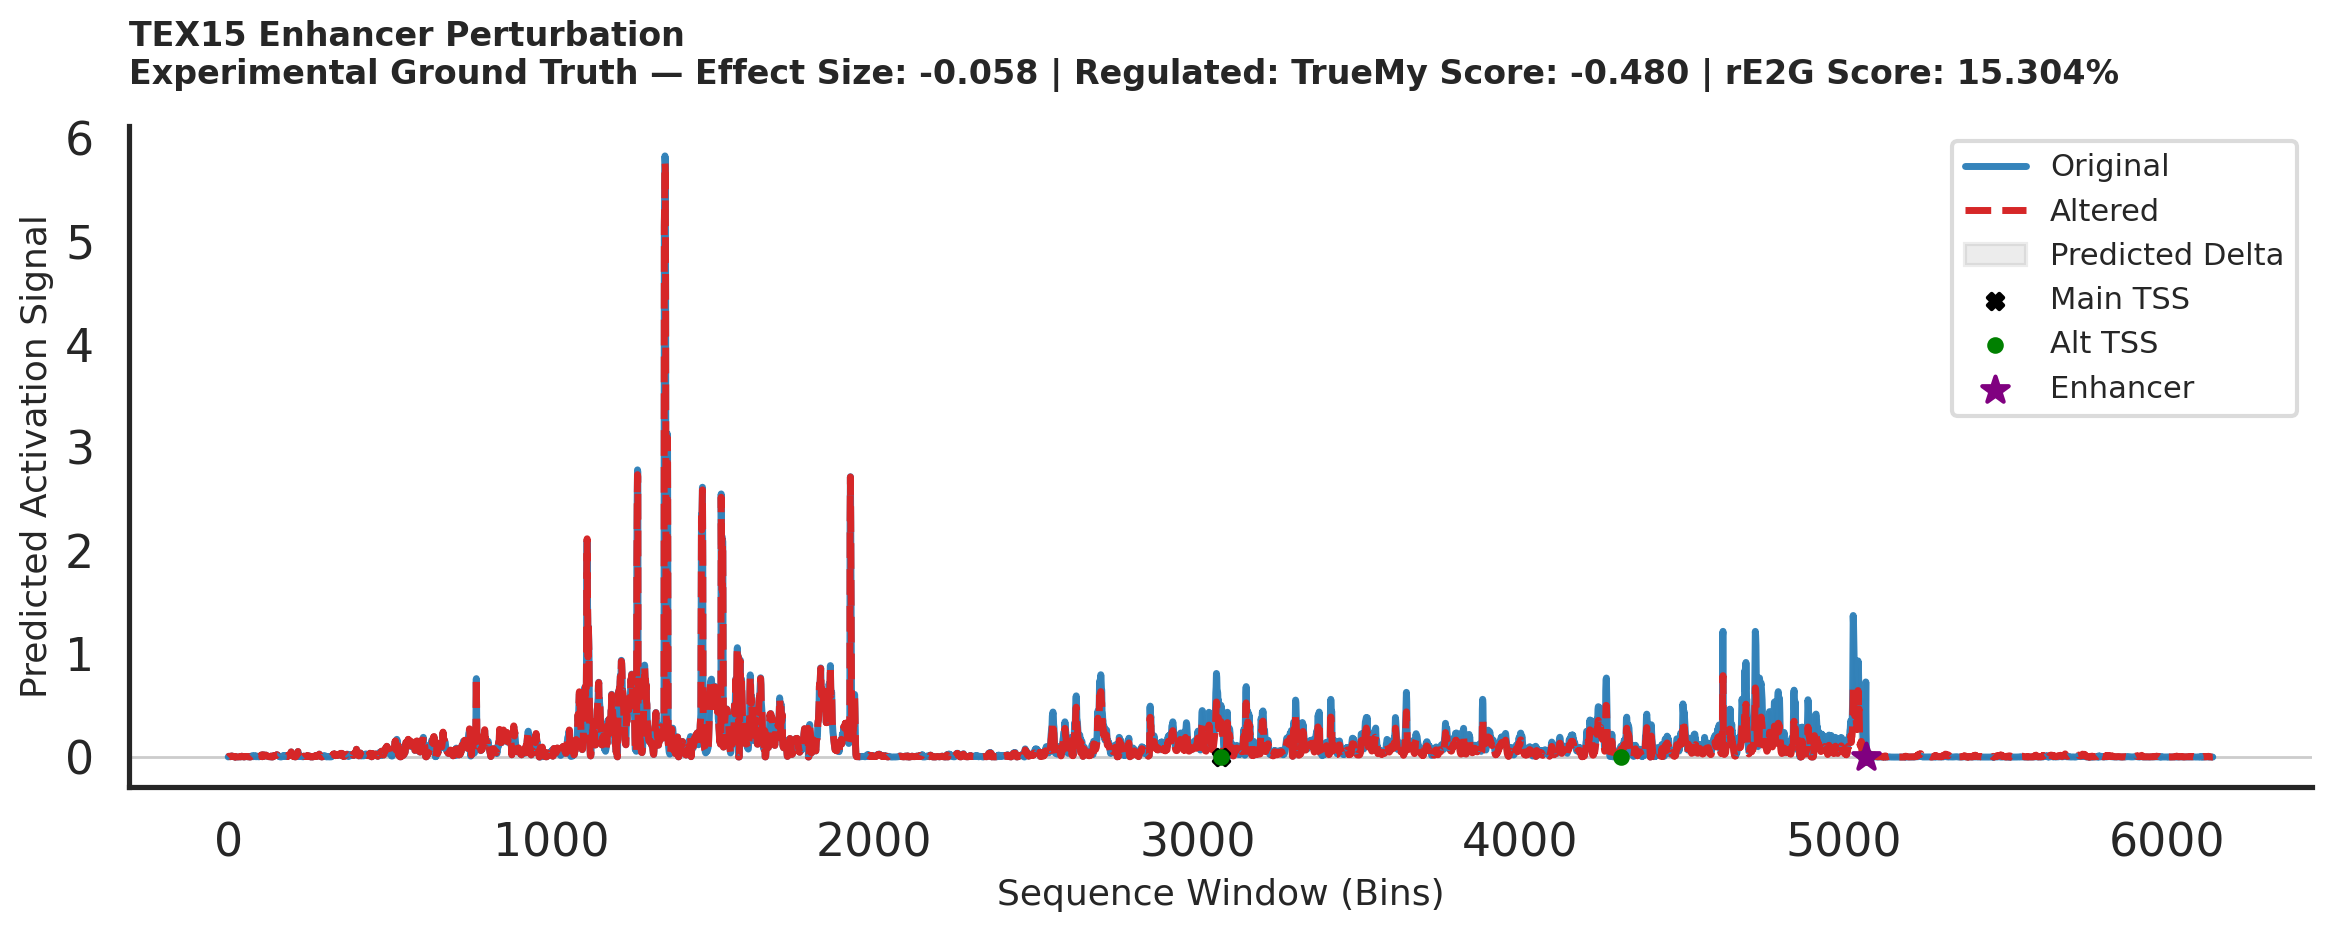

In [96]:
plot_perturbation(8438, outputs_rna, flip=False)

# let's rerun this analyses with the RNA dict

In [97]:
import pandas as pd

path = "/data1/lesliec/sarthak/data/joint_playground/e2g/ENCODE-rE2G_extended_CrossValidated_K562_EPCrisprBenchmark_ensemble_data_GRCh38.predictions.tsv.gz"
df = pd.read_csv(path, sep='\t')

#let's load my gold standard df
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)

name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)

df['master'] = df['chr'] + ":" + df['start'].astype(str) + "-" + df['end'].astype(str) + "_" + df['TargetGene']
gs_df['master'] = gs_df['chrom'] + ":" + gs_df['chromStart'].astype(str) + "-" + gs_df['chromEnd'].astype(str) + "_" + gs_df['measuredGeneSymbol']
#now subset df to gs_df values
# subset_df = df[df['master'].isin(gs_df['master'])].reset_index(drop=True)
subset_df = gs_df[['master']].merge(df, on='master', how='inner')

#now let's get my score vector
import numpy as np
outputs_rna = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_rnaseq_tss_centered.npy')
in_context = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_stranded_borzoi_cage_tss_centered_in_context.npy')
print(outputs_rna.shape, in_context.shape)

(10280, 4, 6144) (10280,)


In [98]:
#now let's load in the gtf

import re

gtf_path = "/data1/lesliec/sarthak/data/DE_danwei/gencode.v49.annotation.gtf"

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chrom", "source", "feature",
        "start", "end", "score",
        "strand", "frame", "attribute"
    ],
)

def get_attr(attr_str, key):
    m = re.search(fr'{key} "([^"]+)"', attr_str)
    return m.group(1) if m else None

for key in ["gene_id", "transcript_id", "gene_type", "gene_name", "transcript_type"]:
    gtf[key] = gtf["attribute"].apply(lambda s, k=key: get_attr(s, k))

gtf

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_id,transcript_id,gene_type,gene_name,transcript_type
0,chr1,HAVANA,gene,11121,24894,.,+,.,"gene_id ""ENSG00000290825.2""; gene_type ""lncRNA...",ENSG00000290825.2,None,lncRNA,DDX11L16,None
1,chr1,HAVANA,transcript,11121,14413,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN...",ENSG00000290825.2,ENST00000832824.1,lncRNA,DDX11L16,lncRNA
2,chr1,HAVANA,exon,11121,11211,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN...",ENSG00000290825.2,ENST00000832824.1,lncRNA,DDX11L16,lncRNA
3,chr1,HAVANA,exon,12010,12227,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN...",ENSG00000290825.2,ENST00000832824.1,lncRNA,DDX11L16,lncRNA
4,chr1,HAVANA,exon,12613,12721,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN...",ENSG00000290825.2,ENST00000832824.1,lncRNA,DDX11L16,lncRNA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7750149,chrM,ENSEMBL,transcript,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN...",ENSG00000210195.2,ENST00000387460.2,Mt_tRNA,MT-TT,Mt_tRNA
7750150,chrM,ENSEMBL,exon,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN...",ENSG00000210195.2,ENST00000387460.2,Mt_tRNA,MT-TT,Mt_tRNA
7750151,chrM,ENSEMBL,gene,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; gene_type ""Mt_tRN...",ENSG00000210196.2,None,Mt_tRNA,MT-TP,None
7750152,chrM,ENSEMBL,transcript,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; transcript_id ""EN...",ENSG00000210196.2,ENST00000387461.2,Mt_tRNA,MT-TP,Mt_tRNA


In [99]:
gtf['gene_id_noversion'] = gtf['gene_id'].str.split('.').str[0]
gene_to_idxs = gtf.groupby('gene_id_noversion').apply(lambda df: df.index.tolist()).to_dict()

In [100]:
def make_score_vector(outputs, in_context, mask_len_maintss=100, mask_len_alttss=100, pseudo_count=1e-2,
                      assay_type='CAGE', model_type='enformer', gtf=None, gene_to_idxs=None):
    # outputs.shape[1] == 4  → model has 2 output channels (before+, before-, after+, after-)
    # outputs.shape[1] == 8  → model has 4 output channels / 'both' (CAGE+,CAGE-,RNA+,RNA- × before/after)

    score_vector = np.zeros(len(gs_df))
    if model_type == 'enformer':
        size = 896
        assert outputs.shape[2] == size, f"Expected outputs to have size {size} in last dimension, got {outputs.shape[2]}"
        bin_size = 128
    elif model_type == 'borzoi':
        size = 6144
        assert outputs.shape[2] == size, f"Expected outputs to have size {size} in last dimension, got {outputs.shape[2]}"
        bin_size = 32

    n_channels = outputs.shape[1]  # 4 or 8

    for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']

        gene_location = size // 2
        tempout = outputs[i]  # (n_channels, size)

        # --- Determine og_idx / alt_idx ---
        if model_type == 'enformer':
            og_idx = 0
            alt_idx = 1
        elif n_channels == 8:
            # 4-channel 'both' model: CAGE+/CAGE-/RNA+/RNA- × before/after
            # before: 0,1,2,3  |  after: 4,5,6,7
            if assay_type == 'RNA':
                og_idx  = 2 if strand == '+' else 3
                alt_idx = 6 if strand == '+' else 7
            else:  # CAGE
                og_idx  = 0 if strand == '+' else 1
                alt_idx = 4 if strand == '+' else 5
        else:
            # 2-channel model: before+/before-/after+/after-  (n_channels == 4)
            og_idx  = 0 if strand == '+' else 1
            alt_idx = 2 if strand == '+' else 3

        # --- Build mask ---
        if assay_type == 'RNA':
            # Sum over exon bins rather than TSS window
            if gtf is None or gene_to_idxs is None:
                raise ValueError("gtf and gene_to_idxs are required for assay_type='RNA'")

            gene_rows = gtf.iloc[gene_to_idxs[ensgid]]
            exons = gene_rows[gene_rows['feature'] == 'exon']

            mask = np.zeros(size)
            for _, exon in exons.iterrows():
                # GTF coords are 1-based closed; convert to bin indices relative to TSS center
                exon_start_bin = ((exon['start'] - 1 - temp_tss) // bin_size) + gene_location
                exon_end_bin   = ((exon['end']  - temp_tss) // bin_size) + gene_location
                exon_start_bin = max(0, exon_start_bin)
                exon_end_bin   = min(size, exon_end_bin)
                if exon_start_bin < exon_end_bin:
                    mask[exon_start_bin:exon_end_bin] = 1
        else:
            # CAGE: mask around main TSS and alt TSSs
            mask = np.zeros(size)
            startmask = max(0, gene_location - mask_len_maintss)
            endmask   = min(size, gene_location + mask_len_maintss + 1)
            mask[startmask:endmask] = 1

            alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
            if mask_len_alttss > 0:
                for alt in alt_tss:
                    alt_location = int(size // 2 + alt // bin_size)
                    if alt_location < 0 or alt_location >= size:
                        continue
                    alt_startmask = max(0, alt_location - mask_len_alttss)
                    alt_endmask   = min(size, alt_location + mask_len_alttss + 1)
                    mask[alt_startmask:alt_endmask] = 1

        original_sum = (tempout[og_idx] * mask).sum()
        altered_sum  = (tempout[alt_idx] * mask).sum()

        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

    return score_vector



#now let's get a score vector
score_vector = make_score_vector(outputs, in_context, assay_type='RNA', model_type='borzoi', gtf=gtf, gene_to_idxs=gene_to_idxs)

100%|██████████| 10280/10280 [00:32<00:00, 318.17it/s]


In [101]:
#let's look at the best examples again.

#let's compare score directly

#let's fix it with class weights

#I think we need to do abs?

import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Invert the score so higher = stronger enhancer
df = pd.DataFrame({
    'my_score': np.abs(score_vector * -1), 
    'my_score_raw': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, 
    'enhancer': gs_df['master'].values,          
    'distance': distance_vector
})

# Filter to only ones in context
df = df[in_context] 

# ---------------------------------------------------------
# PLATT SCALING (Probabilities)
# ---------------------------------------------------------
X = df['my_score'].values.reshape(-1, 1)

# Fit a logistic regression using the binary CRISPR labels
lr = LogisticRegression(class_weight='balanced')  # This will automatically adjust weights inversely proportional to class frequencies
lr.fit(X, df['regulated'].to_numpy().astype(int))

# Extract the predicted probabilities for class 1 (Regulated = True)
df['my_calibrated_prob'] = lr.predict_proba(X)[:, 1]

# Calculate Probability Delta (Positive = Your model is more confident)
df['prob_delta'] = df['my_calibrated_prob'] - df['e2g_score']

# ---------------------------------------------------------
# RANK PERCENTILES
# ---------------------------------------------------------
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# Calculate Percentile Delta
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

#score delta
df['score_delta'] = df['my_score'] - df['e2g_score']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
true_enhancers = df[df['regulated'] == 1].copy()

# Sorting by percentile advantage (You could also sort by 'prob_delta' here!)
my_best_true_positives = true_enhancers.sort_values('score_delta', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives.head(10))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
non_enhancers = df[df['regulated'] == 0].copy()

# Sorting ascending so the most negative deltas (rE2G loved it, you ignored it) are at the top
my_best_true_negatives = non_enhancers.sort_values('score_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives.head(10))

Top 5 True Enhancers my model found but rE2G missed:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
8438,1.779036,-1.779036,0.153041,True,-0.057820,TEX15,chr8:30912766-30913266_TEX15,22410.5,0.999990,0.846949,1.000000,0.833418,0.166582,1.625995
8437,0.942102,-0.942102,0.156457,True,-0.071070,TEX15,chr8:30911759-30912634_TEX15,21591.0,0.997735,0.841278,0.999747,0.835949,0.163797,0.785645
9,0.010820,-0.010820,0.008112,True,-0.107409,ENO1,chr1:8858063-8858563_ENO1,20774.0,0.505766,0.497654,0.955190,0.459241,0.495949,0.002709
6181,0.000291,0.000291,0.000058,True,-0.099898,ATP5G3,chr2:175036530-175037030_ATP5G3,145039.0,0.488625,0.488567,0.396962,0.000759,0.396203,0.000233
592,0.000288,-0.000288,0.001027,True,-0.049928,PEX19,chr1:160460641-160461141_PEX19,175734.0,0.488621,0.487594,0.394684,0.139747,0.254937,-0.000739
5973,0.000347,0.000347,0.002744,True,-0.103472,SRSF7,chr2:38613065-38614248_SRSF7,137454.0,0.488716,0.485972,0.438481,0.279747,0.158734,-0.002397
6984,0.000439,0.000439,0.003145,True,-0.066006,RPN1,chr3:128426282-128426962_RPN1,224196.0,0.488866,0.485721,0.486835,0.300000,0.186835,-0.002706
1090,0.203696,-0.203696,0.211530,True,-0.377222,IFITM1,chr11:316244-316608_IFITM1,2565.0,0.782309,0.570778,0.998228,0.858481,0.139747,-0.007834
4072,0.004668,-0.004668,0.013768,True,-0.177109,DHPS,chr19:12671911-12672491_DHPS,9689.0,0.495750,0.481982,0.891392,0.538987,0.352405,-0.009100
8419,0.000156,0.000156,0.011715,True,-0.083980,NDUFB2,chr7:140507907-140508876_NDUFB2,187927.0,0.488405,0.476691,0.270886,0.516962,-0.246076,-0.011559



Top 5 False Positives my model avoided but rE2G fell for:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
7629,0.000505,-0.000505,0.983711,False,0.028193,RACK1,chr5:181217521-181218720_RACK1,26085.0,0.488974,-0.494737,0.522785,0.991139,-0.468354,-0.983206
8061,0.011628,-0.011628,0.959853,False,-0.024337,MCM3,chr6:52286764-52287606_MCM3,2303.0,0.507081,-0.452772,0.957975,0.982278,-0.024304,-0.948225
7378,0.007456,0.007456,0.940440,False,-0.011368,MND1,chr4:153341638-153342138_MND1,2757.0,0.500289,-0.440152,0.933418,0.974684,-0.041266,-0.932984
1236,0.022416,-0.022416,0.951601,False,-0.130902,CTSD,chr11:1772159-1772971_CTSD,8583.0,0.524626,-0.426975,0.979241,0.978734,0.000506,-0.929185
2981,0.010662,-0.010662,0.927626,False,-0.021777,MAX,chr14:65107151-65107651_MAX,4873.0,0.505508,-0.422118,0.954177,0.971646,-0.017468,-0.916964
7628,0.001270,0.001270,0.907183,False,0.043527,RACK1,chr5:181188256-181189202_RACK1,55040.0,0.490218,-0.416964,0.716203,0.965823,-0.249620,-0.905913
5976,0.002109,0.002109,0.902093,False,-0.049528,HNRNPLL,chr2:38643689-38644189_HNRNPLL,40918.5,0.491584,-0.410510,0.795443,0.964557,-0.169114,-0.899985
2764,0.001100,-0.001100,0.897664,False,-0.053071,ITGA5,chr12:54428661-54429181_ITGA5,9588.5,0.489942,-0.407722,0.688861,0.963291,-0.274430,-0.896564
8128,0.094573,-0.094573,0.988392,False,-0.054244,RNASET2,chr6:166959196-166959696_RNASET2,2879.5,0.638419,-0.349973,0.996709,0.993418,0.003291,-0.893819
7617,0.029706,-0.029706,0.914802,False,-0.049084,RMND5B,chr5:178127330-178127952_RMND5B,3398.0,0.536450,-0.378351,0.985063,0.968861,0.016203,-0.885096


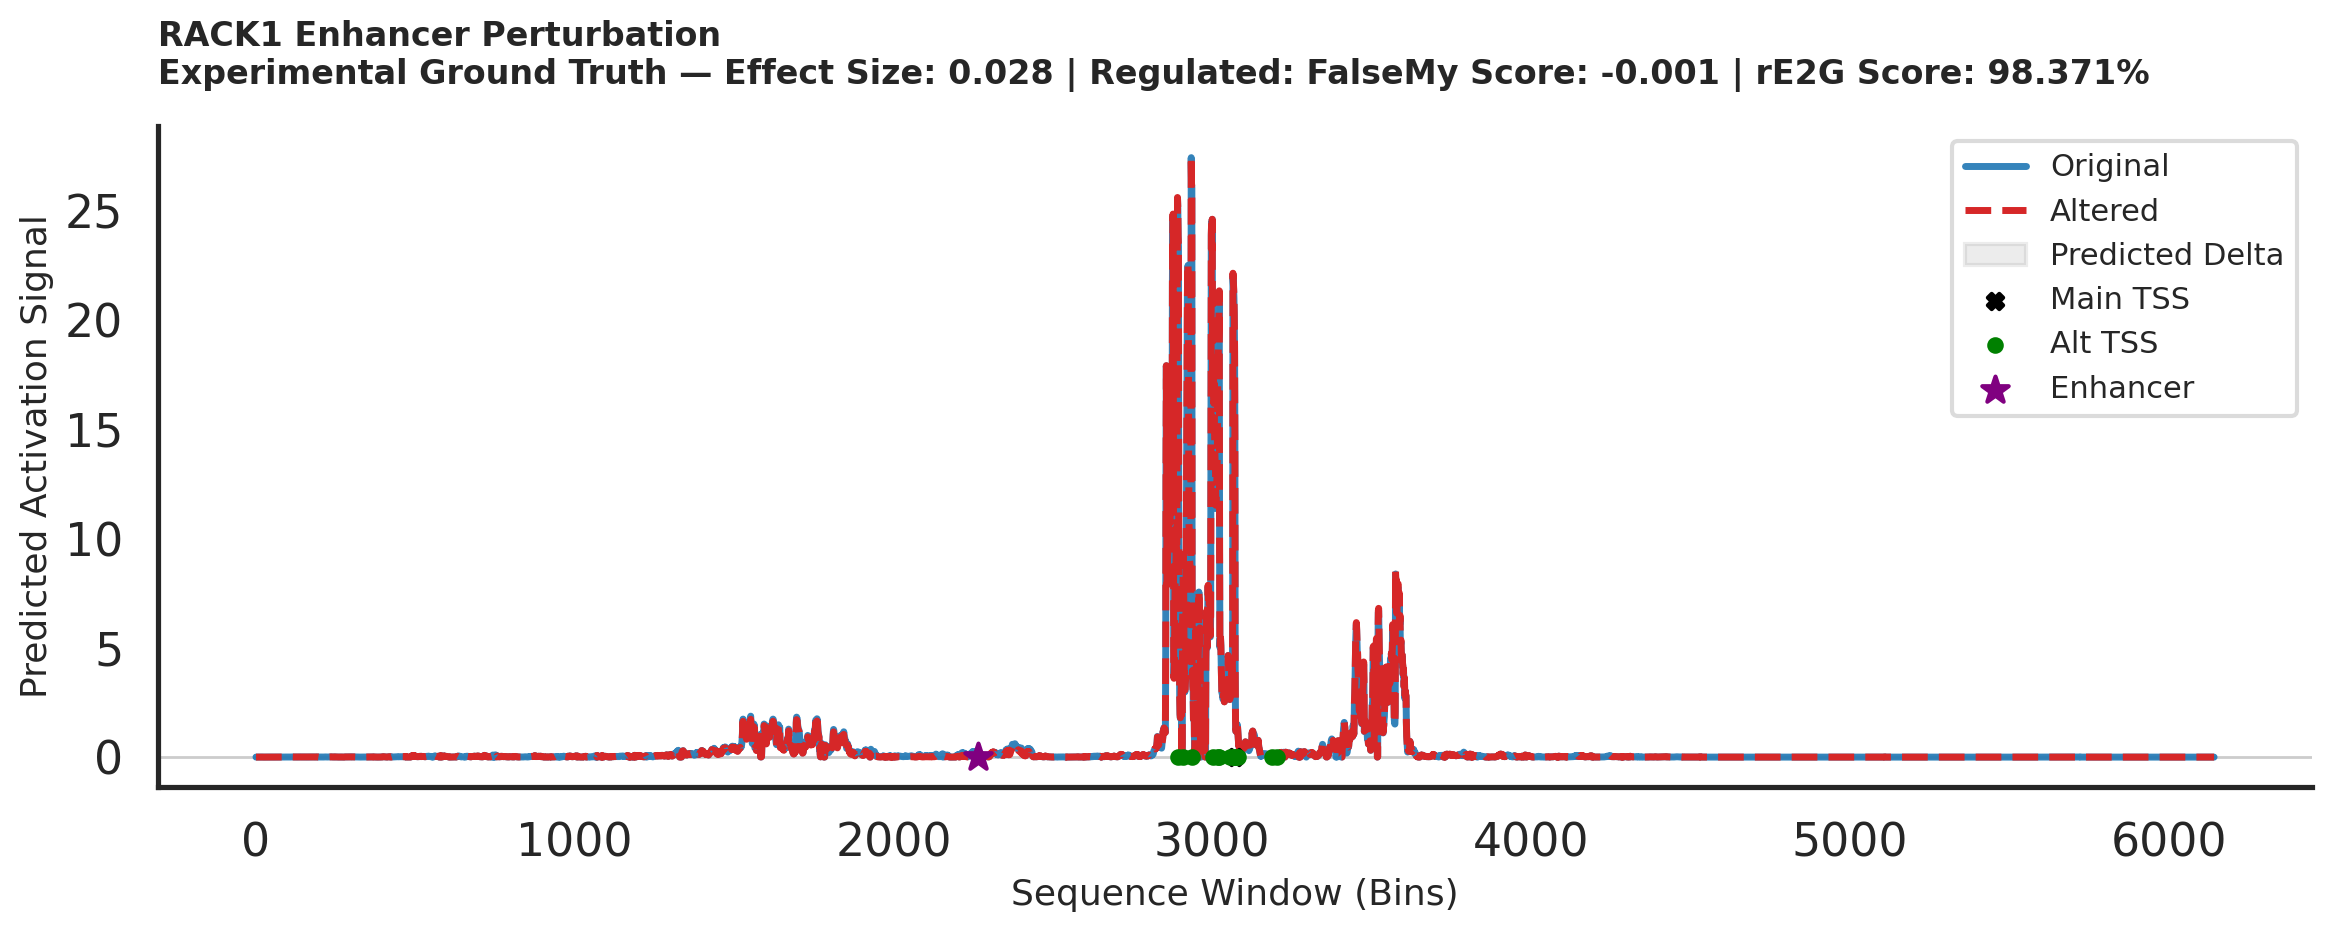

In [105]:
#let's look at idx 9
plot_perturbation(7629, outputs_rna, flip=False)

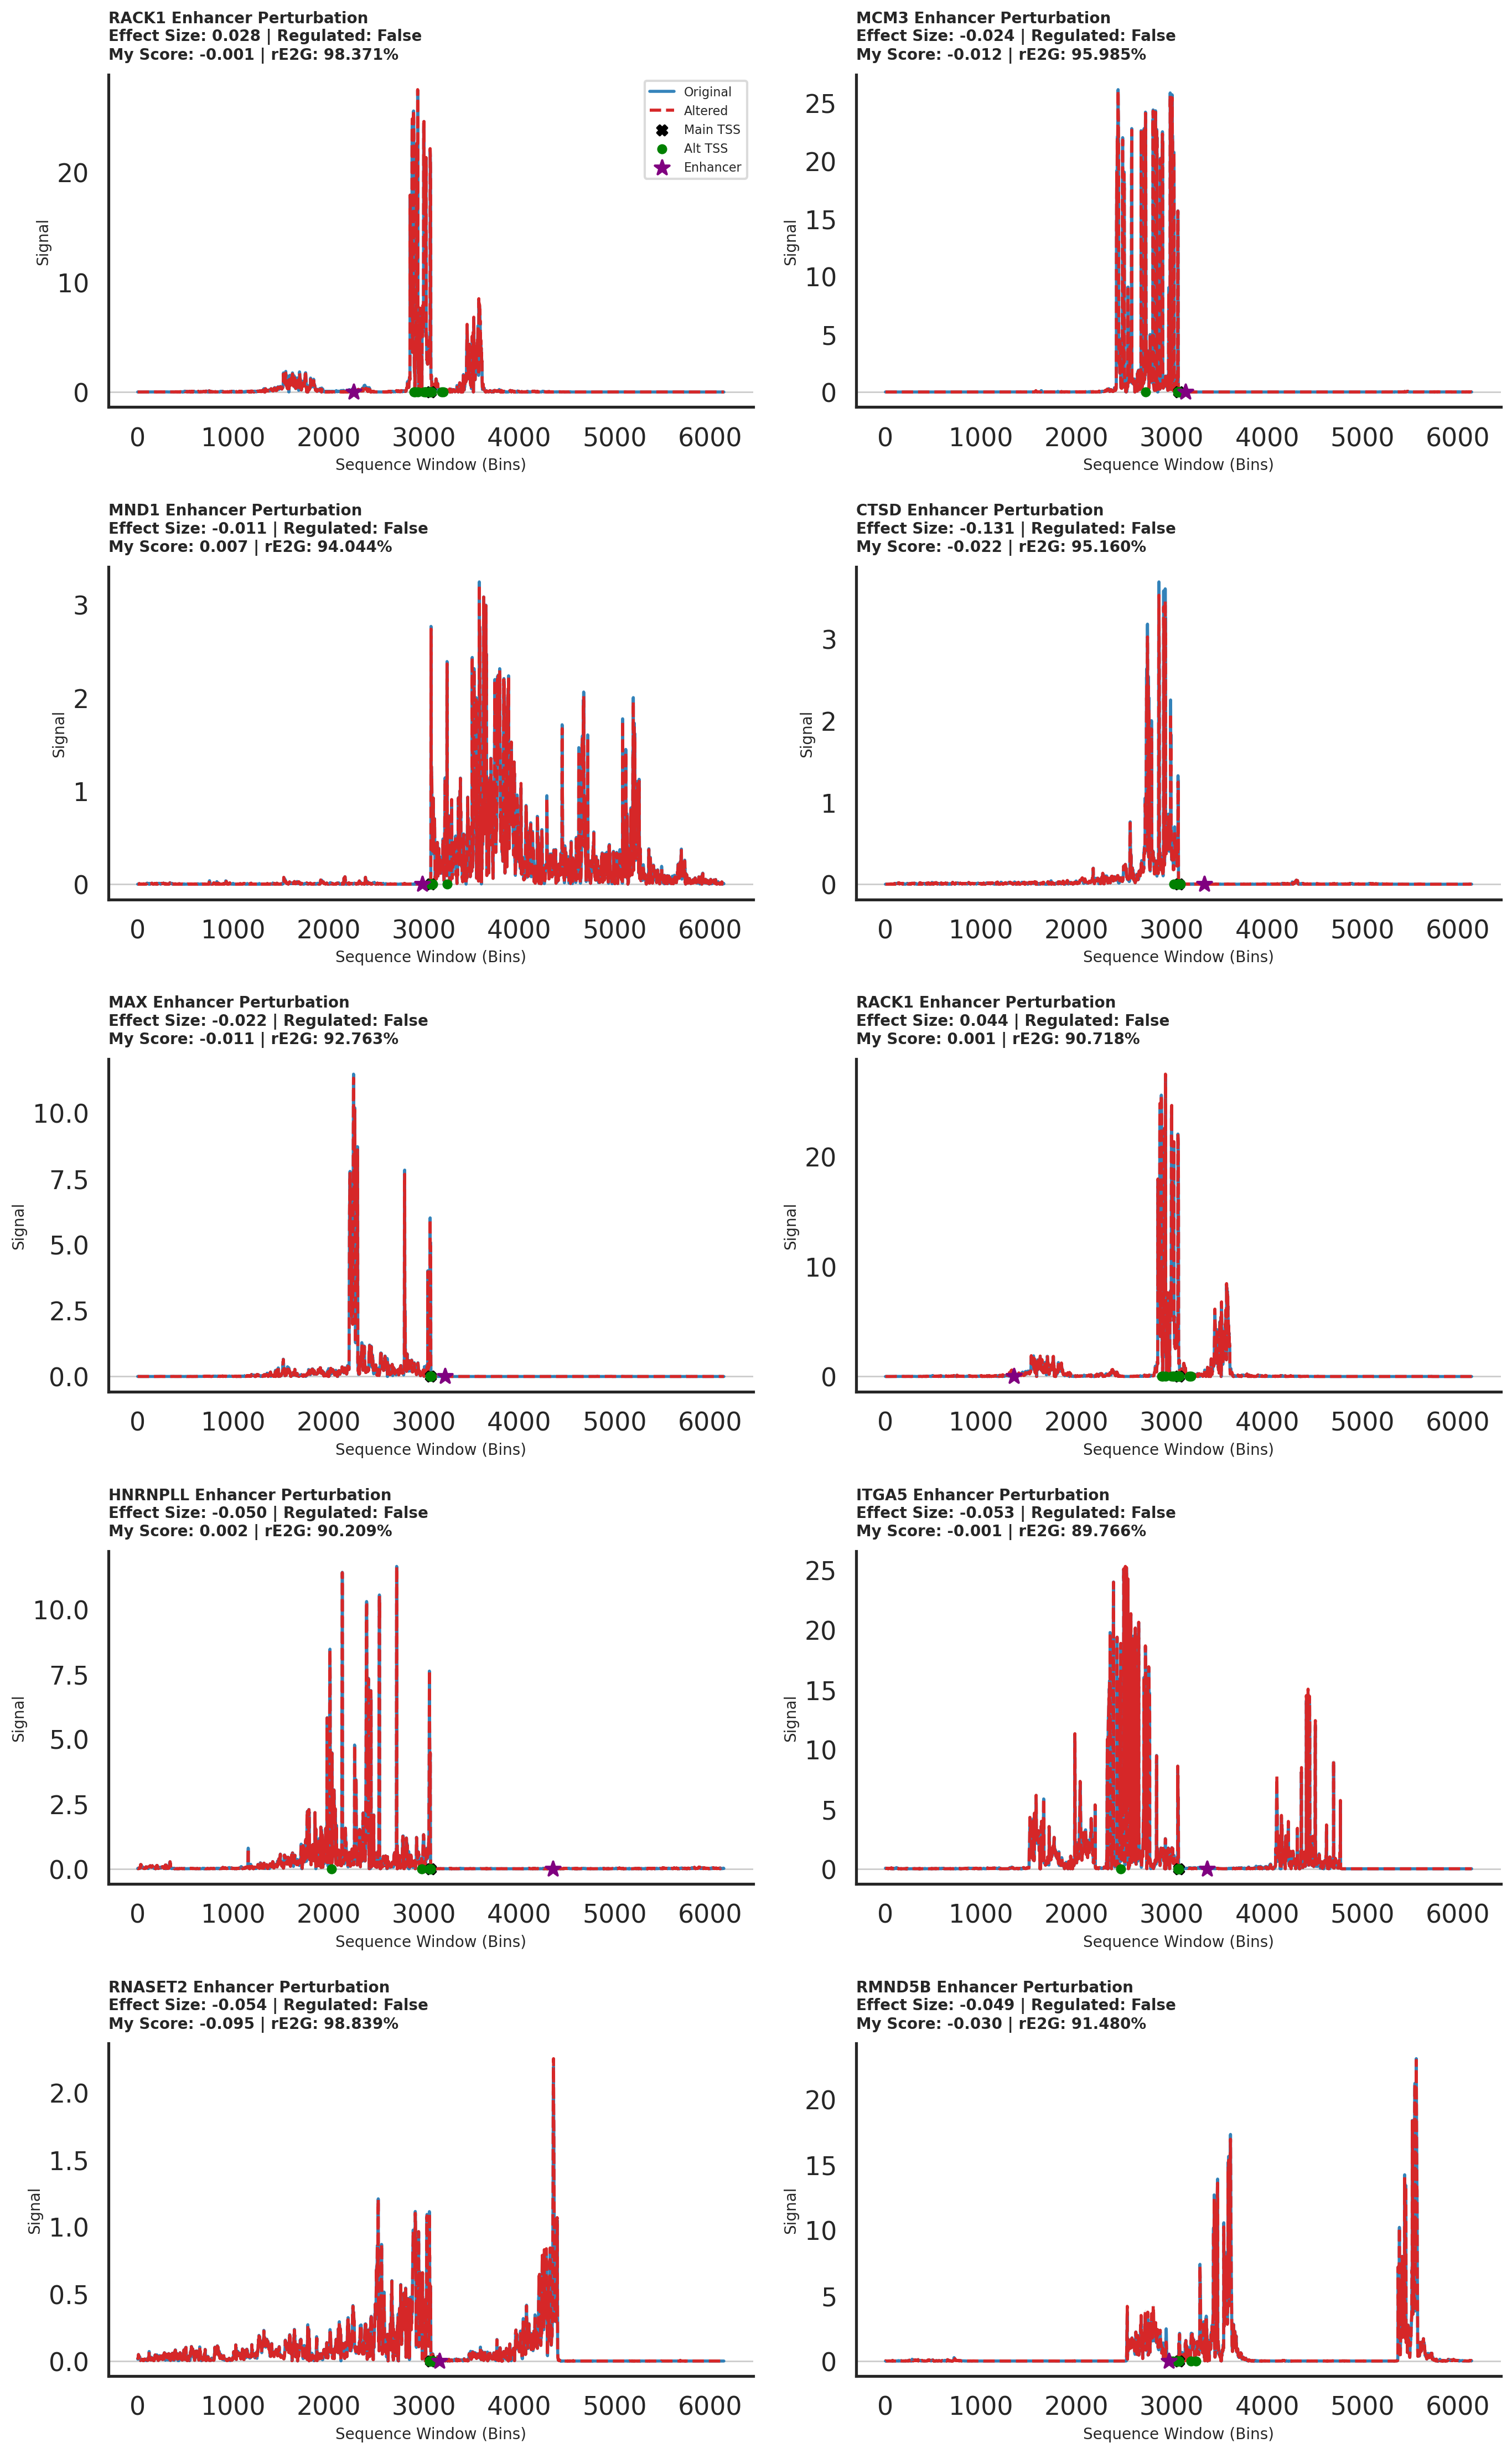

In [108]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_perturbation_grid(indices, outputs, flip=True, cols=2):
    """
    Plots a grid of perturbation subplots for a given list of indices.
    
    Args:
        indices (list): List of indices from gs_df to plot.
        outputs (ndarray): Your model's signal output array.
        flip (bool): Whether to invert the altered signal.
        cols (int): Number of columns in the grid.
    """
    # 1. Calculate grid dimensions
    n_plots = len(indices)
    rows = math.ceil(n_plots / cols)
    
    # 2. Create the figure and grid of axes
    # Dynamically scale the figure size based on the number of rows and columns
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(cols * 7, rows * 4.5), dpi=200)
    
    # Ensure axes is a flat array for easy iteration (handles the 1x1 case too)
    if n_plots == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # 3. Loop through the grid
    for i, ax in enumerate(axes):
        # If we have more grid spaces than indices, hide the empty subplots
        if i >= n_plots:
            ax.axis('off')
            continue

        idx = indices[i]

        # --- Metadata Extraction ---
        temp = gs_df.iloc[idx]
        tss_info = tss_dict[temp['ensg_id']]
        strand = tss_info['strand']

        if strand == '+':
            idx1, idx2 = 0, 2
        elif strand == '-':
            idx1, idx2 = 1, 3

        # --- Signal Extraction ---
        orig_signal = outputs[idx, idx1, :]
        if flip:
            alt_signal = -outputs[idx, idx2, :]
        else:
            alt_signal = outputs[idx, idx2, :]
            
        x_axis = np.arange(len(orig_signal))

        # --- Plotting Lines ---
        ax.plot(x_axis, orig_signal, label='Original', color='#1f77b4', linewidth=2, alpha=0.9)
        ax.plot(x_axis, alt_signal, label='Altered', color='#d62728', linewidth=2, linestyle='--')
        ax.fill_between(x_axis, orig_signal, alt_signal, color='grey', alpha=0.15)
        ax.axhline(0, color='black', linewidth=1, alpha=0.2, zorder=1)

        # --- Plotting Markers ---
        center_bin = len(orig_signal) // 2
        TSS_loc = tss_info['tss']
        bin_resolution = 32 

        # Main TSS
        ax.scatter(center_bin, 0, marker='X', color='black', s=40, zorder=5, label='Main TSS')

        # Alt TSS
        if len(tss_info['alt_tss']) > 0:
            alt_tss_locs = np.zeros(len(tss_info['alt_tss']))
            for j in range(len(tss_info['alt_tss'])):
                alt_TSS_loc = tss_info['alt_tss'][j]
                alt_TSS_bin = center_bin + ((alt_TSS_loc - TSS_loc) // bin_resolution)
                alt_tss_locs[j] = alt_TSS_bin
            
            ax.scatter(alt_tss_locs, np.zeros_like(alt_tss_locs), marker='o', color='green', s=25, zorder=5, label='Alt TSS')
            
        # Enhancer
        enhancer_loc = (temp['chromStart'] + temp['chromEnd']) // 2 
        enhancer_bin = center_bin + ((enhancer_loc - TSS_loc) // bin_resolution)
        ax.scatter(enhancer_bin, 0, marker='*', color='purple', s=100, zorder=5, label='Enhancer')
        
        # --- Formatting the Subplot ---
        # Adjusted font sizes and added newlines to fit the smaller subplot width
        title_text = f"{temp['measuredGeneSymbol']} Enhancer Perturbation\n"
        subtitle_text = f"Effect Size: {temp['EffectSize']:.3f} | Regulated: {temp['Regulated']}\n"
        scores = f"My Score: {score_vector[idx]:.3f} | rE2G: {100*e2g_score_vector[idx]:.3f}%"
        
        ax.set_title(title_text + subtitle_text + scores, fontsize=10, fontweight='bold', loc='left', pad=10)
        ax.set_xlabel("Sequence Window (Bins)", fontsize=10)
        ax.set_ylabel("Signal", fontsize=10)
        
        # To avoid massive clutter, we only draw the legend on the very first subplot
        if i == 0:
            ax.legend(frameon=True, edgecolor='lightgrey', fontsize=8, loc='best')

        sns.despine(ax=ax)

    # Automatically adjust spacing between subplots so titles don't overlap axes
    plt.tight_layout()
    plt.show()
    
#let's loop through a bunch of the negative example that we found
indices = []
for idx in my_best_true_negatives.head(10).index:
    indices.append(idx)

plot_perturbation_grid(indices, outputs_rna, flip=False, cols=2)

In [109]:
#let's redo with the CAGE vector
mask_len_maintss = 5
mask_len_alttss = 3
pseudo_count = 1e-2

score_vector = make_score_vector(outputs, in_context, mask_len_maintss, mask_len_alttss, pseudo_count, assay_type='CAGE', model_type='borzoi')

100%|██████████| 10280/10280 [00:00<00:00, 17501.53it/s]


In [119]:
#let's look at the best examples again.

#let's compare score directly

#let's fix it with class weights

#I think we need to do abs?

import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Invert the score so higher = stronger enhancer
df = pd.DataFrame({
    'my_score': np.abs(score_vector * -1), 
    'my_score_raw': score_vector,
    'e2g_score': e2g_score_vector,
    'regulated': gs_df['Regulated'].values,
    'effect_size': gs_df['EffectSize'].values,
    'gene': gs_df['measuredGeneSymbol'].values, 
    'enhancer': gs_df['master'].values,          
    'distance': distance_vector
})

# Filter to only ones in context
df = df[in_context] 

# ---------------------------------------------------------
# PLATT SCALING (Probabilities)
# ---------------------------------------------------------
X = df['my_score'].values.reshape(-1, 1)

# Fit a logistic regression using the binary CRISPR labels
lr = LogisticRegression(class_weight='balanced')  # This will automatically adjust weights inversely proportional to class frequencies
lr.fit(X, df['regulated'].to_numpy().astype(int))

# Extract the predicted probabilities for class 1 (Regulated = True)
df['my_calibrated_prob'] = lr.predict_proba(X)[:, 1]

# Calculate Probability Delta (Positive = Your model is more confident)
df['prob_delta'] = df['my_calibrated_prob'] - df['e2g_score']

# ---------------------------------------------------------
# RANK PERCENTILES
# ---------------------------------------------------------
df['my_percentile'] = df['my_score'].rank(pct=True)
df['e2g_percentile'] = df['e2g_score'].rank(pct=True)

# Calculate Percentile Delta
df['my_advantage_delta'] = df['my_percentile'] - df['e2g_percentile']

#score delta
df['score_delta'] = df['my_score'] - df['e2g_score']

# ---------------------------------------------------------
# SCENARIO A: Finding "Hidden Gems" (Your True Positives)
# ---------------------------------------------------------
true_enhancers = df[df['regulated'] == 1].copy()

# Sorting by percentile advantage (You could also sort by 'prob_delta' here!)
my_best_true_positives = true_enhancers.sort_values('my_score', ascending=False)

print("Top 5 True Enhancers my model found but rE2G missed:")
display(my_best_true_positives.head(20))


# ---------------------------------------------------------
# SCENARIO B: Finding "False Alarms" (rE2G's False Positives)
# ---------------------------------------------------------
non_enhancers = df[df['regulated'] == 0].copy()

# Sorting ascending so the most negative deltas (rE2G loved it, you ignored it) are at the top
my_best_true_negatives = non_enhancers.sort_values('prob_delta', ascending=True)

print("\nTop 5 False Positives my model avoided but rE2G fell for:")
display(my_best_true_negatives.head(20))

Top 5 True Enhancers my model found but rE2G missed:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
8438,7.741511,-7.741511,0.153041,True,-0.057820,TEX15,chr8:30912766-30913266_TEX15,22410.5,1.000000,0.846959,1.000000,0.833418,0.166582,7.588470
2232,5.406666,-5.406666,0.997397,True,-0.012145,OR2AT4,chr11:75096776-75097276_OR2AT4,7115.0,1.000000,0.002603,0.999747,0.998987,0.000759,4.409269
928,1.138655,-1.138655,0.694162,True,-0.850000,UROS,chr10:125816658-125816735_UROS,6693.0,0.999534,0.305372,0.999494,0.933671,0.065823,0.444493
8437,1.111222,-1.111222,0.156457,True,-0.071070,TEX15,chr8:30911759-30912634_TEX15,21591.0,0.999439,0.842982,0.999241,0.835949,0.163291,0.954765
1928,0.241128,-0.241128,0.340694,True,-0.011428,MS4A4A,chr11:60193546-60195055_MS4A4A,86297.5,0.830180,0.489486,0.998734,0.885570,0.113165,-0.099566
1090,0.204023,-0.204023,0.211530,True,-0.377222,IFITM1,chr11:316244-316608_IFITM1,2565.0,0.791723,0.580193,0.998481,0.858481,0.140000,-0.007507
3,0.140421,-0.140421,0.990204,True,-0.472019,SMIM1,chr1:3774714-3775214_SMIM1,2524.0,0.711799,-0.278405,0.997975,0.994430,0.003544,-0.849783
6220,0.121932,-0.121932,0.947429,True,-0.074120,UBE2F,chr2:237963667-237964594_UBE2F,2585.0,0.685418,-0.262012,0.997722,0.977975,0.019747,-0.825498
9232,0.111435,-0.111435,0.985475,True,-0.416600,ANXA1,chr9:73148376-73149938_ANXA1,2036.0,0.669875,-0.315600,0.997215,0.991899,0.005316,-0.874040
6434,0.092355,-0.092355,0.998240,True,-0.012758,NPTXR,chr22:38846894-38847394_NPTXR,3058.5,0.640667,-0.357573,0.996203,1.000000,-0.003797,-0.905885



Top 5 False Positives my model avoided but rE2G fell for:


,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
7629,0.000012,0.000012,0.983711,False,0.028193,RACK1,chr5:181217521-181218720_RACK1,26085.0,0.488053,-0.495659,0.049114,0.991139,-0.942025,-0.983699
8061,0.010716,-0.010716,0.959853,False,-0.024337,MCM3,chr6:52286764-52287606_MCM3,2303.0,0.506191,-0.453662,0.957975,0.982278,-0.024304,-0.949138
7378,0.003803,0.003803,0.940440,False,-0.011368,MND1,chr4:153341638-153342138_MND1,2757.0,0.494476,-0.445964,0.904810,0.974684,-0.069873,-0.936637
7628,0.001033,0.001033,0.907183,False,0.043527,RACK1,chr5:181188256-181189202_RACK1,55040.0,0.489781,-0.417402,0.745316,0.965823,-0.220506,-0.906150
2981,0.014697,-0.014697,0.927626,False,-0.021777,MAX,chr14:65107151-65107651_MAX,4873.0,0.512937,-0.414689,0.966582,0.971646,-0.005063,-0.912929
1236,0.029230,-0.029230,0.951601,False,-0.130902,CTSD,chr11:1772159-1772971_CTSD,8583.0,0.537502,-0.414099,0.984304,0.978734,0.005570,-0.922371
5976,0.001918,0.001918,0.902093,False,-0.049528,HNRNPLL,chr2:38643689-38644189_HNRNPLL,40918.5,0.491281,-0.410812,0.827342,0.964557,-0.137215,-0.900175
2764,0.004127,-0.004127,0.897664,False,-0.053071,ITGA5,chr12:54428661-54429181_ITGA5,9588.5,0.495024,-0.402640,0.909873,0.963291,-0.053418,-0.893537
920,0.003508,-0.003508,0.887548,False,-0.045393,SCD,chr10:100370530-100371657_SCD,24074.0,0.493976,-0.393572,0.897975,0.961519,-0.063544,-0.884040
1498,0.002051,0.002051,0.867611,False,0.000887,HBE1,chr11:5258555-5259055_HBE1,11369.0,0.491507,-0.376104,0.838228,0.957722,-0.119494,-0.865560


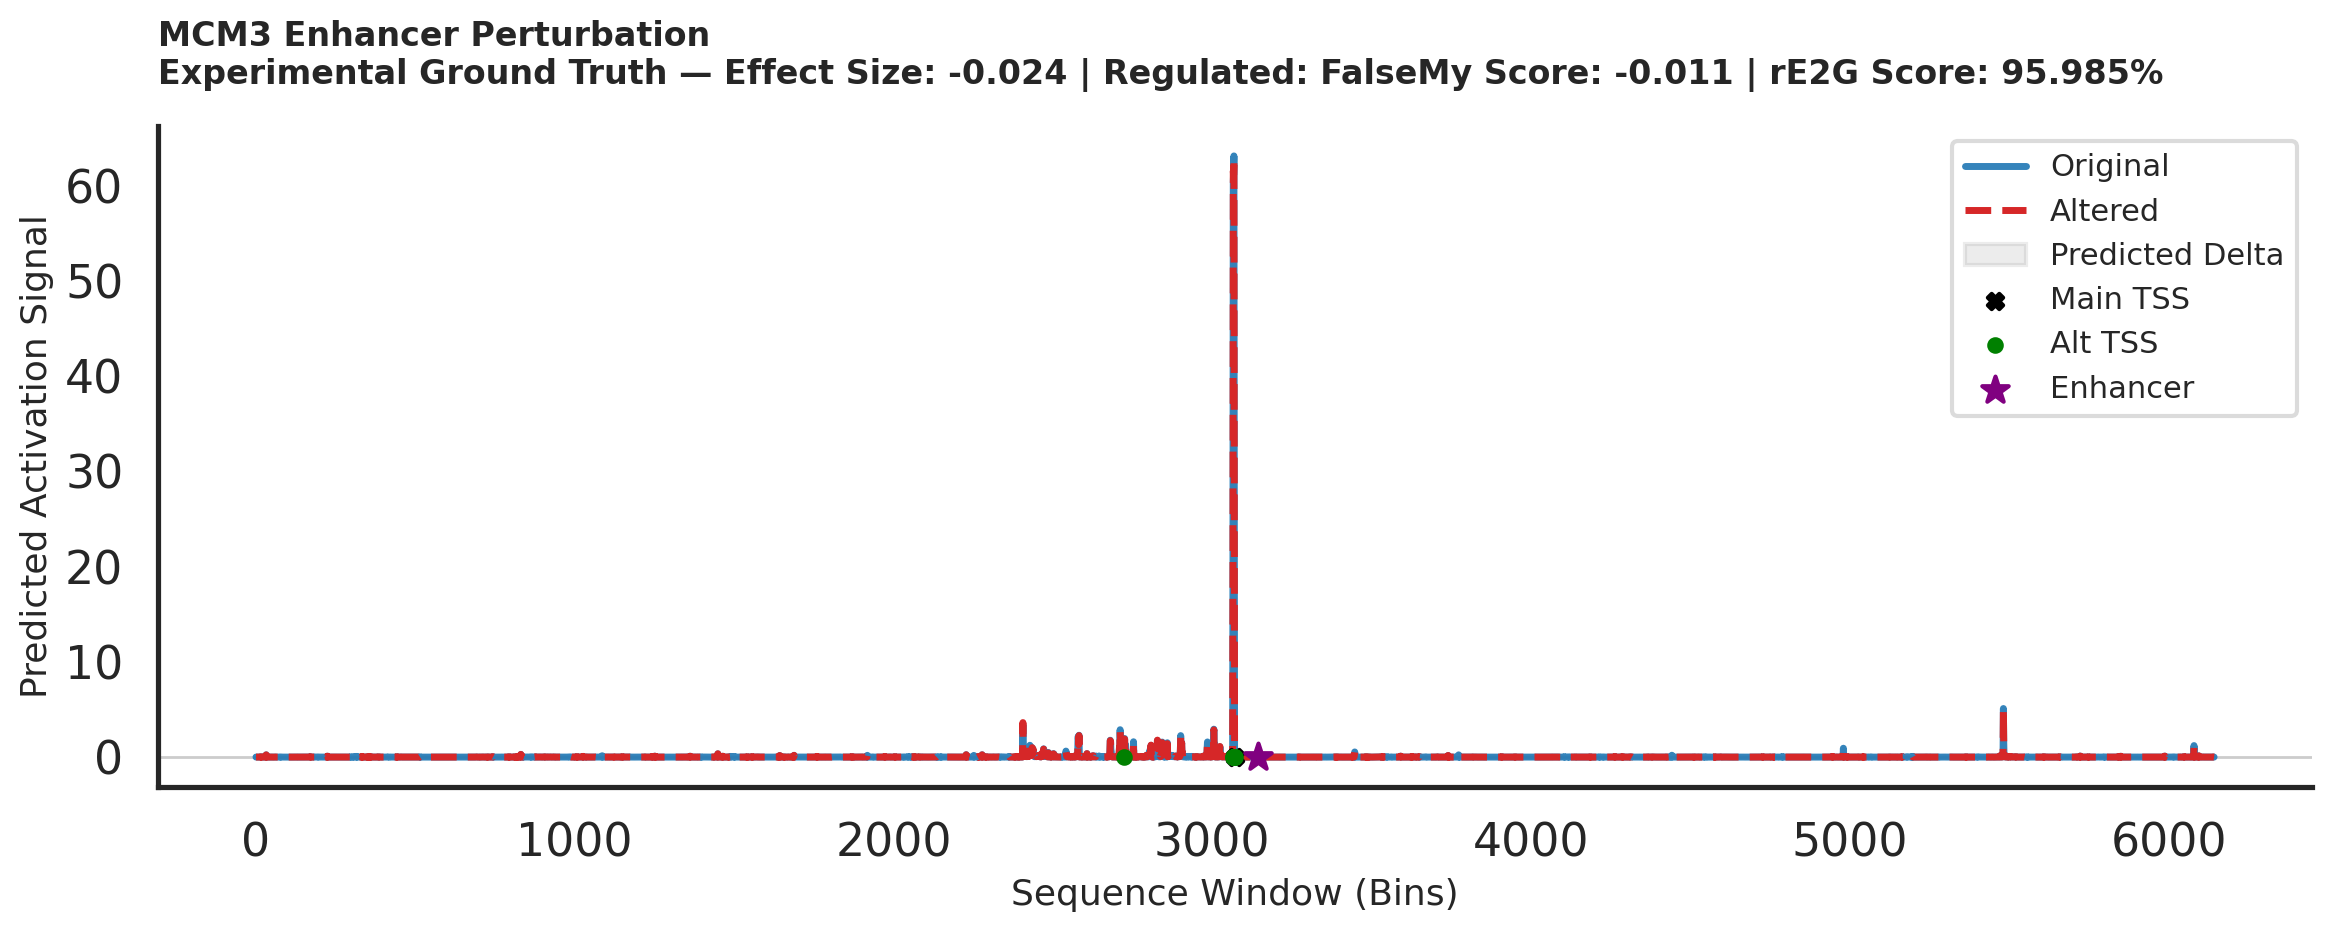

In [120]:
plot_perturbation(8061, outputs, flip=False)

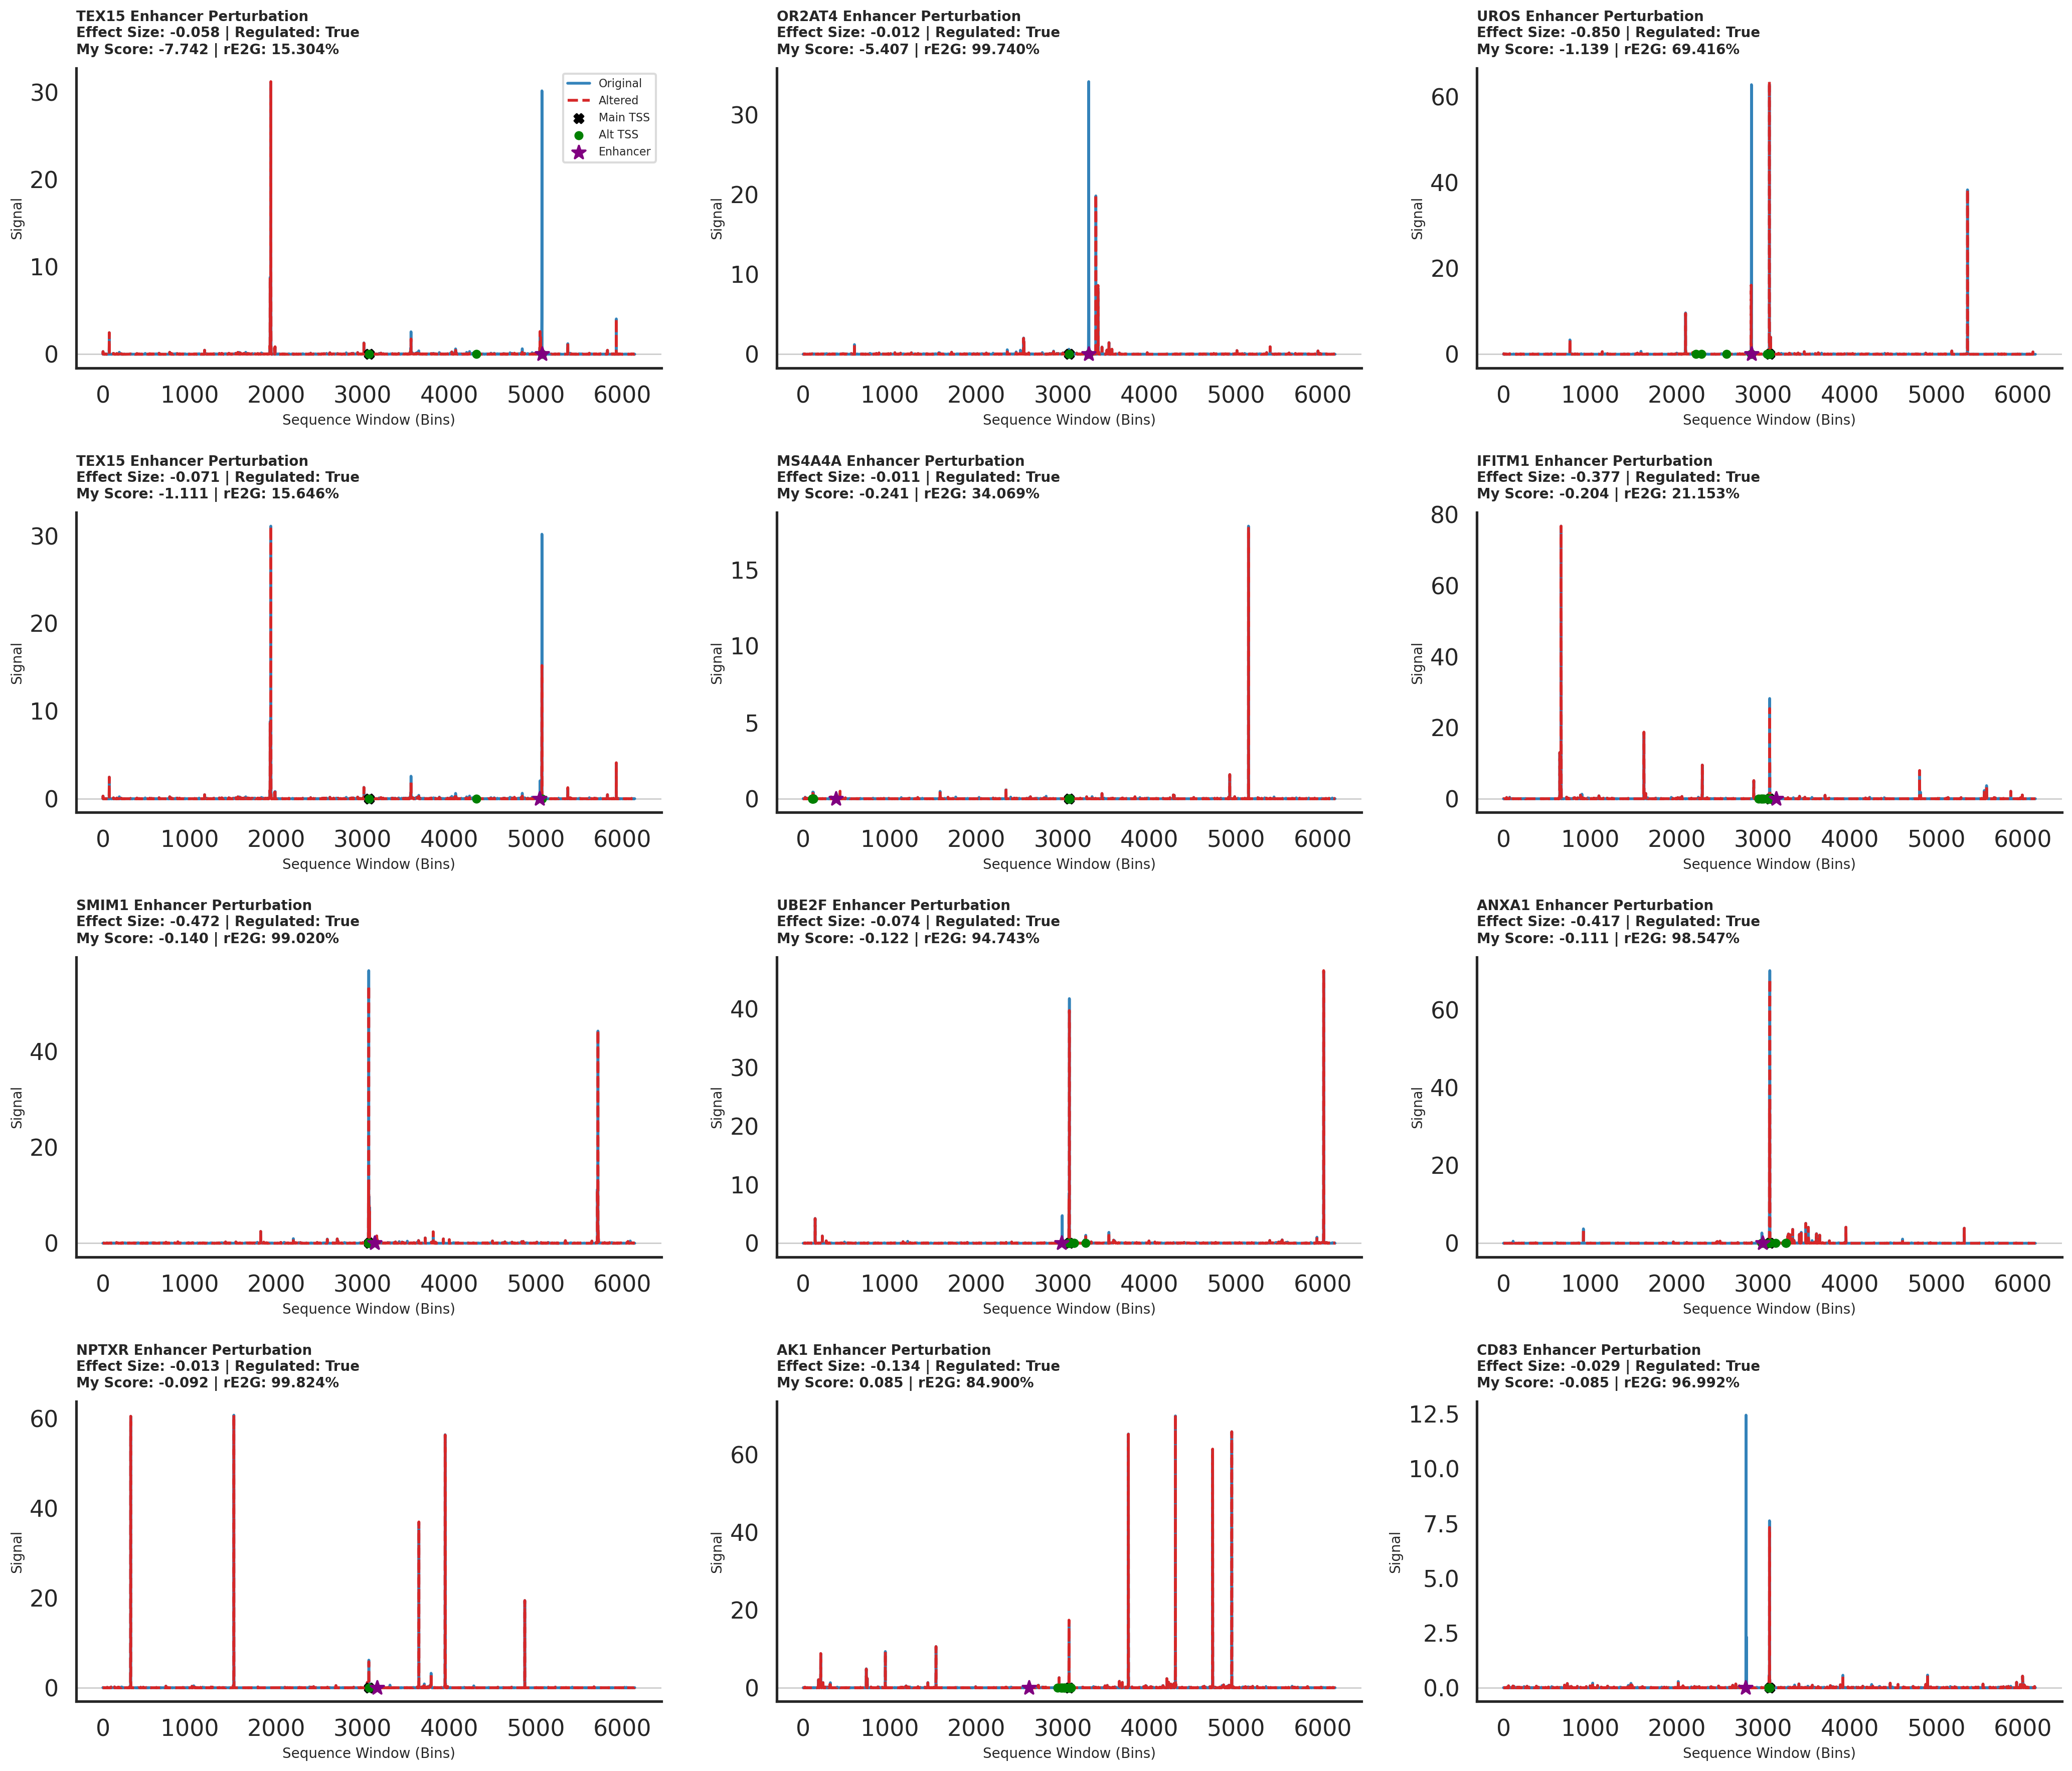

In [121]:
#let's plot multiple
indices = []
for idx in my_best_true_positives.head(12).index:
    indices.append(idx)
plot_perturbation_grid(indices, outputs, flip=False, cols=3)

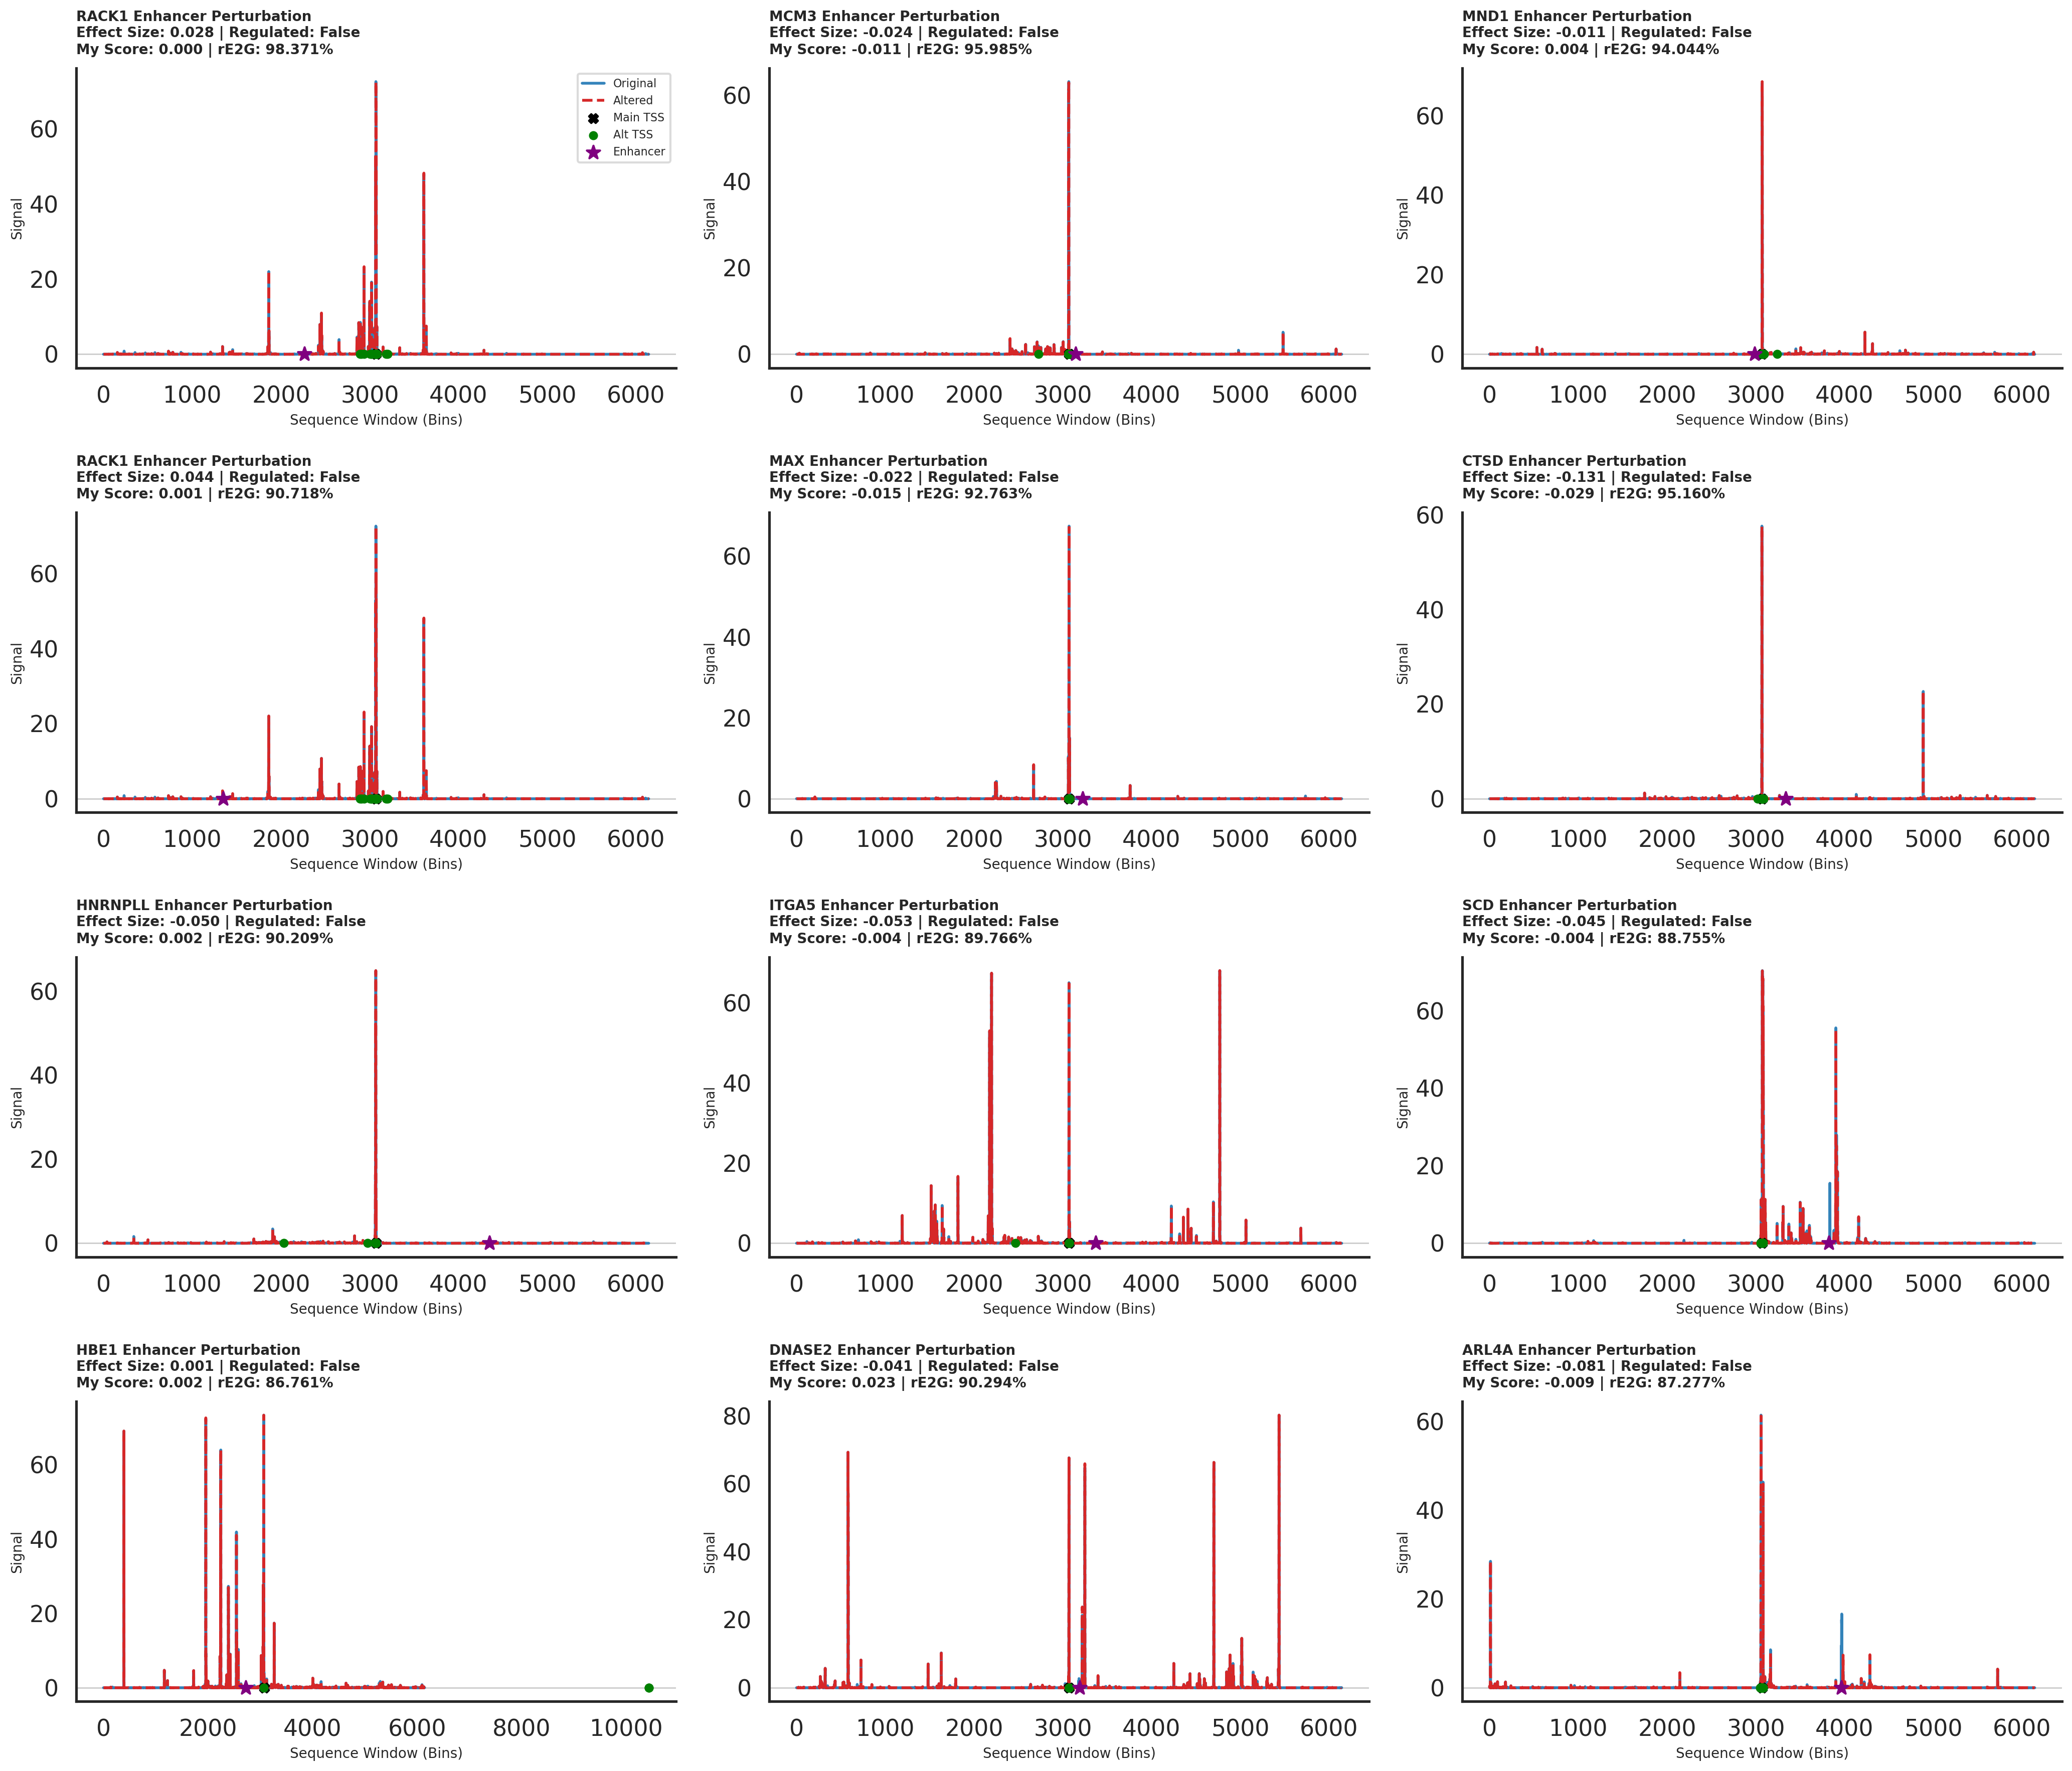

In [122]:
indices = []
for idx in my_best_true_negatives.head(12).index:
    indices.append(idx)
plot_perturbation_grid(indices, outputs, flip=False, cols=3)

In [124]:
#let's now look for true values and find the largest predictions that the E2G finds as < threshold
threshold = 0.3
my_true_positives = my_best_true_positives[my_best_true_positives['e2g_score'] < threshold]
my_true_positives

,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
8438,7.741511,-7.741511,0.153041,True,-0.057820,TEX15,chr8:30912766-30913266_TEX15,22410.5,1.000000,0.846959,1.000000,0.833418,0.166582,7.588470
8437,1.111222,-1.111222,0.156457,True,-0.071070,TEX15,chr8:30911759-30912634_TEX15,21591.0,0.999439,0.842982,0.999241,0.835949,0.163291,0.954765
1090,0.204023,-0.204023,0.211530,True,-0.377222,IFITM1,chr11:316244-316608_IFITM1,2565.0,0.791723,0.580193,0.998481,0.858481,0.140000,-0.007507
2344,0.047939,0.047939,0.070191,True,-0.018598,KLRF1,chr12:9739667-9741051_KLRF1,87122.5,0.568844,0.498653,0.992152,0.748861,0.243291,-0.022251
1216,0.025249,0.025249,0.292464,True,-0.168728,IFITM2,chr11:353334-354301_IFITM2,45726.5,0.530786,0.238322,0.980000,0.876456,0.103544,-0.267215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2437,0.000028,-0.000028,0.154359,True,-0.346497,HNRNPA1,chr12:54303561-54304061_HNRNPA1,23617.5,0.488079,0.333720,0.094684,0.834684,-0.740000,-0.154331
7335,0.000019,-0.000019,0.275565,True,-0.325936,NMU,chr4:55733769-55734436_NMU,97713.0,0.488064,0.212499,0.068101,0.873924,-0.805823,-0.275546
3430,0.000014,-0.000014,0.073537,True,-0.134740,SLC25A39,chr17:44281453-44282034_SLC25A39,43108.0,0.488056,0.414518,0.054430,0.753924,-0.699494,-0.073523
7743,0.000005,0.000005,0.114331,True,-0.122581,TRIM27,chr6:28980674-28981495_TRIM27,57823.5,0.488040,0.373709,0.016962,0.806582,-0.789620,-0.114326


In [125]:
#and negatives too
threshold = 0.7
my_true_negatives = my_best_true_negatives[my_best_true_negatives['e2g_score'] > threshold]
my_true_negatives

,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
7629,0.000012,0.000012,0.983711,False,0.028193,RACK1,chr5:181217521-181218720_RACK1,26085.0,0.488053,-0.495659,0.049114,0.991139,-0.942025,-0.983699
8061,0.010716,-0.010716,0.959853,False,-0.024337,MCM3,chr6:52286764-52287606_MCM3,2303.0,0.506191,-0.453662,0.957975,0.982278,-0.024304,-0.949138
7378,0.003803,0.003803,0.940440,False,-0.011368,MND1,chr4:153341638-153342138_MND1,2757.0,0.494476,-0.445964,0.904810,0.974684,-0.069873,-0.936637
7628,0.001033,0.001033,0.907183,False,0.043527,RACK1,chr5:181188256-181189202_RACK1,55040.0,0.489781,-0.417402,0.745316,0.965823,-0.220506,-0.906150
2981,0.014697,-0.014697,0.927626,False,-0.021777,MAX,chr14:65107151-65107651_MAX,4873.0,0.512937,-0.414689,0.966582,0.971646,-0.005063,-0.912929
1236,0.029230,-0.029230,0.951601,False,-0.130902,CTSD,chr11:1772159-1772971_CTSD,8583.0,0.537502,-0.414099,0.984304,0.978734,0.005570,-0.922371
5976,0.001918,0.001918,0.902093,False,-0.049528,HNRNPLL,chr2:38643689-38644189_HNRNPLL,40918.5,0.491281,-0.410812,0.827342,0.964557,-0.137215,-0.900175
2764,0.004127,-0.004127,0.897664,False,-0.053071,ITGA5,chr12:54428661-54429181_ITGA5,9588.5,0.495024,-0.402640,0.909873,0.963291,-0.053418,-0.893537
920,0.003508,-0.003508,0.887548,False,-0.045393,SCD,chr10:100370530-100371657_SCD,24074.0,0.493976,-0.393572,0.897975,0.961519,-0.063544,-0.884040
1498,0.002051,0.002051,0.867611,False,0.000887,HBE1,chr11:5258555-5259055_HBE1,11369.0,0.491507,-0.376104,0.838228,0.957722,-0.119494,-0.865560


In [128]:
df

,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
0,0.000434,-0.000434,0.119478,True,-0.293432,CEP104,chr1:3774714-3775214_CEP104,81923.0,0.488768,0.369290,0.584557,0.810886,-0.226329,-0.119044
1,0.002569,-0.002569,0.418431,True,-0.331178,LRRC47,chr1:3774714-3775214_LRRC47,21194.0,0.492385,0.073954,0.865570,0.900000,-0.034430,-0.415862
2,0.019438,-0.019438,0.231678,False,-0.001471,LRRC47,chr1:3803570-3805848_LRRC47,7776.0,0.520963,0.289284,0.974177,0.865063,0.109114,-0.212241
3,0.140421,-0.140421,0.990204,True,-0.472019,SMIM1,chr1:3774714-3775214_SMIM1,2524.0,0.711799,-0.278405,0.997975,0.994430,0.003544,-0.849783
4,0.004776,0.004776,0.076260,False,0.025677,SMIM1,chr1:3803570-3805848_SMIM1,31494.0,0.496124,0.419864,0.919241,0.758481,0.160759,-0.071484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10267,0.000266,-0.000266,0.091143,False,0.056091,MPP1,chrX:154757158-154758121_MPP1,63367.0,0.488482,0.397339,0.475190,0.781266,-0.306076,-0.090877
10268,0.001974,0.001974,0.034595,False,-0.041557,NAA10,chrX:154001551-154002590_NAA10,66999.5,0.491376,0.456781,0.831646,0.640506,0.191139,-0.032621
10271,0.014453,-0.014453,0.101900,False,0.014038,FAM3A,chrX:154527069-154527569_FAM3A,11189.5,0.512524,0.410624,0.966329,0.793671,0.172658,-0.087447
10274,0.000091,0.000091,0.020941,False,-0.017888,LAGE3,chrX:154527069-154527569_LAGE3,48174.5,0.488185,0.467244,0.253418,0.587089,-0.333671,-0.020850


In [143]:
my_true_negatives = df[(df['regulated'] == 0) & (df['e2g_score'] > threshold) & (df['my_percentile'] < 0.7)].copy()
my_true_negatives

,my_score,my_score_raw,e2g_score,regulated,effect_size,gene,enhancer,distance,my_calibrated_prob,prob_delta,my_percentile,e2g_percentile,my_advantage_delta,score_delta
1565,0.000050,0.000050,0.725502,False,-0.020424,HBG2,chr11:5129329-5129829_HBG2,125303.5,0.488116,-0.237386,0.154177,0.937215,-0.783038,-0.725453
1684,0.000354,-0.000354,0.786931,False,0.007662,IPO7,chr11:9364144-9365232_IPO7,20206.5,0.488632,-0.298299,0.535949,0.945823,-0.409873,-0.786576
3115,0.000051,0.000051,0.793461,False,-0.020492,HBQ1,chr16:142952-143452_HBQ1,36923.5,0.488118,-0.305342,0.159494,0.946835,-0.787342,-0.793410
7627,0.000064,-0.000064,0.760983,False,0.078774,RACK1,chr5:181184049-181184549_RACK1,59614.0,0.488141,-0.272842,0.193418,0.942278,-0.748861,-0.760919
7629,0.000012,0.000012,0.983711,False,0.028193,RACK1,chr5:181217521-181218720_RACK1,26085.0,0.488053,-0.495659,0.049114,0.991139,-0.942025,-0.983699


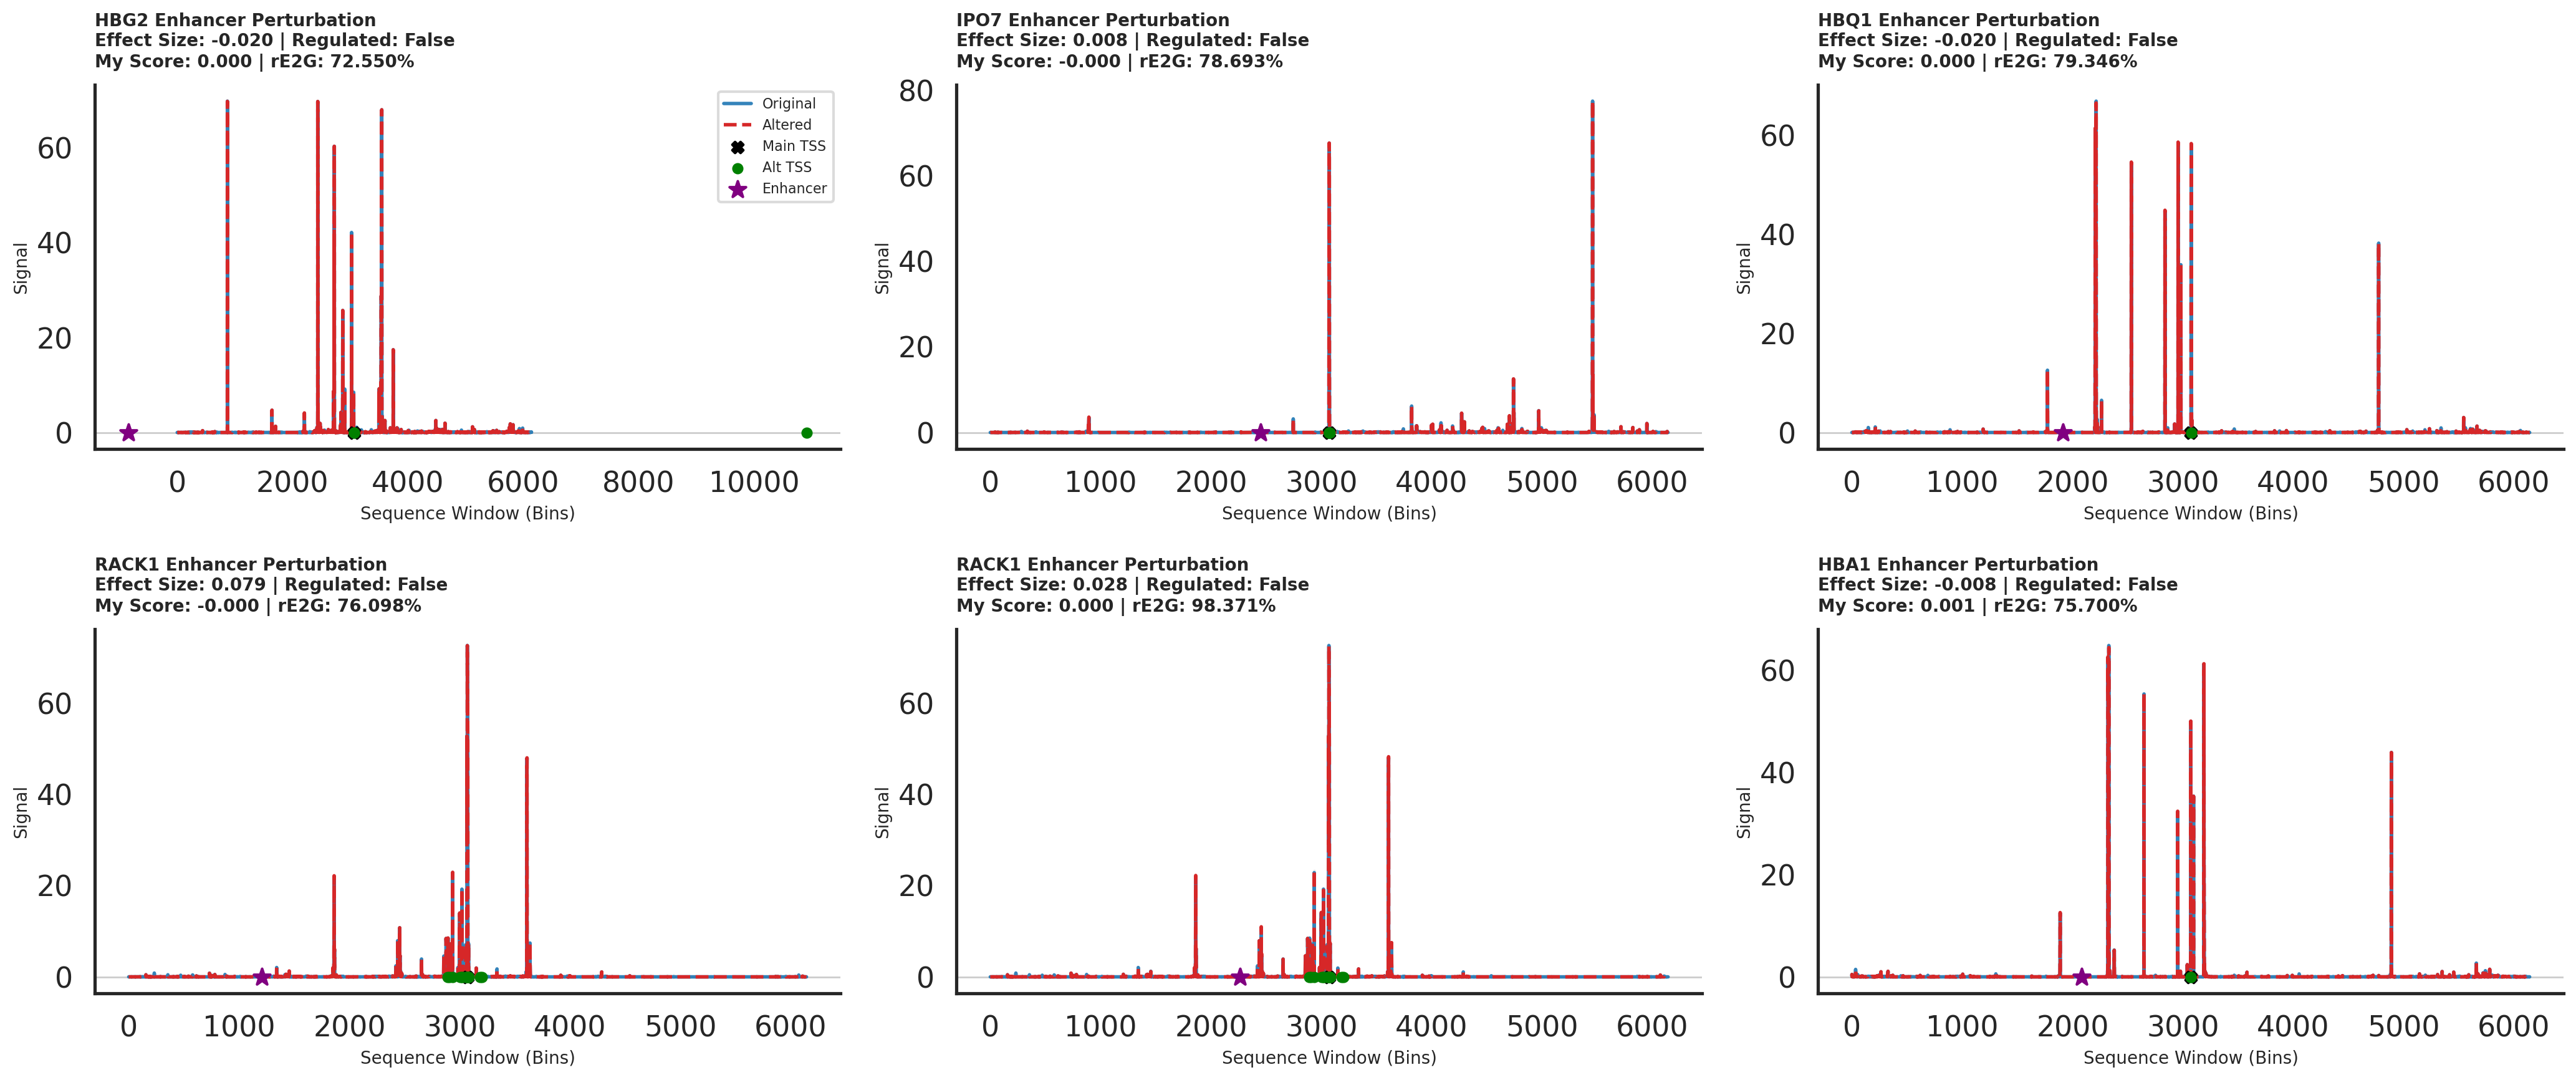

In [147]:
indices = my_true_negatives.head(12).index.tolist()
indices.append(3127)
plot_perturbation_grid(indices, outputs, flip=False, cols=3)

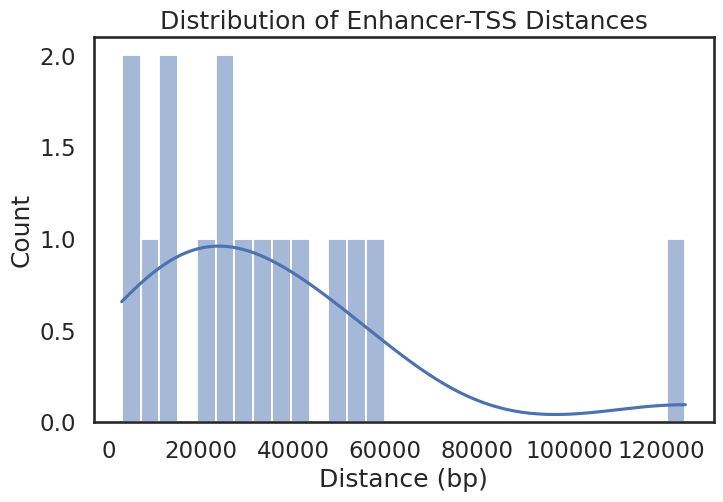

In [142]:
#histogram of distance column
plt.figure(figsize=(8,5))
sns.histplot(my_true_negatives['distance'], bins=30, kde=True)
plt.title("Distribution of Enhancer-TSS Distances")
plt.xlabel("Distance (bp)")
plt.ylabel("Count")
plt.show()